# CAPSTONE PROJECT - Certified Data Analyst

## CONNECTION AND DATA PREPARATION

### CONNECT COLAB TO GOOGLE DRIVE

In [1]:
#Membuat connection ke database ke Gdrive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### IMPORT PACKAGES

In [2]:
#Import beberapa packages yang akan digunaan pada sesi ini
import os
import sqlite3
import pandas as pd
import csv
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

### CONNECT SQLITE TO PYTHON

In [3]:
#Membuat jalur yang akan digunakan untuk mengambil data
path = "/content/gdrive/MyDrive/NARASIO/Capstone/2. Brazilian E-Commerce/"
os.listdir(path)
conn = sqlite3.connect(path + 'Olist E-commerce.db')
cur = conn.cursor()

###DATA PREPARATION USING SQL

In [4]:
#Mengecek Table yang tersedia di database
cur.execute("""
              SELECT 
                  name 
              FROM sqlite_master 
              WHERE type='table'
            """)

print(cur.fetchall())

[('Orders',), ('Products',), ('Customers',), ('Sellers',), ('Geolocation',)]


In [5]:
#Menampilkan table Orders
pd.read_sql_query('''
                    SELECT
                    *
                    FROM Orders
                    ''',conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-02 21:09:20,2018-03-12 23:36:26,2018-03-21 00:00:00,1.0,72d3bf1d3a790f8874096fcf860e3eff,...,1.0,credit_card,1.0,54.36,8f39f09c22b1ceb6e3eb178d8e50bb8a,4.0,None,Gostei do produto,2018-03-13 00:00:00,2018-03-14 10:36:16
1,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,delivered,2017-12-15 00:06:10,2017-12-15 00:14:55,2017-12-19 01:58:00,2018-01-03 15:09:32,2018-01-16 00:00:00,1.0,60184212dae4e6b0da32bf54271a8c4a,...,1.0,credit_card,10.0,386.33,ffa0d9ba2678dba5fa370295245f473d,4.0,None,"Inicialmente, pedi o cancelamento do pedido de...",2018-01-04 00:00:00,2018-01-04 18:29:06
2,b52cc4919de82b4d696a4380d10804a3,be8c14c16a4d47194ccdfe10f1fc5b1a,delivered,2018-06-13 13:47:39,2018-06-15 02:37:29,2018-06-15 14:22:00,2018-06-18 22:32:44,2018-06-26 00:00:00,1.0,7564c1759c04fc0a38f2aa84f7a370ee,...,1.0,boleto,1.0,55.02,b1dafcdfcddb6feb75222b9c1f2baad3,5.0,None,None,2018-06-19 00:00:00,2018-06-20 11:07:14
3,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12 00:00:00,1.0,a5a0e71a81ae65aa335e71c06261e260,...,1.0,boleto,1.0,267.80,fd793fea4f4a2ddcc956561144b6c04e,1.0,None,None,2017-05-11 00:00:00,2017-05-12 11:25:49
4,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12 00:00:00,2.0,a5a0e71a81ae65aa335e71c06261e260,...,1.0,boleto,1.0,267.80,fd793fea4f4a2ddcc956561144b6c04e,1.0,None,None,2017-05-11 00:00:00,2017-05-12 11:25:49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10996,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-03 20:26:19,2017-10-06 16:58:25,2017-10-24 00:00:00,1.0,9e10ae46a3021a02f1692448ef9fa1db,...,1.0,credit_card,4.0,49.75,47697b20bcd3995f870e284fad248ac8,4.0,None,None,2017-10-07 00:00:00,2017-10-09 22:28:51
10997,dfc6eb45a2753ed9e6c6ef4987b44503,a046c690e0564ffde0ce611b5eee2c30,delivered,2018-05-25 17:05:17,2018-05-25 17:15:21,2018-05-29 13:31:00,2018-06-04 23:54:32,2018-06-26 00:00:00,1.0,829002c1d5f40820ebbc6ecd4bcdf3ab,...,1.0,credit_card,4.0,173.63,22503643d52782c09b5151c634233e34,5.0,None,None,2018-06-05 00:00:00,2018-06-08 10:37:13
10998,6ec4642f9993cc34f826cfb9068e5a2f,f00bb12620b7b232233cace1b229db18,delivered,2017-11-21 20:18:03,2017-11-21 20:28:52,2017-11-27 17:18:52,2017-12-02 16:48:46,2017-12-08 00:00:00,1.0,9503faef00966962beacdb4916272305,...,1.0,credit_card,7.0,319.25,d76f6d4e5f6adbc77ec42f047ad47dc7,4.0,None,Comprei também uma resistência avulsa para o c...,2017-12-03 00:00:00,2017-12-04 00:48:17
10999,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,2.0,49d2e2460386273b195e7e59b43587c3,...,1.0,credit_card,2.0,42.42,ebd75732b5804e934123d11ec1f11db0,5.0,None,None,2017-10-21 00:00:00,2017-10-23 14:48:40


Terdapat 11001 Baris dan 24 Kolom pada Table Orders.

In [6]:
#Menampilkan table Products
pd.read_sql_query('''
                    SELECT
                    *
                    FROM Products
                    ''',conn)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,72d3bf1d3a790f8874096fcf860e3eff,toys,57.0,341.0,2.0,583.0,20.0,21.0,20.0
1,60184212dae4e6b0da32bf54271a8c4a,watches_gifts,59.0,476.0,2.0,394.0,17.0,11.0,14.0
2,7564c1759c04fc0a38f2aa84f7a370ee,construction_tools_construction,59.0,2432.0,3.0,1200.0,16.0,11.0,11.0
3,a5a0e71a81ae65aa335e71c06261e260,housewares,57.0,698.0,3.0,705.0,34.0,22.0,28.0
4,69d980b4120a76616d7b237d731d6156,watches_gifts,60.0,1362.0,3.0,600.0,16.0,11.0,12.0
...,...,...,...,...,...,...,...,...,...
7018,526f833e1eb0a32ad9351145a761b9ab,watches_gifts,60.0,491.0,2.0,250.0,16.0,2.0,11.0
7019,9e10ae46a3021a02f1692448ef9fa1db,health_beauty,45.0,2231.0,3.0,175.0,21.0,3.0,15.0
7020,829002c1d5f40820ebbc6ecd4bcdf3ab,home_construction,59.0,664.0,1.0,5150.0,30.0,35.0,30.0
7021,9503faef00966962beacdb4916272305,construction_tools_construction,55.0,612.0,1.0,1900.0,35.0,30.0,25.0


Terdapat 17023 Baris dan 9 Kolom pada Table Products.

In [7]:
#Menampilkan table Customers
pd.read_sql_query('''
                    SELECT
                    *
                    FROM Customers
                    ''',conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,3df704f53d3f1d4818840b34ec672a9f,04cf8185c71090d28baa4407b2e6d600,5271,sao paulo,SP
1,f5afca14dfa9dc64251cf2b45c54c363,38cad70d154a4dcc42b598d5c01f7ef1,25211,duque de caxias,RJ
2,be8c14c16a4d47194ccdfe10f1fc5b1a,c86a25b8f5f6c203bb3471553bdc3200,13157,cosmopolis,SP
3,388025bec8128ff20ec1a316ed4dcf02,f9effeed3df9ae063a58c0759b96f8b2,85804,cascavel,PR
4,05e996469a2bf9559c7122b87e156724,5229b8e4d7d2b9b676c2083c17b1ecd0,93180,portao,RS
...,...,...,...,...,...
10717,ce5efd1b1d8a2fa290a871edd5c26cd6,39fff7cb5873a7116b02234bd1e6c6dc,11320,sao vicente,SP
10718,a046c690e0564ffde0ce611b5eee2c30,4a7ce65ce092885c0af12dc0001457cf,35600,bom despacho,MG
10719,f00bb12620b7b232233cace1b229db18,cf82c9581d66ad1de6b0fe919188bdd6,36026,juiz de fora,MG
10720,da2124f134f5dfbce9d06f29bdb6c308,c716cf2b5b86fb24257cffe9e7969df8,78048,cuiaba,MT


Terdapat 10722 Baris dan 5 Kolom pada Table Customers.

In [8]:
#Menampilkan table Sellers
pd.read_sql_query('''
                    SELECT
                    *
                    FROM Sellers
                    ''',conn)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,8602a61d680a10a82cceeeda0d99ea3d,1001,sao paulo,SP
1,dd55f1bb788714a40e7954c3be6df745,1021,sao paulo,SP
2,e0487761face83d64fcada2408959a36,1021,sao paulo,SP
3,09bad886111255c5b5030314fc7f1a4a,1022,sao paulo,SP
4,f049a72cf58fd31b11f8919cade515e7,1023,sao paulo,SP
...,...,...,...,...
3090,4bde6149c15cf7e177b36fa060dd6de8,99500,carazinho,RS
3091,447d377bdb757058acb569025ee18a93,99500,carazinho,RS
3092,4fae87d32467e18eb46e4a76a0a0b9ce,99670,ronda alta,RS
3093,968ee78631915a63fef426d6733d7422,99700,erechim,RS


Terdapat 3095 Baris dan 4 Kolom pada Table Sellers.

In [9]:
#Menampilkan table Geolocation
pd.read_sql_query('''
                    SELECT
                    *
                    FROM Geolocation
                    ''',conn)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.549292,-46.633559
1,1012,-23.540451,-46.643570
2,1014,-23.542521,-46.635335
3,1020,-23.544207,-46.636281
4,1021,-23.546718,-46.639357
...,...,...,...
7120,99830,-28.069978,-52.008408
7121,99870,-27.883745,-52.233311
7122,99925,-28.386970,-51.845810
7123,99950,-28.068869,-52.012942


Terdapat 7125 Baris dan 3 Kolom pada Table Geolocation.

In [10]:
#Menampilkan nama kolom pada Table Orders
cur.execute("PRAGMA table_info(Orders)")
Orders_column_names = [result[1] for result in cur.fetchall()]
print(Orders_column_names)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [11]:
#Menampilkan nama kolom pada Table Products
cur.execute("PRAGMA table_info(Products)")
Products_column_names = [result[1] for result in cur.fetchall()]
print(Products_column_names)

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [12]:
#Menampilkan nama kolom pada Table Customers
cur.execute("PRAGMA table_info(Customers)")
Customers_column_names = [result[1] for result in cur.fetchall()]
print(Customers_column_names)

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [13]:
#Menampilkan nama kolom pada Table Sellers
cur.execute("PRAGMA table_info(Sellers)")
Sellers_column_names = [result[1] for result in cur.fetchall()]
print(Sellers_column_names)

['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [14]:
#Menampilkan nama kolom pada Table Geolocation
cur.execute("PRAGMA table_info(Geolocation)")
Geolocation_column_names = [result[1] for result in cur.fetchall()]
print(Geolocation_column_names)

['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']


### COMBINE DATA

In [15]:
#Menggabungkan semua kolom dari beberapa table untuk kebutuhan analisis selanjutnya

Combine_Data = ('''
                    SELECT
                    *
                    FROM Orders
                    INNER JOIN Products ON Orders.product_id = Products.product_id
                    INNER JOIN Customers ON Orders.customer_id = Customers.customer_id
                    INNER JOIN Sellers ON Orders.seller_id = Sellers.seller_id
                    INNER JOIN Geolocation ON Sellers.seller_zip_code_prefix = Geolocation.geolocation_zip_code_prefix
                    ''')
DATA = pd.read_sql_query(Combine_Data,conn)
DATA

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_zip_code_prefix,customer_city,customer_state,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-02 21:09:20,2018-03-12 23:36:26,2018-03-21 00:00:00,1.0,72d3bf1d3a790f8874096fcf860e3eff,...,5271,sao paulo,SP,0bae85eb84b9fb3bd773911e89288d54,88301,itajai,SP,88301,-26.892531,-49.063361
1,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,delivered,2017-12-15 00:06:10,2017-12-15 00:14:55,2017-12-19 01:58:00,2018-01-03 15:09:32,2018-01-16 00:00:00,1.0,60184212dae4e6b0da32bf54271a8c4a,...,25211,duque de caxias,RJ,b33e7c55446eabf8fe1a42d037ac7d6d,14850,pradopolis,SP,14850,-23.582120,-48.036878
2,b52cc4919de82b4d696a4380d10804a3,be8c14c16a4d47194ccdfe10f1fc5b1a,delivered,2018-06-13 13:47:39,2018-06-15 02:37:29,2018-06-15 14:22:00,2018-06-18 22:32:44,2018-06-26 00:00:00,1.0,7564c1759c04fc0a38f2aa84f7a370ee,...,13157,cosmopolis,SP,6860153b69cc696d5dcfe1cdaaafcf62,13360,capivari,SP,13360,-21.066181,-50.144384
3,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12 00:00:00,1.0,a5a0e71a81ae65aa335e71c06261e260,...,85804,cascavel,PR,c8417879a15366a17c30af34c798c332,4445,sao paulo,SP,4445,-23.588617,-46.742936
4,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12 00:00:00,2.0,a5a0e71a81ae65aa335e71c06261e260,...,85804,cascavel,PR,c8417879a15366a17c30af34c798c332,4445,sao paulo,SP,4445,-23.588617,-46.742936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10915,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-03 20:26:19,2017-10-06 16:58:25,2017-10-24 00:00:00,1.0,9e10ae46a3021a02f1692448ef9fa1db,...,11320,sao vicente,SP,8b28d096634035667e8263d57ba3368c,12243,sao jose dos campos,SP,12243,-22.402121,-47.568460
10916,dfc6eb45a2753ed9e6c6ef4987b44503,a046c690e0564ffde0ce611b5eee2c30,delivered,2018-05-25 17:05:17,2018-05-25 17:15:21,2018-05-29 13:31:00,2018-06-04 23:54:32,2018-06-26 00:00:00,1.0,829002c1d5f40820ebbc6ecd4bcdf3ab,...,35600,bom despacho,MG,1025f0e2d44d7041d6cf58b6550e0bfa,3204,sao paulo,SP,3204,-23.511680,-46.486412
10917,6ec4642f9993cc34f826cfb9068e5a2f,f00bb12620b7b232233cace1b229db18,delivered,2017-11-21 20:18:03,2017-11-21 20:28:52,2017-11-27 17:18:52,2017-12-02 16:48:46,2017-12-08 00:00:00,1.0,9503faef00966962beacdb4916272305,...,36026,juiz de fora,MG,b2ba3715d723d245138f291a6fe42594,3470,sao paulo,SP,3470,-23.597353,-46.605000
10918,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,2.0,49d2e2460386273b195e7e59b43587c3,...,78048,cuiaba,MT,1caf283236cd69af44cbc09a0a1e7d32,26020,nova iguacu,RJ,26020,-22.377953,-41.778890


### EKSPOR DATA TO CSV

In [16]:
#Melakukan ekspor data dari SQLlite menjadi CSV untuk dilakukan proses selanjutnya

DATA.to_csv('OLIST_DATA.csv', index=False)

### PROBLEM STATEMENT




1.   Bagaimana Pola transaksi pada data tersebut?
2.   Bagaimana Pola pembayaran pada data tersebut?
3.   Apakah terdapat pertumbuhan new customer pada data tersebut?
4.   Bagaimana kepuasaan pelanggan pada data tersebut?




### DATA PREPARATION USING PYTHON

In [17]:
df = pd.read_csv('OLIST_DATA.csv')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10920 entries, 0 to 10919
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       10920 non-null  object 
 1   customer_id                    10920 non-null  object 
 2   order_status                   10920 non-null  object 
 3   order_purchase_timestamp       10920 non-null  object 
 4   order_approved_at              10919 non-null  object 
 5   order_delivered_carrier_date   10801 non-null  object 
 6   order_delivered_customer_date  10685 non-null  object 
 7   order_estimated_delivery_date  10920 non-null  object 
 8   order_item_id                  10920 non-null  float64
 9   product_id                     10920 non-null  object 
 10  seller_id                      10920 non-null  object 
 11  shipping_limit_date            10920 non-null  object 
 12  price                          10920 non-null 

In [19]:
#Mengubah format Zip_code dari integer menjadi object

df[['customer_zip_code_prefix', 'seller_zip_code_prefix', 'geolocation_zip_code_prefix']] = df[['customer_zip_code_prefix', 'seller_zip_code_prefix', 'geolocation_zip_code_prefix']].astype('object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10920 entries, 0 to 10919
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       10920 non-null  object 
 1   customer_id                    10920 non-null  object 
 2   order_status                   10920 non-null  object 
 3   order_purchase_timestamp       10920 non-null  object 
 4   order_approved_at              10919 non-null  object 
 5   order_delivered_carrier_date   10801 non-null  object 
 6   order_delivered_customer_date  10685 non-null  object 
 7   order_estimated_delivery_date  10920 non-null  object 
 8   order_item_id                  10920 non-null  float64
 9   product_id                     10920 non-null  object 
 10  seller_id                      10920 non-null  object 
 11  shipping_limit_date            10920 non-null  object 
 12  price                          10920 non-null 

In [21]:
df.describe()

,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat,geolocation_lng
count,10920.000000,10920.000000,10920.000000,10918.000000,10918.000000,10918.000000,10920.000000,10752.000000,10752.000000,10752.000000,10917.000000,10917.000000,10917.000000,10917.000000,10920.000000,10920.000000
mean,1.193315,119.325606,20.037269,1.098553,2.963821,170.396270,4.029029,48.883371,779.228888,2.214751,2101.252267,30.239168,16.671888,23.017862,-23.115565,-47.257448
std,0.703433,175.944111,15.296289,0.760620,2.776864,270.305933,1.388589,9.973370,644.914818,1.734148,3771.026518,15.990947,13.551088,11.564085,2.623258,2.483562
min,1.000000,1.200000,0.000000,1.000000,1.000000,0.030000,1.000000,9.000000,4.000000,1.000000,50.000000,7.000000,2.000000,8.000000,-32.229980,-67.816164
25%,1.000000,39.900000,13.080000,1.000000,1.000000,60.230000,4.000000,42.000000,344.000000,1.000000,300.000000,18.000000,8.000000,15.000000,-23.752681,-48.872939
50%,1.000000,74.900000,16.280000,1.000000,2.000000,108.190000,5.000000,52.000000,597.000000,1.000000,700.000000,25.000000,13.000000,20.000000,-23.511680,-46.856015
75%,1.000000,129.990000,21.357500,1.000000,4.000000,188.927500,5.000000,57.000000,977.000000,3.000000,1825.000000,38.000000,20.000000,30.000000,-22.370900,-46.486412
max,21.000000,4399.870000,255.920000,29.000000,24.000000,13664.080000,5.000000,76.000000,3949.000000,17.000000,30000.000000,105.000000,105.000000,118.000000,-3.656415,-35.237187


In [22]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   1
order_delivered_carrier_date      119
order_delivered_customer_date     235
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  2
payment_type                        2
payment_installments                2
payment_value                       2
review_id                           0
review_score                        0
review_comment_title             9632
review_comment_message           6244
review_creation_date                1
review_answer_timestamp             1
product_id.1                        0
product_category_name             171
product_name

In [23]:
#Handling missing values
index = (df[df['order_delivered_customer_date'].isnull() == True].index.values)

df["order_approved_at"].fillna(df["order_purchase_timestamp"], inplace=True)
df["order_delivered_customer_date"].fillna(df["order_estimated_delivery_date"], inplace=True)
df['product_weight_g'].fillna(df['product_weight_g'].median(),inplace=True)
df['product_length_cm'].fillna(df['product_length_cm'].median(),inplace=True)
df['product_height_cm'].fillna(df['product_height_cm'].median(),inplace=True)
df['product_width_cm'].fillna(df['product_width_cm'].median(),inplace=True)
df['review_comment_message'].fillna('No_Review_message',inplace=True)
df['review_comment_title'].fillna('No_Review_title',inplace=True)
df["review_creation_date"].fillna(df["order_delivered_customer_date"], inplace=True)
df["review_answer_timestamp"].fillna(df["review_creation_date"], inplace=True)



In [24]:
#Menghapus beberapa kolom yang tidak dipakai
df.drop(labels='product_photos_qty',axis=1,inplace=True)
df.drop(labels='product_description_lenght',axis=1,inplace=True)
df.drop(labels='product_name_lenght',axis=1,inplace=True)
df.drop(labels='order_delivered_carrier_date',axis=1,inplace=True)

In [25]:
df2 = df.dropna(axis=0, how="any")

In [26]:
df2.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_customer_date    0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
review_id                        0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
product_id.1                     0
product_category_name            0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm    

In [27]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10747 entries, 0 to 10919
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       10747 non-null  object 
 1   customer_id                    10747 non-null  object 
 2   order_status                   10747 non-null  object 
 3   order_purchase_timestamp       10747 non-null  object 
 4   order_approved_at              10747 non-null  object 
 5   order_delivered_customer_date  10747 non-null  object 
 6   order_estimated_delivery_date  10747 non-null  object 
 7   order_item_id                  10747 non-null  float64
 8   product_id                     10747 non-null  object 
 9   seller_id                      10747 non-null  object 
 10  shipping_limit_date            10747 non-null  object 
 11  price                          10747 non-null  float64
 12  freight_value                  10747 non-null 

In [28]:
df2.describe()

,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat,geolocation_lng
count,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000,10747.000000
mean,1.193542,119.476204,20.060657,1.098818,2.969666,170.631387,4.031451,2098.768959,30.284079,16.697311,23.058528,-23.118596,-47.267778
std,0.706213,176.368734,15.280849,0.765379,2.783123,271.116447,1.386884,3755.251330,16.003041,13.561169,11.558171,2.630411,2.484340
min,1.000000,1.200000,0.000000,1.000000,1.000000,0.030000,1.000000,50.000000,7.000000,2.000000,8.000000,-32.229980,-67.816164
25%,1.000000,39.900000,13.090000,1.000000,1.000000,60.335000,4.000000,300.000000,18.000000,8.000000,15.000000,-23.825208,-48.872939
50%,1.000000,74.900000,16.310000,1.000000,2.000000,108.120000,5.000000,700.000000,25.000000,13.000000,20.000000,-23.511680,-46.856015
75%,1.000000,129.990000,21.420000,1.000000,4.000000,189.110000,5.000000,1825.000000,38.000000,20.000000,30.000000,-22.370900,-46.486412
max,21.000000,4399.870000,255.920000,29.000000,24.000000,13664.080000,5.000000,30000.000000,105.000000,105.000000,118.000000,-3.656415,-35.237187


In [29]:
columns_to_check = ['order_id', 'customer_id', 'customer_unique_id', 'order_purchase_timestamp', 'order_delivered_customer_date']
duplicate_cek = df2[df2.duplicated(subset=columns_to_check, keep=False)]
duplicate_cek

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,...,customer_zip_code_prefix,customer_city,customer_state,seller_id.1,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
3,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-05-10 09:17:55,2017-05-12 00:00:00,1.0,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,...,85804,cascavel,PR,c8417879a15366a17c30af34c798c332,4445,sao paulo,SP,4445,-23.588617,-46.742936
4,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-05-10 09:17:55,2017-05-12 00:00:00,2.0,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,...,85804,cascavel,PR,c8417879a15366a17c30af34c798c332,4445,sao paulo,SP,4445,-23.588617,-46.742936
46,4df92d82d79c3b52c7138679fa9b07fc,ba0660bf3fffe505ee892e153a2fbd49,delivered,2018-07-24 11:32:11,2018-07-29 23:30:52,2018-07-27 18:55:57,2018-08-06 00:00:00,1.0,de533fe5b9448ea9792195806938dbf5,1025f0e2d44d7041d6cf58b6550e0bfa,...,4753,sao paulo,SP,1025f0e2d44d7041d6cf58b6550e0bfa,3204,sao paulo,SP,3204,-23.511680,-46.486412
47,4df92d82d79c3b52c7138679fa9b07fc,ba0660bf3fffe505ee892e153a2fbd49,delivered,2018-07-24 11:32:11,2018-07-29 23:30:52,2018-07-27 18:55:57,2018-08-06 00:00:00,1.0,de533fe5b9448ea9792195806938dbf5,1025f0e2d44d7041d6cf58b6550e0bfa,...,4753,sao paulo,SP,1025f0e2d44d7041d6cf58b6550e0bfa,3204,sao paulo,SP,3204,-23.511680,-46.486412
49,9472d3c8a0ad463cbfc89897334431da,7e016f9ea275279784f42e0642214284,delivered,2017-11-20 16:21:04,2017-11-21 09:50:30,2017-12-21 14:22:54,2017-12-12 00:00:00,1.0,9036be77e0a74cca6eeef0740649b97b,de23c3b98a88888289c6f5cc1209054a,...,60764,fortaleza,CE,de23c3b98a88888289c6f5cc1209054a,5530,sao paulo,SP,5530,-23.446877,-46.545384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10796,1ce0acf125f1bcd636276dd213363196,d11524bb77c28efad04e4467eac8a660,delivered,2017-07-31 18:10:29,2017-07-31 18:25:20,2017-08-09 20:38:07,2017-08-28 00:00:00,1.0,cc9e875c2df286dbed83efe01191162c,c731d18cea9bf687ffee82a241c25b11,...,30130,belo horizonte,MG,c731d18cea9bf687ffee82a241c25b11,89701,concordia,SC,89701,-30.060724,-51.216353
10807,de06e436fbb3dd6e10bafb5f24ed5530,11ff39f6282e2a89f5c079a47af66743,delivered,2017-09-07 01:15:30,2017-09-07 02:00:15,2017-09-12 21:44:35,2017-09-26 00:00:00,1.0,418d8bb517562fb8e8a2f1c5de0afa70,9646c3513289980f17226a2fc4720dbd,...,23058,rio de janeiro,RJ,9646c3513289980f17226a2fc4720dbd,12215,sao jose dos campos,SP,12215,-22.754108,-47.361129
10808,de06e436fbb3dd6e10bafb5f24ed5530,11ff39f6282e2a89f5c079a47af66743,delivered,2017-09-07 01:15:30,2017-09-07 02:00:15,2017-09-12 21:44:35,2017-09-26 00:00:00,1.0,418d8bb517562fb8e8a2f1c5de0afa70,9646c3513289980f17226a2fc4720dbd,...,23058,rio de janeiro,RJ,9646c3513289980f17226a2fc4720dbd,12215,sao jose dos campos,SP,12215,-22.754108,-47.361129
10860,9aec4e1ae90b23c7bf2d2b3bfafbd943,e7d6802668de6e74d0d6c56565bf2a24,delivered,2017-10-02 15:49:23,2017-10-02 16:05:19,2017-10-11 17:11:54,2017-10-24 00:00:00,3.0,47920da896bbd89e851429c78a7a7a8b,7c67e1448b00f6e969d365cea6b010ab,...,4011,sao paulo,SP,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,8577,-23.752681,-45.346008


In [30]:
df3= df2.drop_duplicates(subset={'order_id', 'customer_id', 'customer_unique_id', 'order_purchase_timestamp', 'order_delivered_customer_date'}, keep='first', inplace=False)
df3=df3.reindex()
df3

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,...,customer_zip_code_prefix,customer_city,customer_state,seller_id.1,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-12 23:36:26,2018-03-21 00:00:00,1.0,72d3bf1d3a790f8874096fcf860e3eff,0bae85eb84b9fb3bd773911e89288d54,...,5271,sao paulo,SP,0bae85eb84b9fb3bd773911e89288d54,88301,itajai,SP,88301,-26.892531,-49.063361
1,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,delivered,2017-12-15 00:06:10,2017-12-15 00:14:55,2018-01-03 15:09:32,2018-01-16 00:00:00,1.0,60184212dae4e6b0da32bf54271a8c4a,b33e7c55446eabf8fe1a42d037ac7d6d,...,25211,duque de caxias,RJ,b33e7c55446eabf8fe1a42d037ac7d6d,14850,pradopolis,SP,14850,-23.582120,-48.036878
2,b52cc4919de82b4d696a4380d10804a3,be8c14c16a4d47194ccdfe10f1fc5b1a,delivered,2018-06-13 13:47:39,2018-06-15 02:37:29,2018-06-18 22:32:44,2018-06-26 00:00:00,1.0,7564c1759c04fc0a38f2aa84f7a370ee,6860153b69cc696d5dcfe1cdaaafcf62,...,13157,cosmopolis,SP,6860153b69cc696d5dcfe1cdaaafcf62,13360,capivari,SP,13360,-21.066181,-50.144384
3,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-05-10 09:17:55,2017-05-12 00:00:00,1.0,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,...,85804,cascavel,PR,c8417879a15366a17c30af34c798c332,4445,sao paulo,SP,4445,-23.588617,-46.742936
5,634e8f4c0f6744a626f77f39770ac6aa,05e996469a2bf9559c7122b87e156724,delivered,2017-08-09 18:32:47,2017-08-09 18:45:18,2017-08-16 18:17:54,2017-08-31 00:00:00,1.0,69d980b4120a76616d7b237d731d6156,744dac408745240a2c2528fb1b6028f3,...,93180,portao,RS,744dac408745240a2c2528fb1b6028f3,83408,colombo,PR,83408,-25.190375,-50.812977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10915,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-06 16:58:25,2017-10-24 00:00:00,1.0,9e10ae46a3021a02f1692448ef9fa1db,8b28d096634035667e8263d57ba3368c,...,11320,sao vicente,SP,8b28d096634035667e8263d57ba3368c,12243,sao jose dos campos,SP,12243,-22.402121,-47.568460
10916,dfc6eb45a2753ed9e6c6ef4987b44503,a046c690e0564ffde0ce611b5eee2c30,delivered,2018-05-25 17:05:17,2018-05-25 17:15:21,2018-06-04 23:54:32,2018-06-26 00:00:00,1.0,829002c1d5f40820ebbc6ecd4bcdf3ab,1025f0e2d44d7041d6cf58b6550e0bfa,...,35600,bom despacho,MG,1025f0e2d44d7041d6cf58b6550e0bfa,3204,sao paulo,SP,3204,-23.511680,-46.486412
10917,6ec4642f9993cc34f826cfb9068e5a2f,f00bb12620b7b232233cace1b229db18,delivered,2017-11-21 20:18:03,2017-11-21 20:28:52,2017-12-02 16:48:46,2017-12-08 00:00:00,1.0,9503faef00966962beacdb4916272305,b2ba3715d723d245138f291a6fe42594,...,36026,juiz de fora,MG,b2ba3715d723d245138f291a6fe42594,3470,sao paulo,SP,3470,-23.597353,-46.605000
10918,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-20 20:25:45,2017-11-07 00:00:00,2.0,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,...,78048,cuiaba,MT,1caf283236cd69af44cbc09a0a1e7d32,26020,nova iguacu,RJ,26020,-22.377953,-41.778890


In [31]:
columns_to_check = ['order_id', 'customer_id', 'customer_unique_id', 'order_purchase_timestamp', 'order_delivered_customer_date']
duplicate_cek = df3[df3.duplicated(subset=columns_to_check, keep=False)]
duplicate_cek

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,...,customer_zip_code_prefix,customer_city,customer_state,seller_id.1,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng


## EXPLORATORY DATA ANALYSIST DAN VISUALISASI

In [32]:
#Mengubah tipe data kolom 'order_purchase_timestamp' dari object menjadi datetime
df3['order_purchase_timestamp'] = pd.to_datetime(df3['order_purchase_timestamp'])

#Mmebuat beberapa kolom tambahan terkait waktu untuk keperluan explorasi data
df3['hari'] = df3['order_purchase_timestamp'].dt.day
df3['bulan'] = df3['order_purchase_timestamp'].dt.month
df3['Tahun'] = df3['order_purchase_timestamp'].dt.year
df3['day_month'] = df3['order_purchase_timestamp'].dt.strftime('%d-%m')
df3['month_Year'] = df3['order_purchase_timestamp'].dt.strftime('%m-%Y')
df3['Year_month'] = df3['order_purchase_timestamp'].dt.strftime('%Y-%m')
df3['day_name'] = df3['order_purchase_timestamp'].dt.day_name()
df3['hour'] = df3['order_purchase_timestamp'].dt.hour


In [33]:
df3.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'product_id.1', 'product_category_name',
       'product_weight_g', 'product_length_cm', 'product_height_cm',
       'product_width_cm', 'customer_id.1', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'seller_id.1', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'hari', 'bulan', 'Tahun', 'day_month', 'month_Year', 'Year_month',
       'd

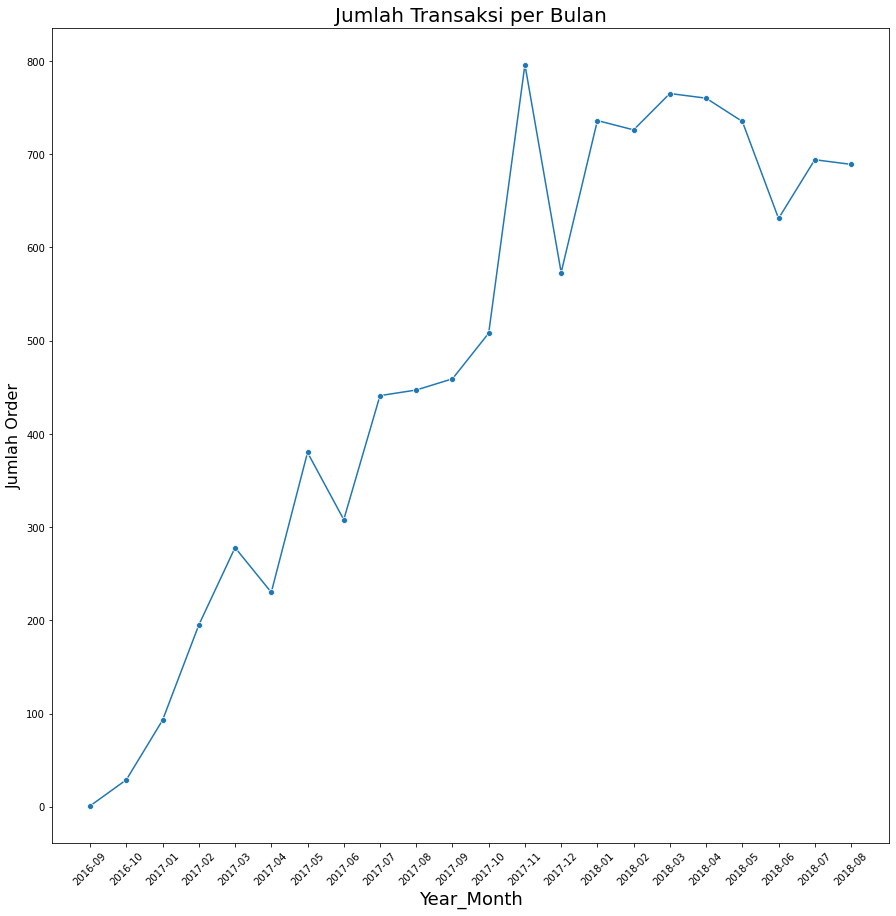

In [34]:
order_month = df3.groupby(['Year_month'])['order_id'].nunique()

plt.figure(figsize=(15,15))
sns.lineplot(data=order_month, x=order_month.index, y=order_month.values, marker='o')
plt.title('Jumlah Transaksi per Bulan', fontsize=20)
plt.xlabel('Year_Month',fontsize=18)
plt.ylabel('Jumlah Order',fontsize=16)
plt.xticks(rotation=45)
plt.show()

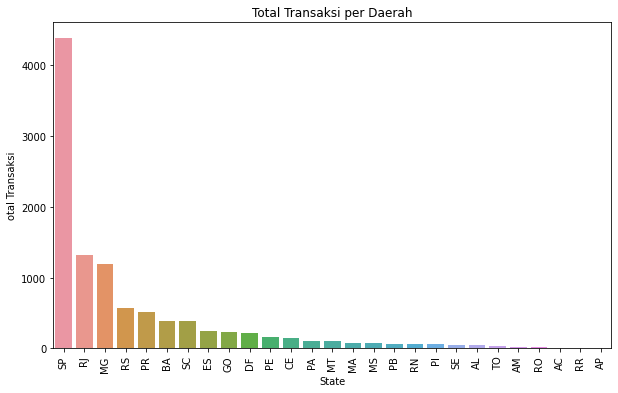

In [35]:
# Menghitung banyak order berdasarkan State
order_state = df3.groupby('customer_state')['order_id'].nunique().reset_index(name='count')

# Urutkan state berdasarkan order_id terbanyak
order_state_sort = order_state.sort_values(by='count', ascending=False)

# Visualisasi bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=order_state_sort['customer_state'], y=order_state_sort['count'])
plt.xlabel('State')
plt.ylabel('otal Transaksi')
plt.title('Total Transaksi per Daerah')
plt.xticks(rotation=90)
plt.show()

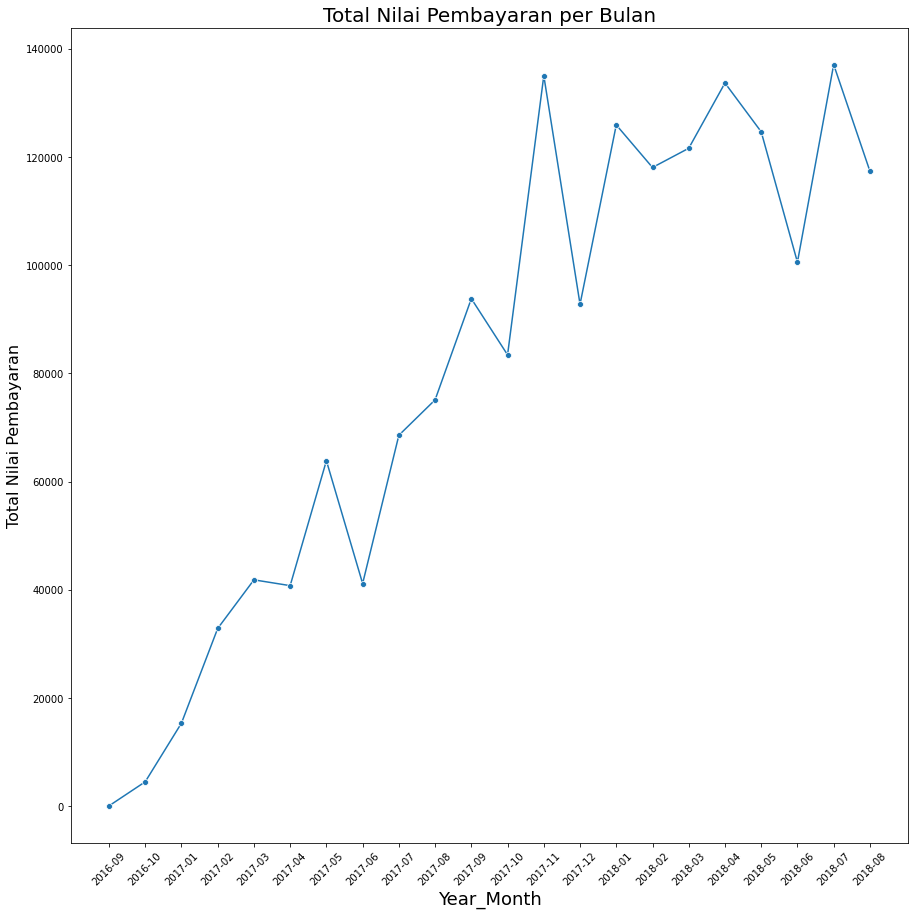

In [36]:
payment_month = df3.groupby(['Year_month'])['payment_value'].sum()

plt.figure(figsize=(15,15))
sns.lineplot(data=payment_month, x=payment_month.index, y=payment_month.values, marker='o')
plt.title('Total Nilai Pembayaran per Bulan', fontsize=20)
plt.xlabel('Year_Month',fontsize=18)
plt.ylabel('Total Nilai Pembayaran',fontsize=16)
plt.xticks(rotation=45)
plt.show()

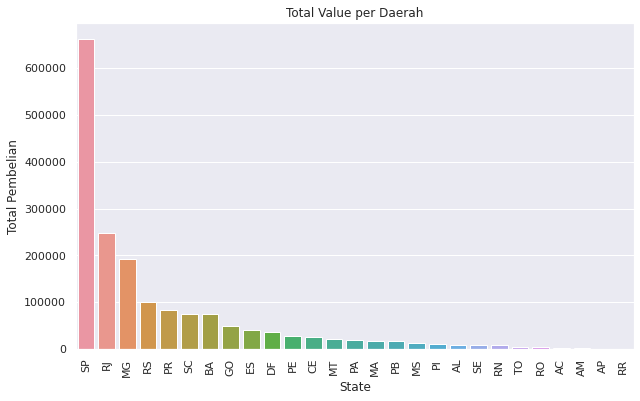

In [85]:
# Menghitung julmah Nilai transaksi berdasarkan State
value_state = df3.groupby('customer_state')['payment_value'].sum().reset_index(name='sum')

# Urutkan state berdasarkan payment_value tertinggi
value_state_sort = value_state.sort_values(by='sum', ascending=False)

# Visualisasi bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=value_state_sort['customer_state'], y=value_state_sort['sum'])
plt.xlabel('State')
plt.ylabel('Total Pembelian')
plt.title('Total Value per Daerah')
plt.xticks(rotation=90)
plt.show()

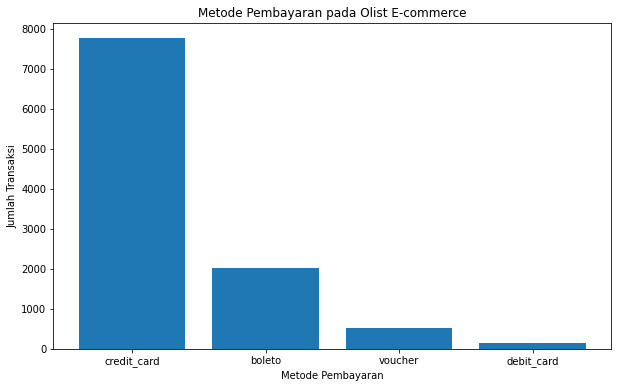

In [38]:
# Menghitung banyaknya Order di setiap tipe pembayaran
payment_total = df3.groupby('payment_type')['order_id'].nunique()

payment_total_sort = payment_total.sort_values(ascending=False)

payment_total_percent = payment_total_sort.cumsum() / payment_total_sort.sum() * 100

# Visualisasi bar chart
plt.figure(figsize=(10, 6))
plt.bar(payment_total_sort.index, payment_total_sort.values)
plt.title('Metode Pembayaran pada Olist E-commerce')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.show()

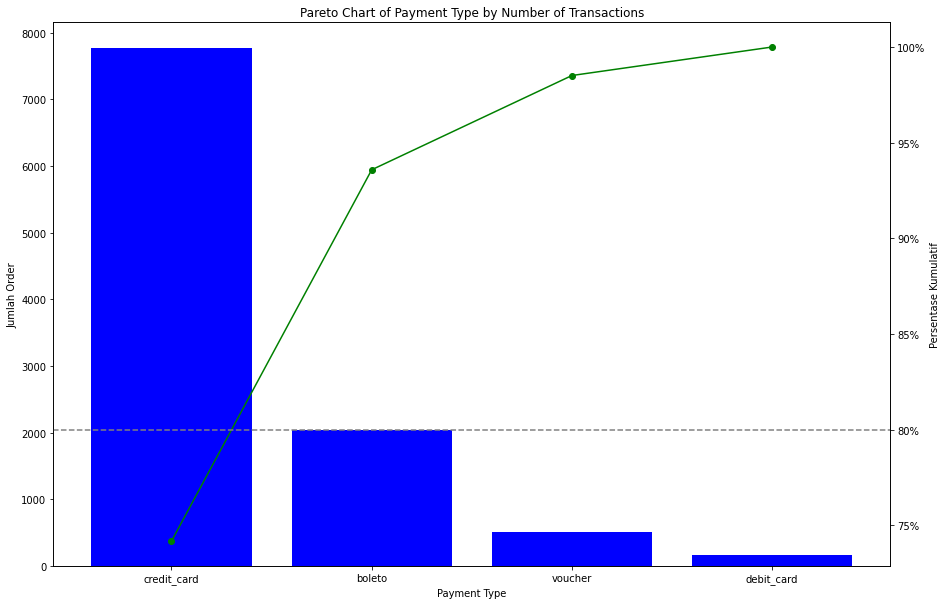

In [39]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.bar(payment_total_sort.index, payment_total_sort.values, color='b')
ax2 = ax.twinx()
ax2.plot(payment_total_sort.index, payment_total_percent, color='g', marker='o')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x/100)))
ax2.axhline(80, color='gray', linestyle='--')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Jumlah Order')
ax2.set_ylabel('Persentase Kumulatif')
ax.set_title('Pareto Chart of Payment Type by Number of Transactions')

plt.show()

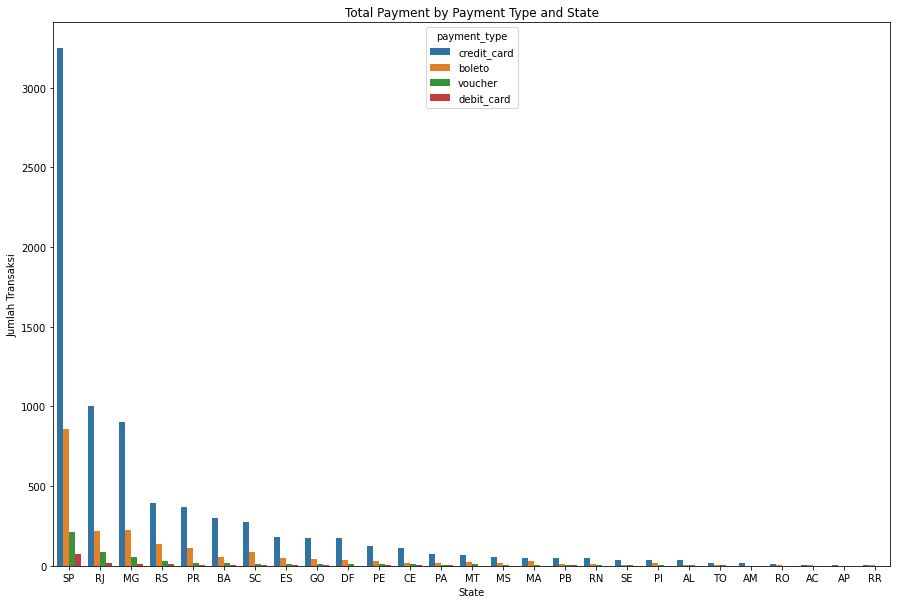

In [40]:
payment_state = df3.groupby(['payment_type', 'customer_state'])['order_id'].nunique().reset_index()

payment_state_sort = payment_state.sort_values(by='order_id',ascending=False)

# Create a bar chart to show payment_value for each payment_type and state combination
plt.figure(figsize=(15, 10))
sns.barplot(x='customer_state', y='order_id', hue='payment_type', data=payment_state_sort)
plt.title('Total Payment by Payment Type and State')
plt.xlabel('State')
plt.ylabel('Jumlah Transaksi')
plt.show()

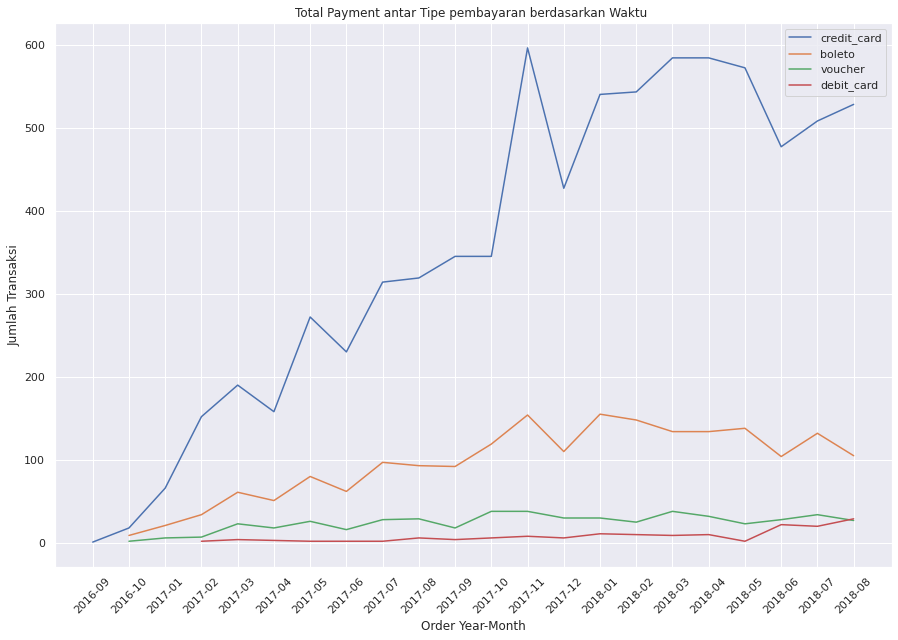

In [86]:
payment_time = df3.groupby(['payment_type', 'Year_month'])['order_id'].nunique().reset_index()
payment_time_sort = payment_time.sort_values(by='Year_month',ascending=True)
# Create a line chart to show payment_value for each payment_type over time
plt.figure(figsize=(15, 10))
for payment_type in payment_time_sort['payment_type'].unique():
    plt.plot(payment_time_sort[payment_time_sort['payment_type'] == payment_type]['Year_month'], 
             payment_time_sort[payment_time_sort['payment_type'] == payment_type]['order_id'], 
             label=payment_type)
plt.title('Total Payment antar Tipe pembayaran berdasarkan Waktu ')
plt.xlabel('Order Year-Month')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [42]:
tranksaksi_per_jam = df3.groupby(['day_name', 'hour']).size().reset_index(name='count')

transactions_pivot = tranksaksi_per_jam.pivot('day_name', 'hour', 'count').reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
transactions_pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Monday,30.0,17.0,10.0,3.0,2.0,3.0,5.0,15.0,64.0,82.0,...,101.0,121.0,127.0,111.0,109.0,108.0,100.0,102.0,102.0,83.0
Tuesday,43.0,10.0,8.0,3.0,4.0,2.0,4.0,21.0,56.0,103.0,...,130.0,109.0,106.0,88.0,95.0,80.0,103.0,122.0,117.0,71.0
Wednesday,51.0,21.0,8.0,NaN,7.0,5.0,11.0,21.0,47.0,94.0,...,95.0,117.0,113.0,99.0,85.0,92.0,122.0,82.0,101.0,69.0
Thursday,34.0,23.0,12.0,6.0,2.0,2.0,6.0,28.0,46.0,79.0,...,101.0,88.0,133.0,97.0,85.0,86.0,90.0,78.0,79.0,54.0
Friday,44.0,22.0,3.0,6.0,5.0,2.0,7.0,16.0,45.0,74.0,...,97.0,118.0,97.0,86.0,77.0,85.0,80.0,84.0,67.0,51.0
Saturday,36.0,16.0,7.0,5.0,2.0,2.0,7.0,13.0,26.0,50.0,...,66.0,68.0,67.0,76.0,73.0,69.0,81.0,62.0,61.0,38.0
Sunday,28.0,14.0,14.0,4.0,3.0,3.0,7.0,10.0,21.0,33.0,...,61.0,71.0,61.0,85.0,82.0,88.0,94.0,73.0,110.0,70.0


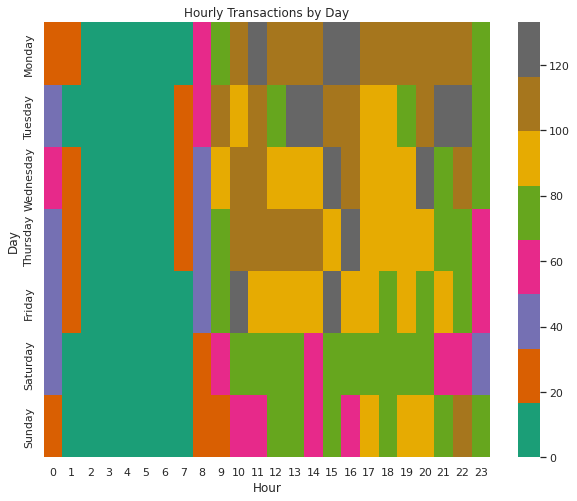

In [43]:
transactions_pivot_update = transactions_pivot.fillna(0)

sns.set(rc={'figure.figsize':(10,8)})
sns.heatmap(transactions_pivot_update, cmap='Dark2')
plt.title('Hourly Transactions by Day')
plt.xlabel('Hour')
plt.ylabel('Day')
plt.show()

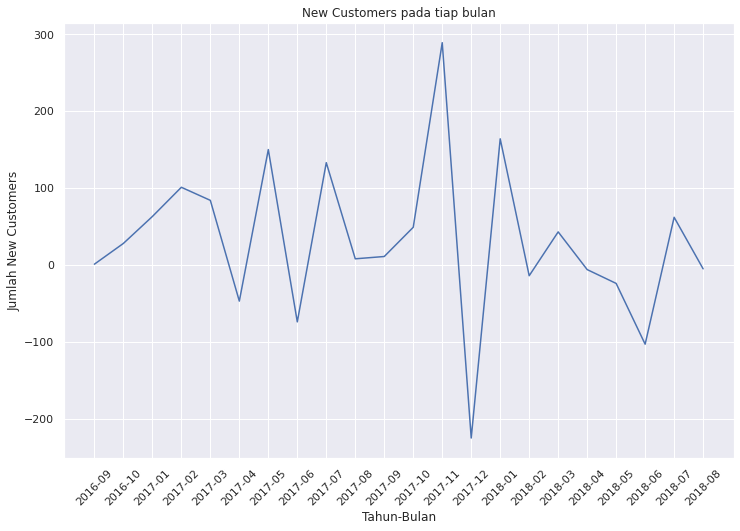

In [44]:
# Menghitung jumlah Customer_unique berdasarkan Waktu
data_customer_unique = df3.groupby(['Year_month'])['customer_unique_id'].nunique().reset_index().sort_values(by='Year_month',ascending=True)

# Menghitung New Customer dengan cara menghitung selisih dari bulan sebelumnya
data_customer_unique['new_customers'] = data_customer_unique['customer_unique_id'].diff().fillna(data_customer_unique['customer_unique_id'])

# Membuat visualisasi New Customer berdasarkan Waktu
plt.figure(figsize=(12, 8))
plt.plot(data_customer_unique['Year_month'], data_customer_unique['new_customers'])
plt.title('New Customers pada tiap bulan')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Jumlah New Customers')
plt.xticks(rotation=45)
plt.show()

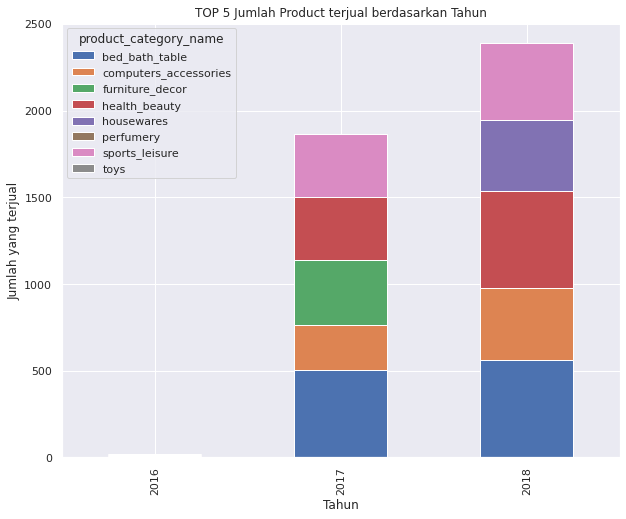

In [45]:
tahun_products = df3.groupby(['Tahun', 'product_category_name'])['product_id.1'].count().reset_index().sort_values(['Tahun', 'product_id.1'], ascending=[True, False])

top5_tahun_products = tahun_products.groupby('Tahun').head(5)
top5_tahun_products

top_category_Year= top5_tahun_products.pivot(index='Tahun', columns='product_category_name', values='product_id.1')
top_category_Year.plot(kind='bar', stacked=True)
plt.title('TOP 5 Jumlah Product terjual berdasarkan Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah yang terjual')
plt.show()

In [46]:
# Group data by order_year and product_category_name, and count number of products
category_data = df3.groupby(['Tahun', 'product_category_name'])['product_id.1'].count().reset_index()

# Sort the data by order_year and number of products
category_data = category_data.sort_values(['Tahun', 'product_id.1'], ascending=False)

# Create a pivot table to show number of products sold by category and year
category_table = category_data.pivot(index='product_category_name', columns='Tahun', values='product_id.1')

# Select the top 10 product categories
top_categories = category_table.sum(axis=1).sort_values(ascending=False)[:10].index

# Filter the data to only show the top 5 categories
top_category_data = category_data[category_data['product_category_name'].isin(top_categories)]

# Create a pivot table to show number of products sold by top categories and year
top_category_table = top_category_data.pivot(index='product_category_name', columns='Tahun', values='product_id.1')

In [87]:
top_category_table

Tahun,2016,2017,2018
product_category_name,,,
bed_bath_table,NaN,504.0,559.0
computers_accessories,3.0,262.0,415.0
furniture_decor,2.0,370.0,401.0
garden_tools,NaN,251.0,183.0
health_beauty,5.0,367.0,561.0
housewares,NaN,239.0,413.0
sports_leisure,3.0,360.0,440.0
telephony,2.0,217.0,239.0
toys,3.0,262.0,157.0


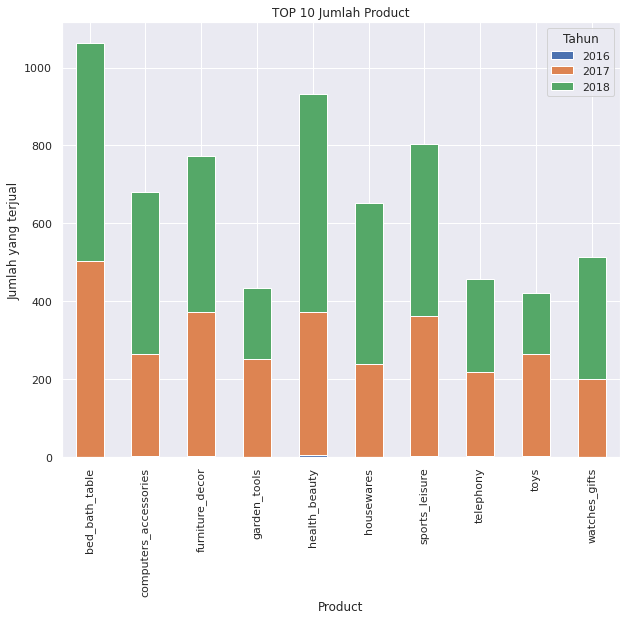

In [47]:
top_category_table.plot(kind='bar', stacked=True)
plt.title('TOP 10 Jumlah Product')
plt.xlabel('Product')
plt.ylabel('Jumlah yang terjual')
plt.show()

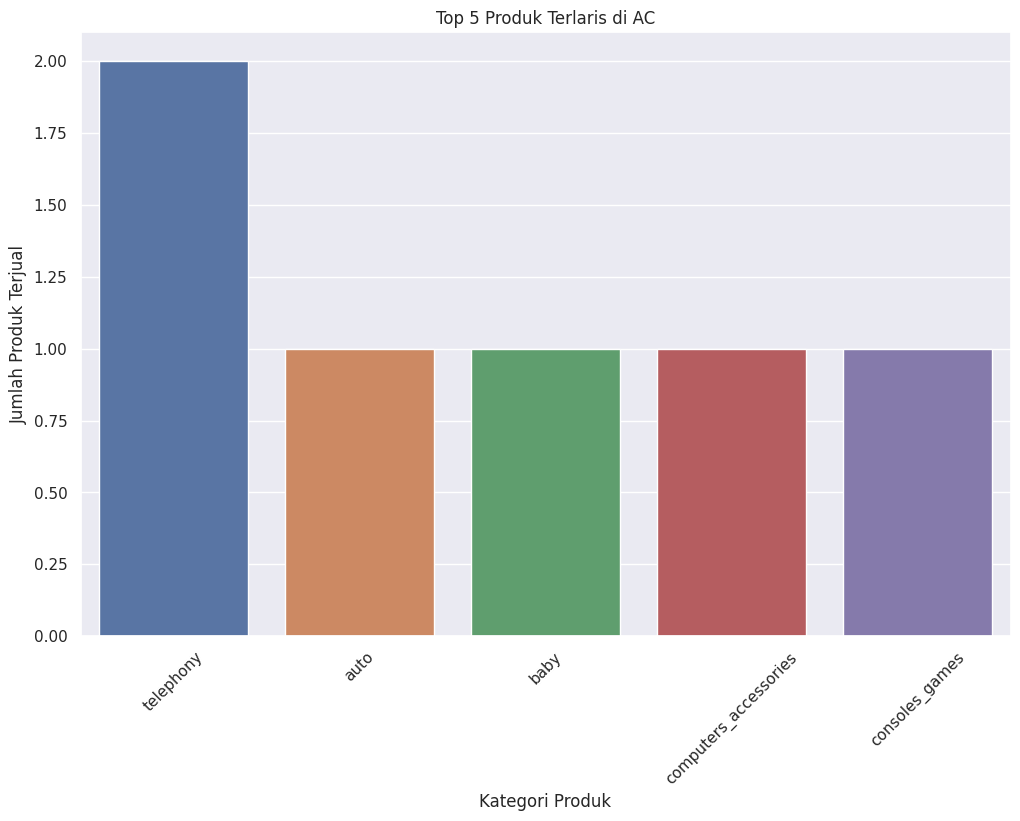

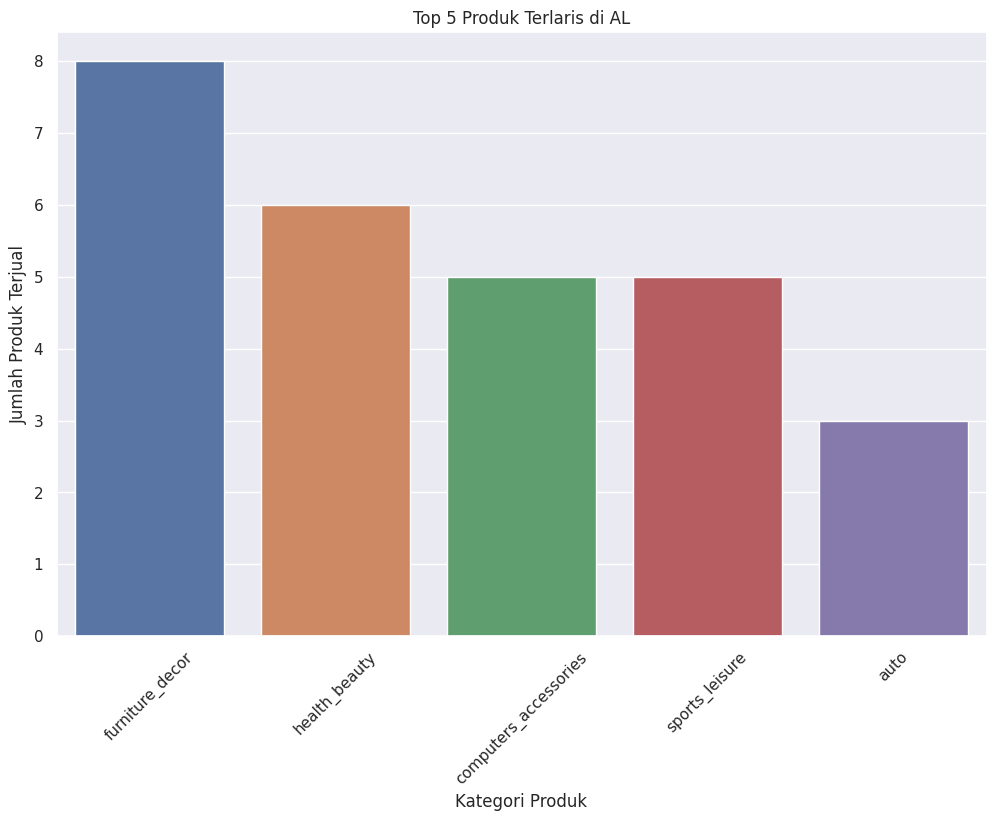

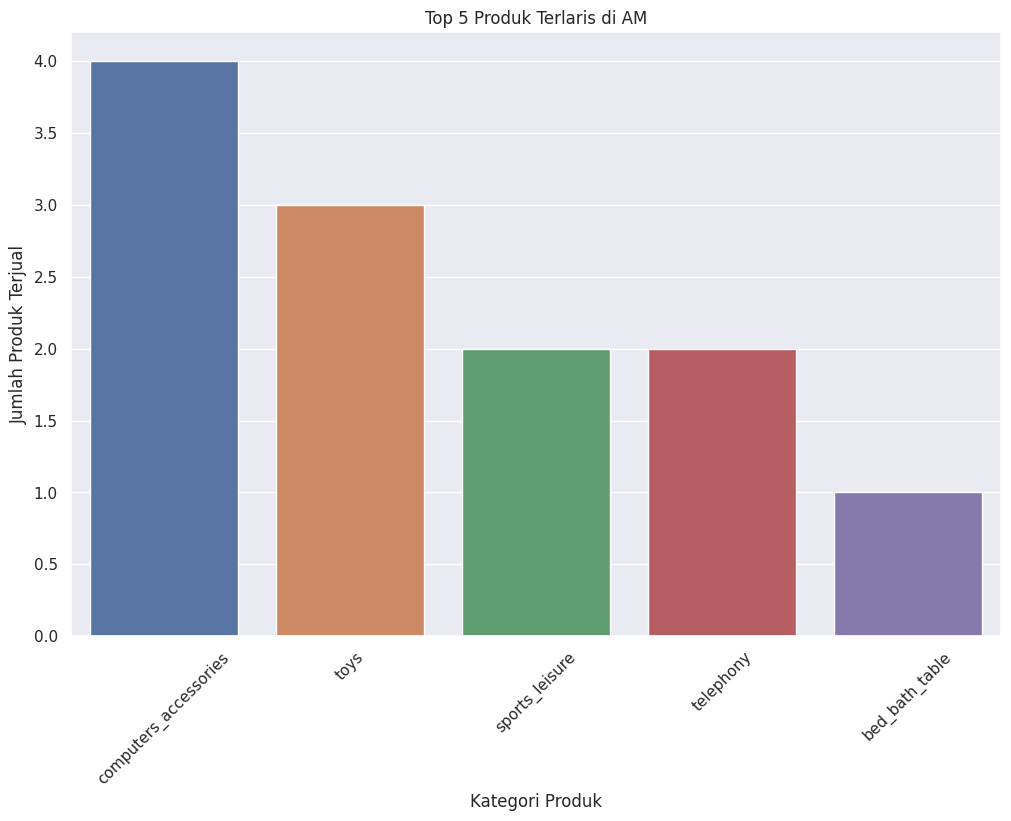

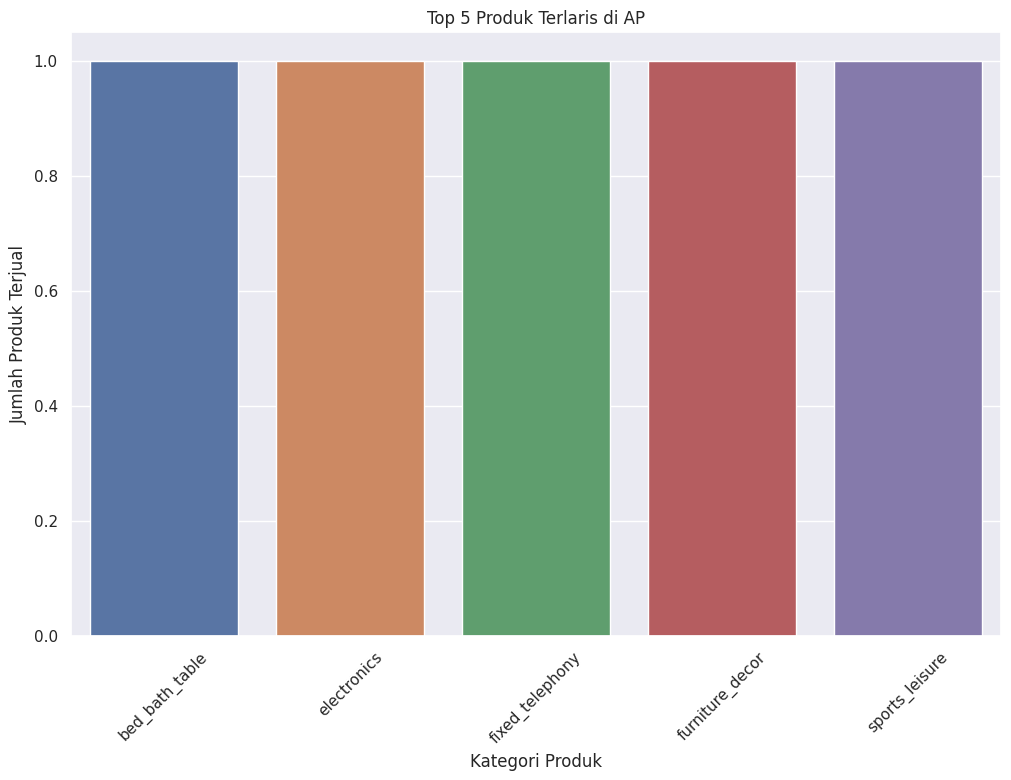

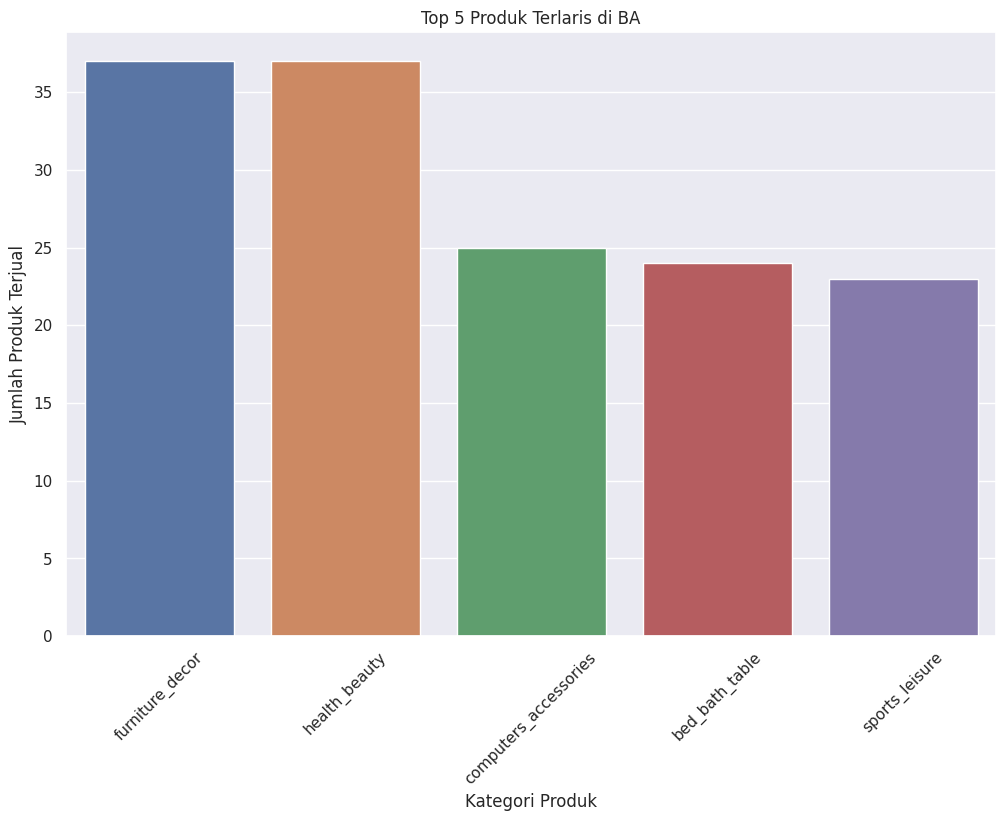

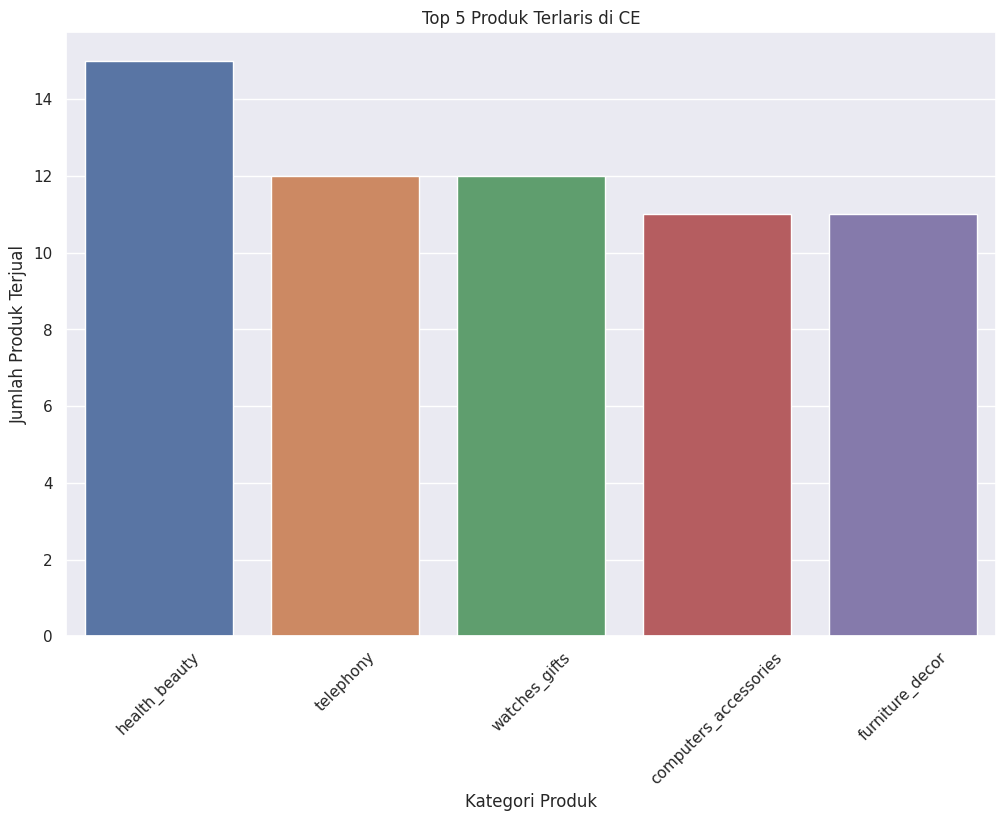

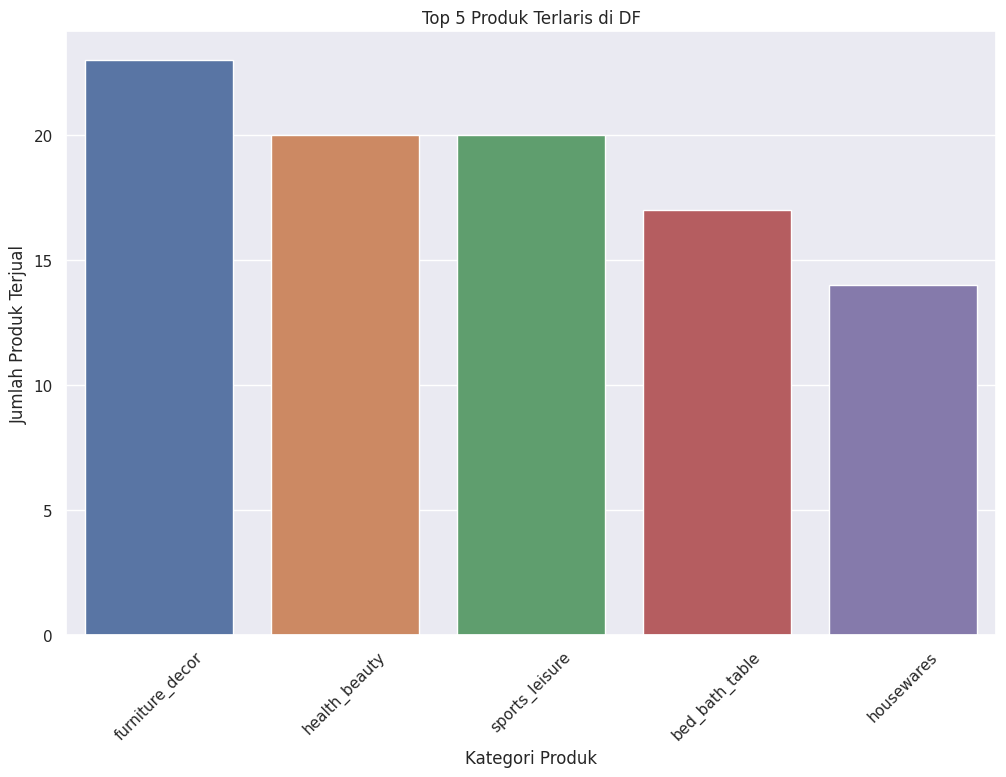

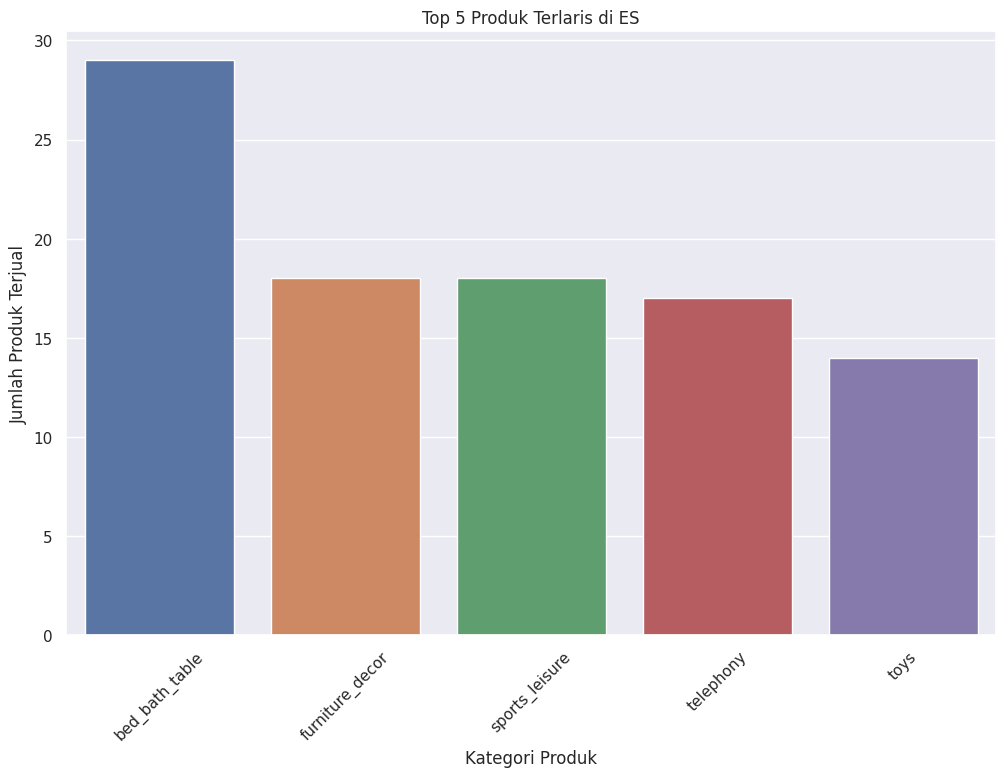

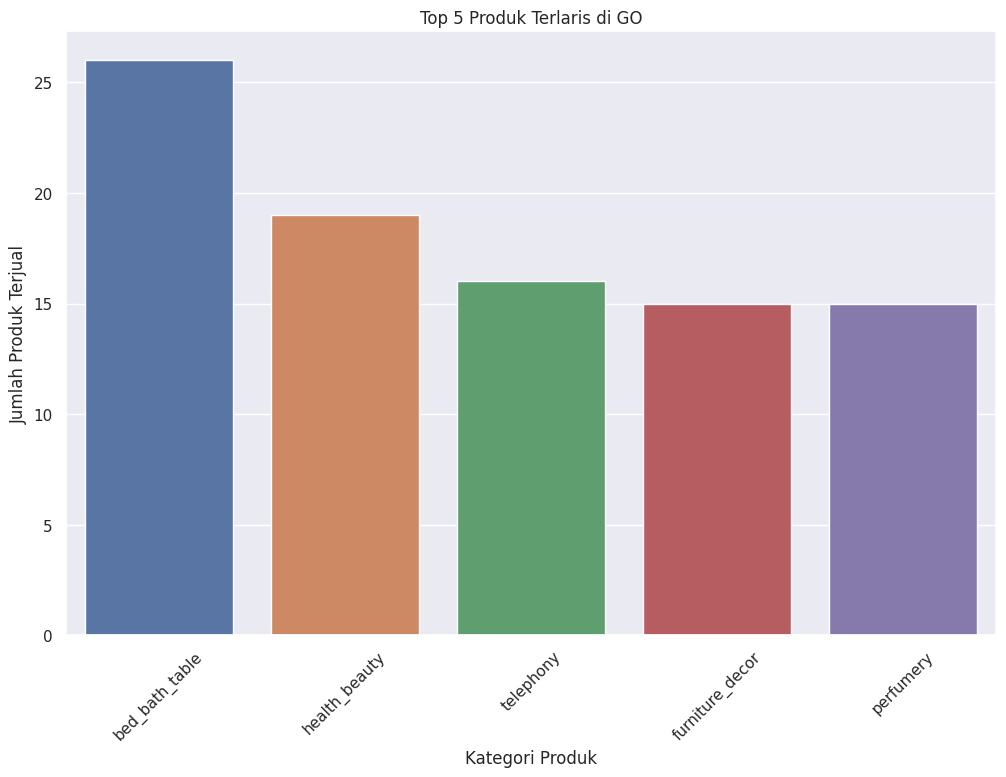

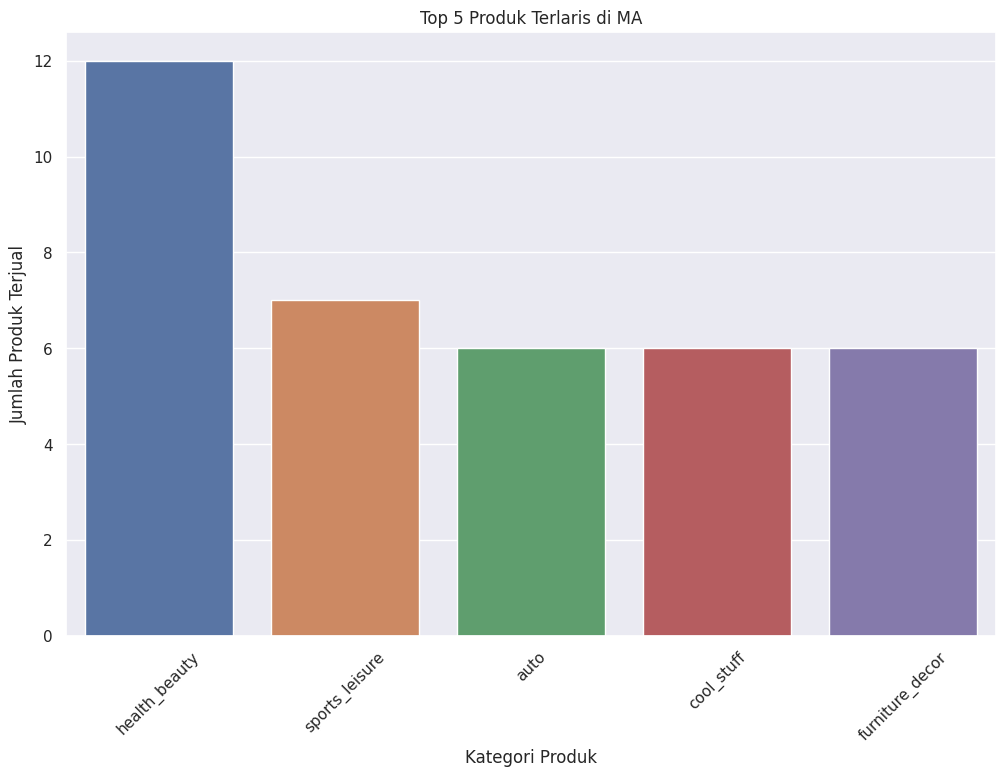

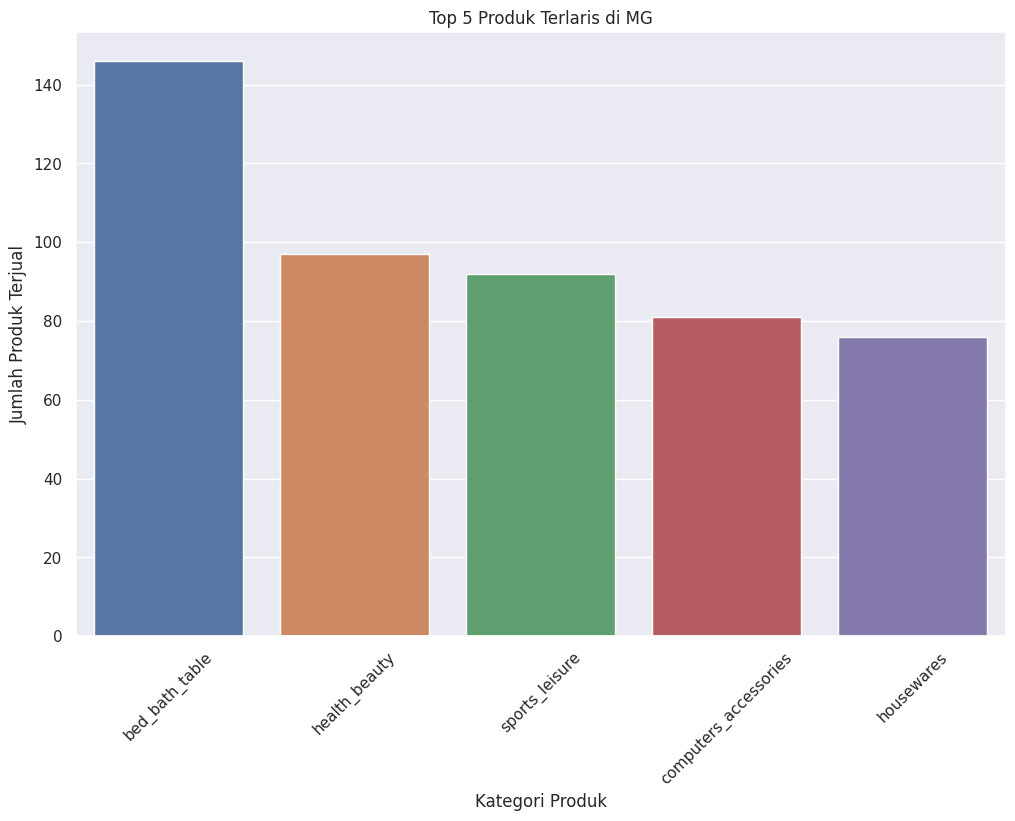

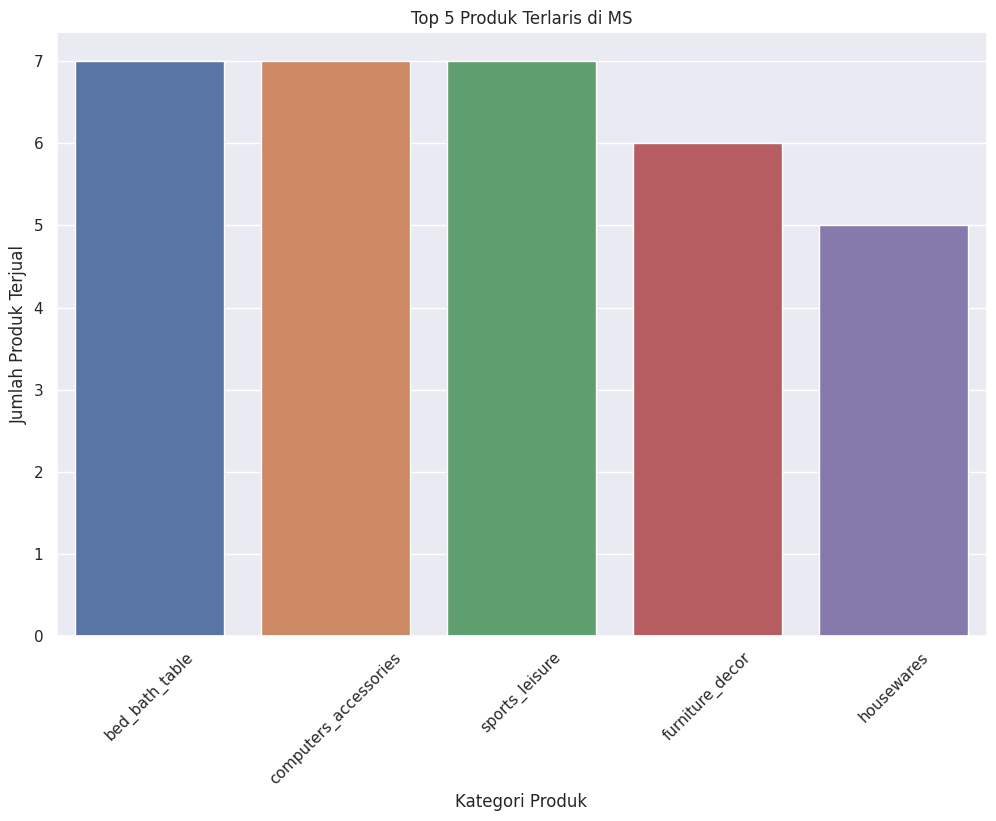

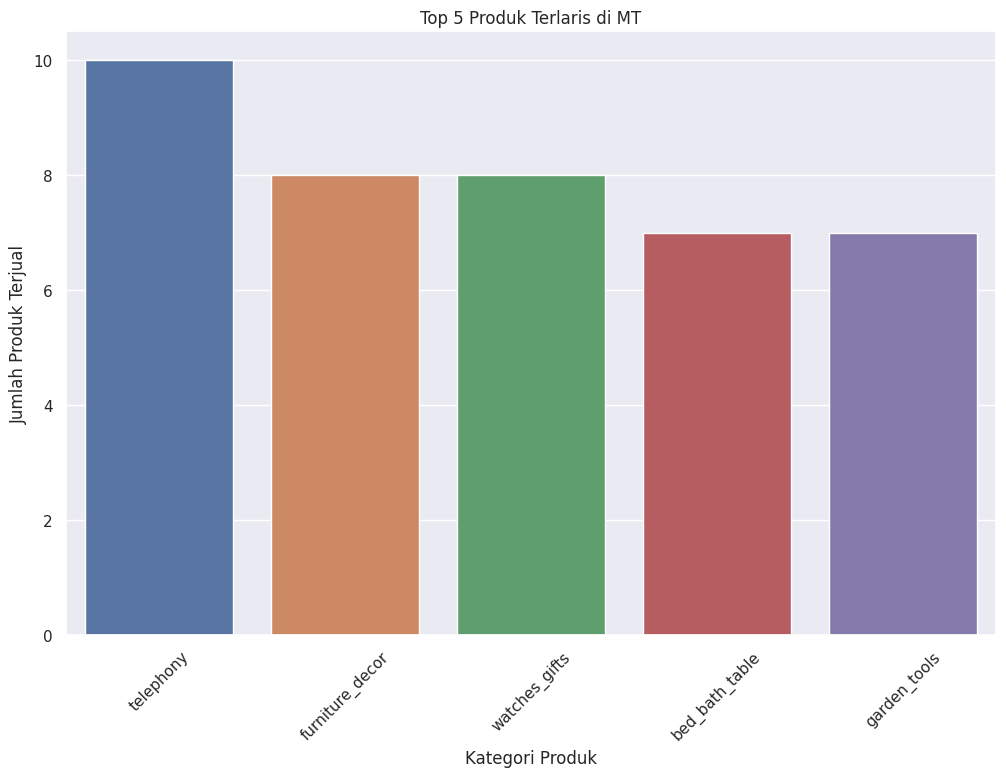

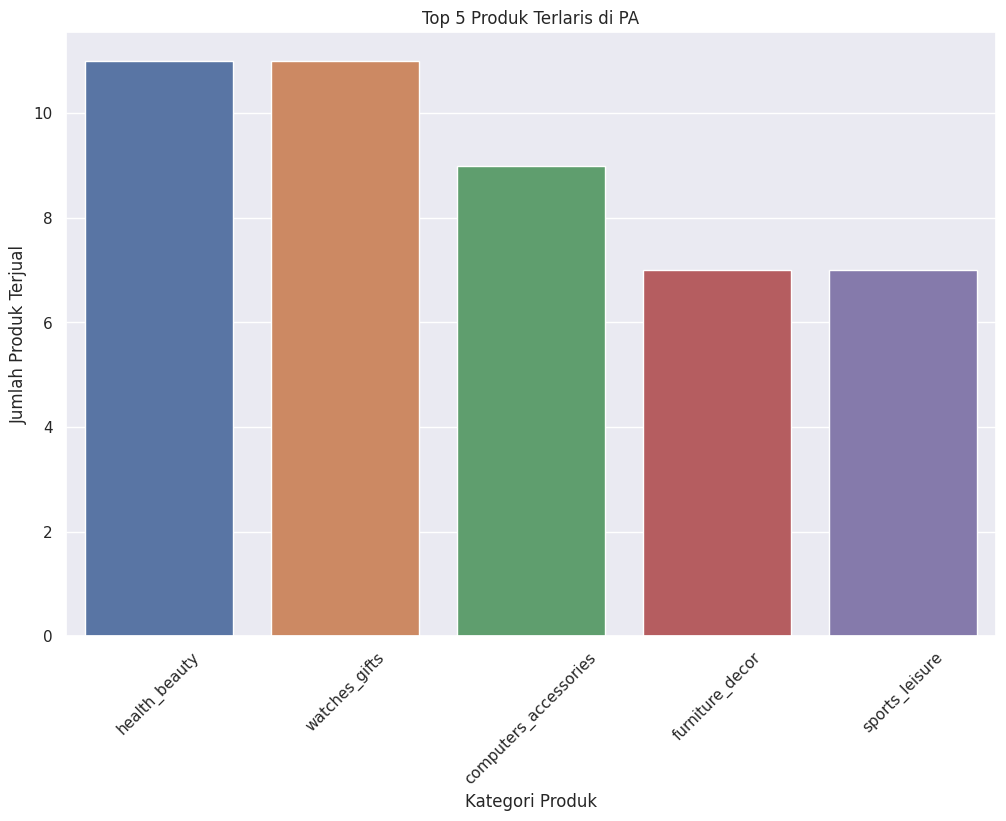

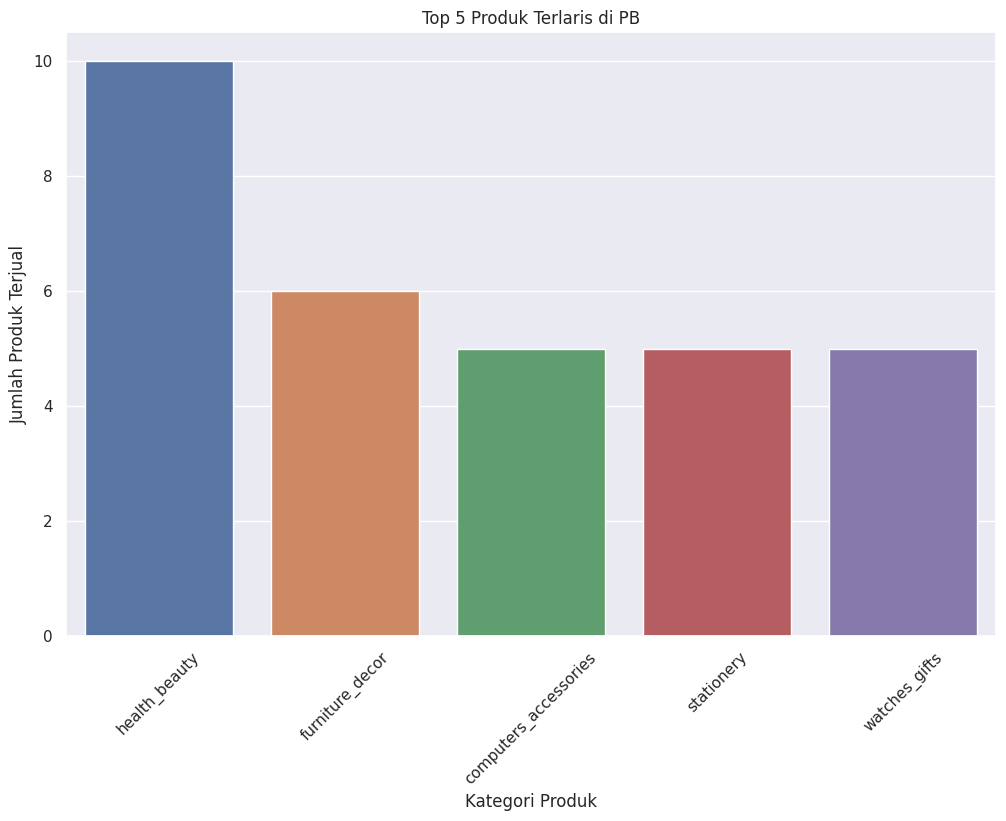

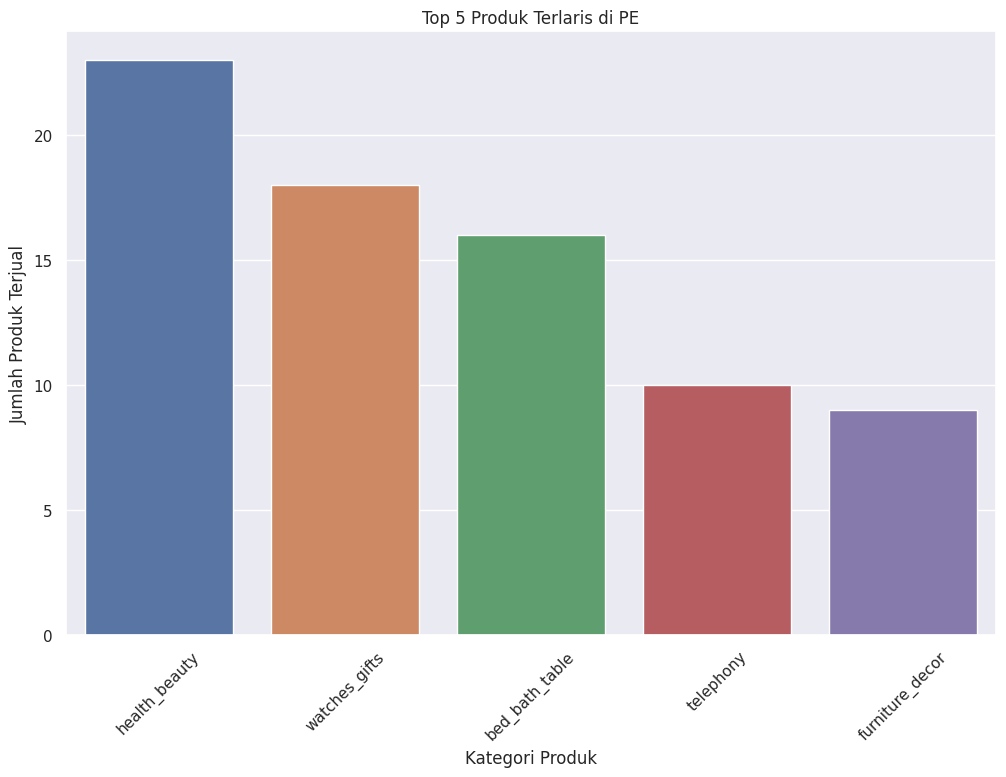

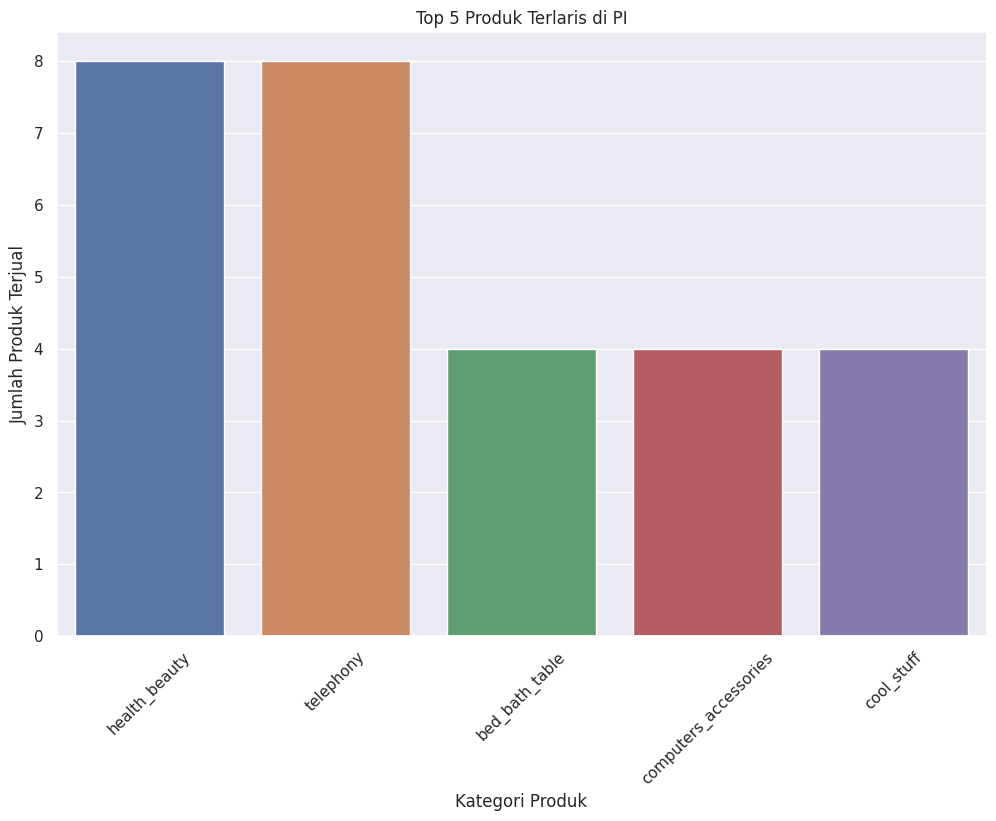

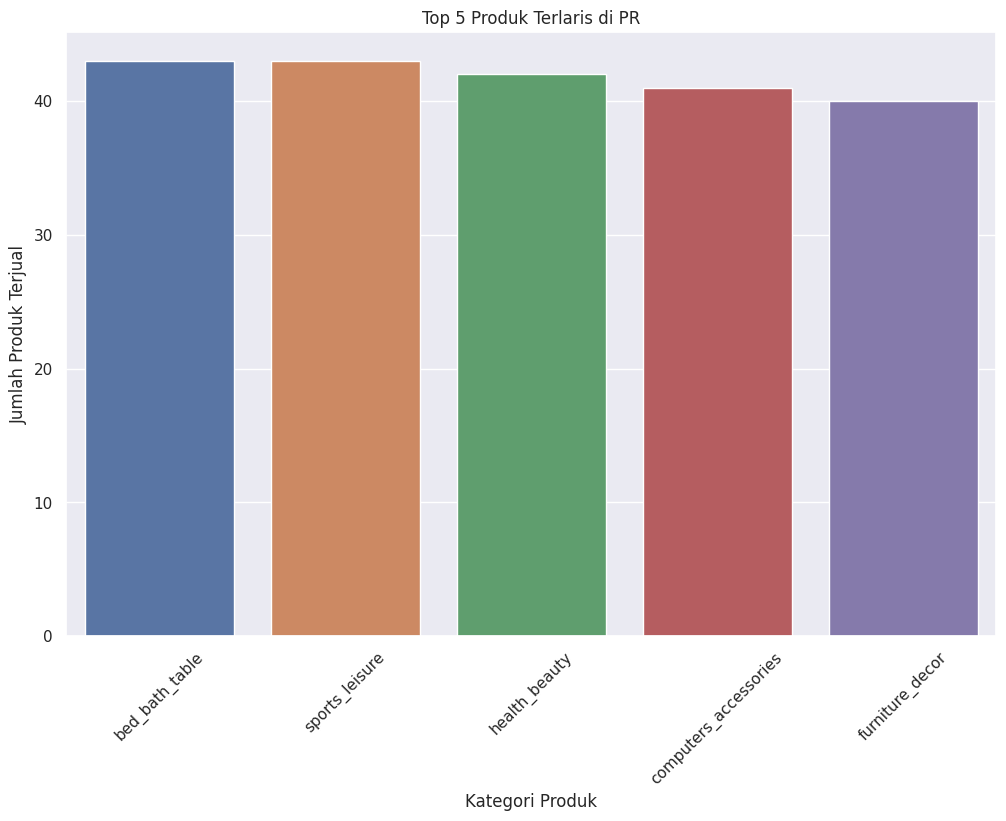

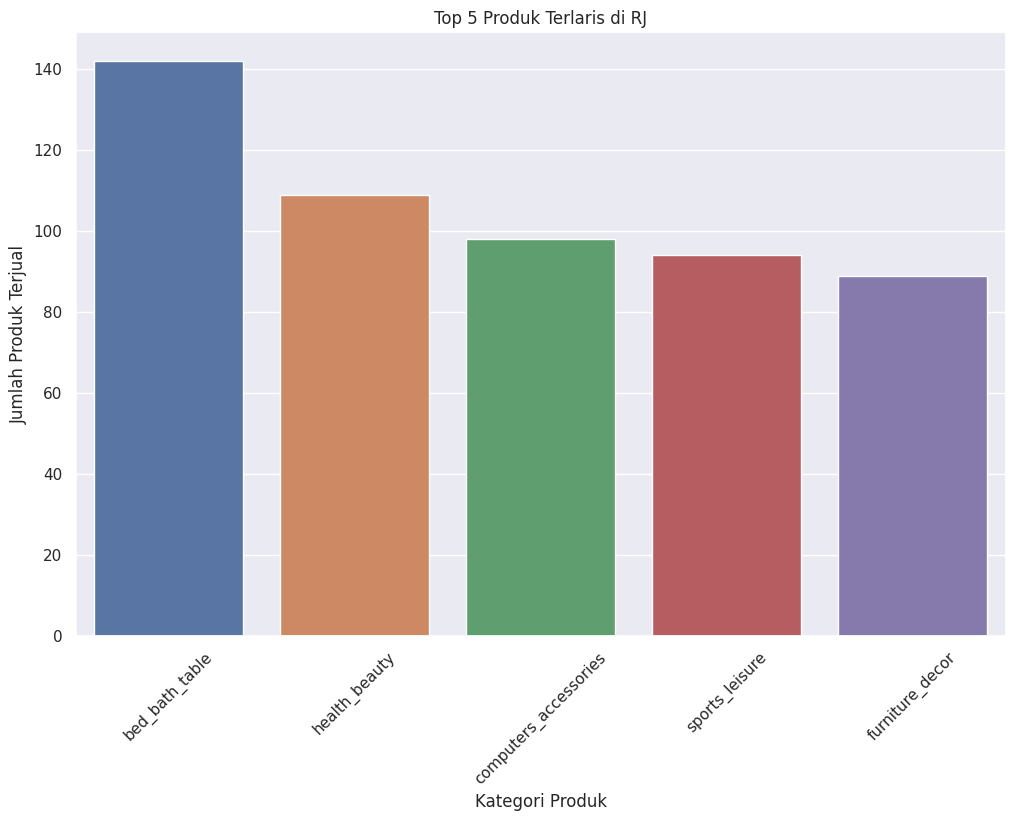

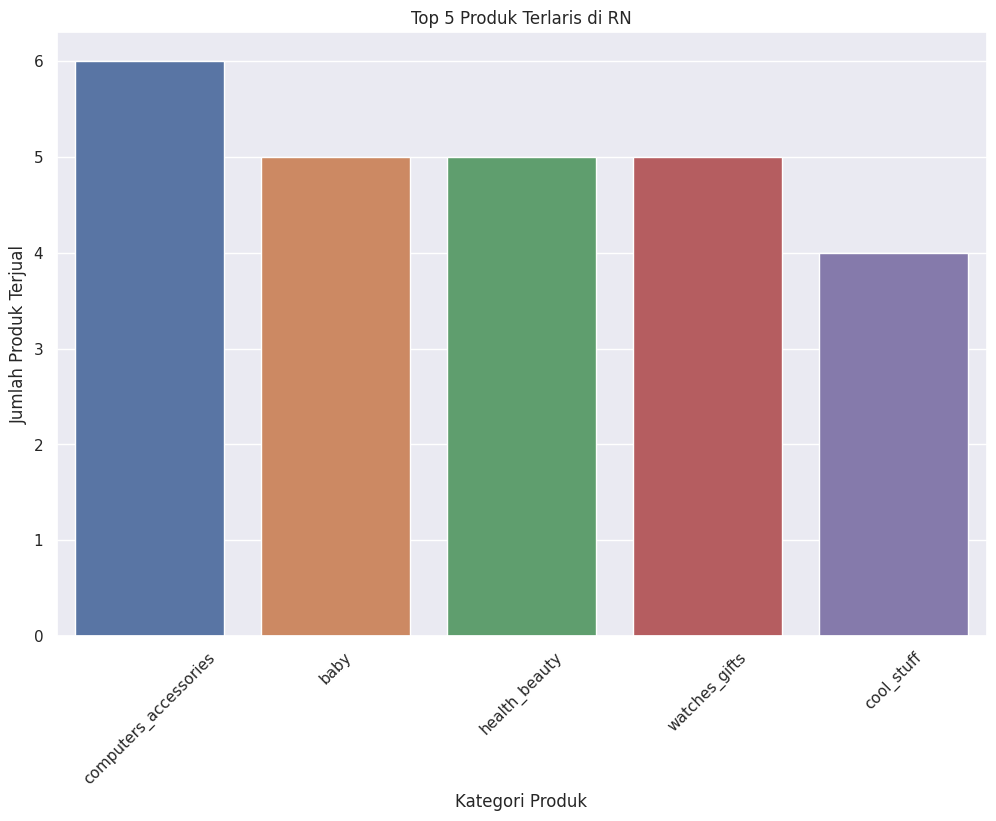

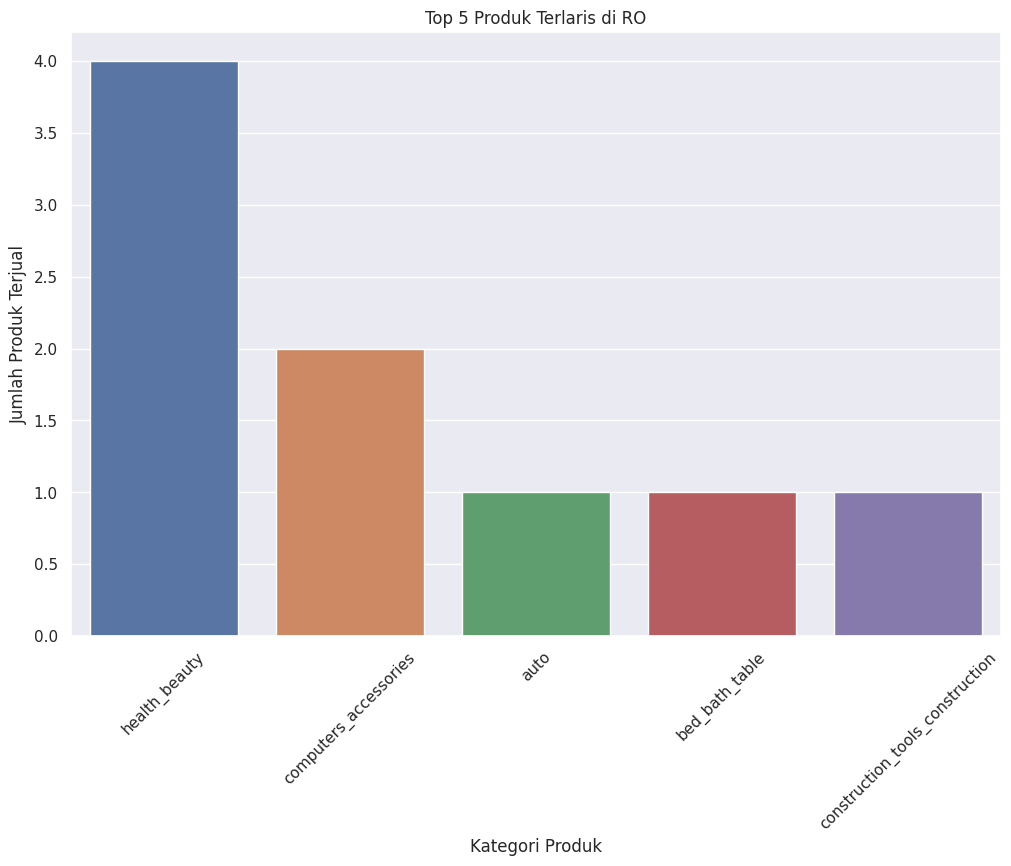

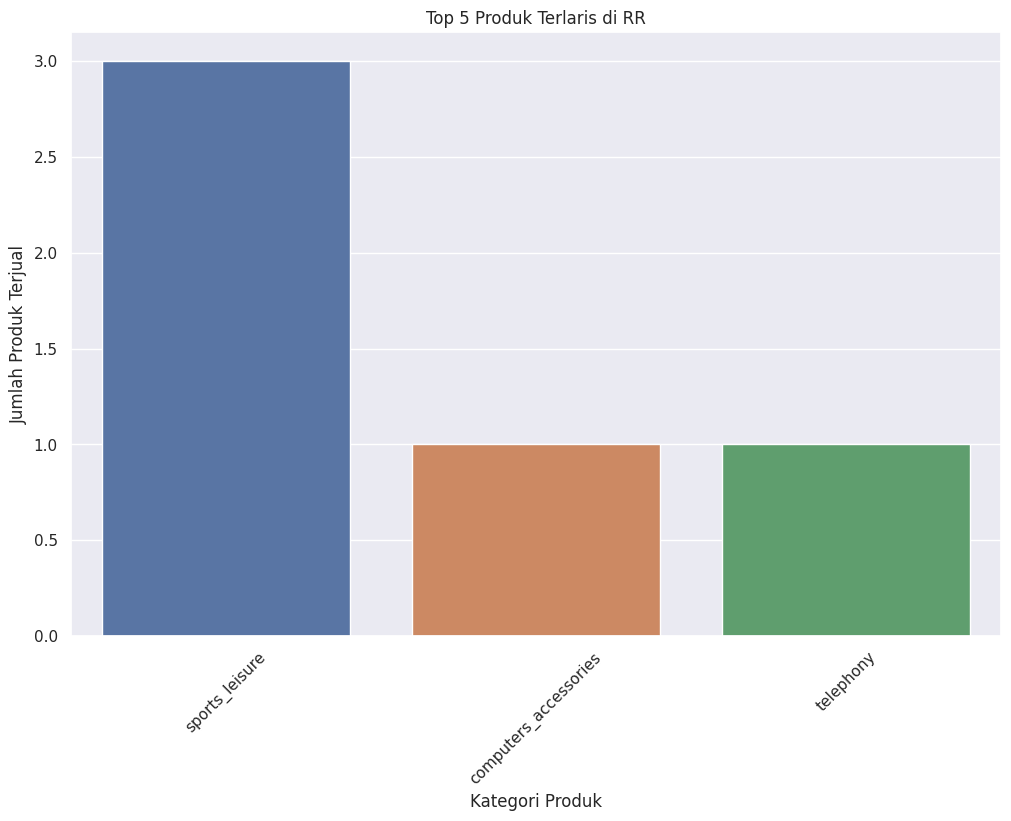

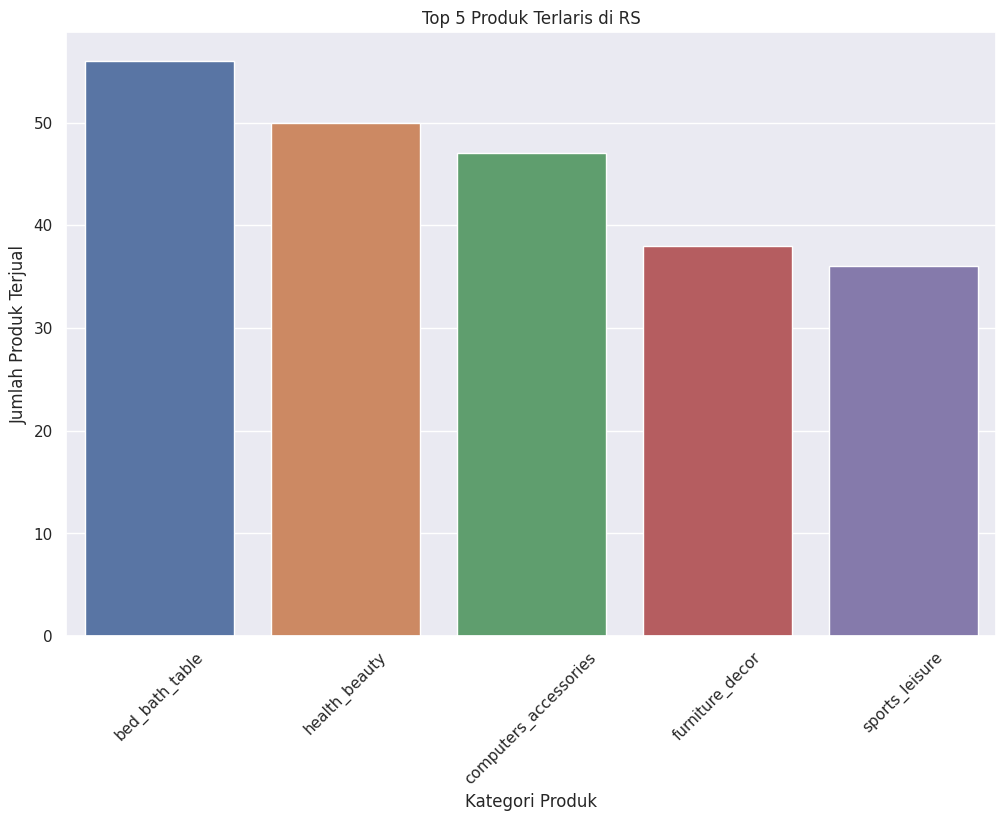

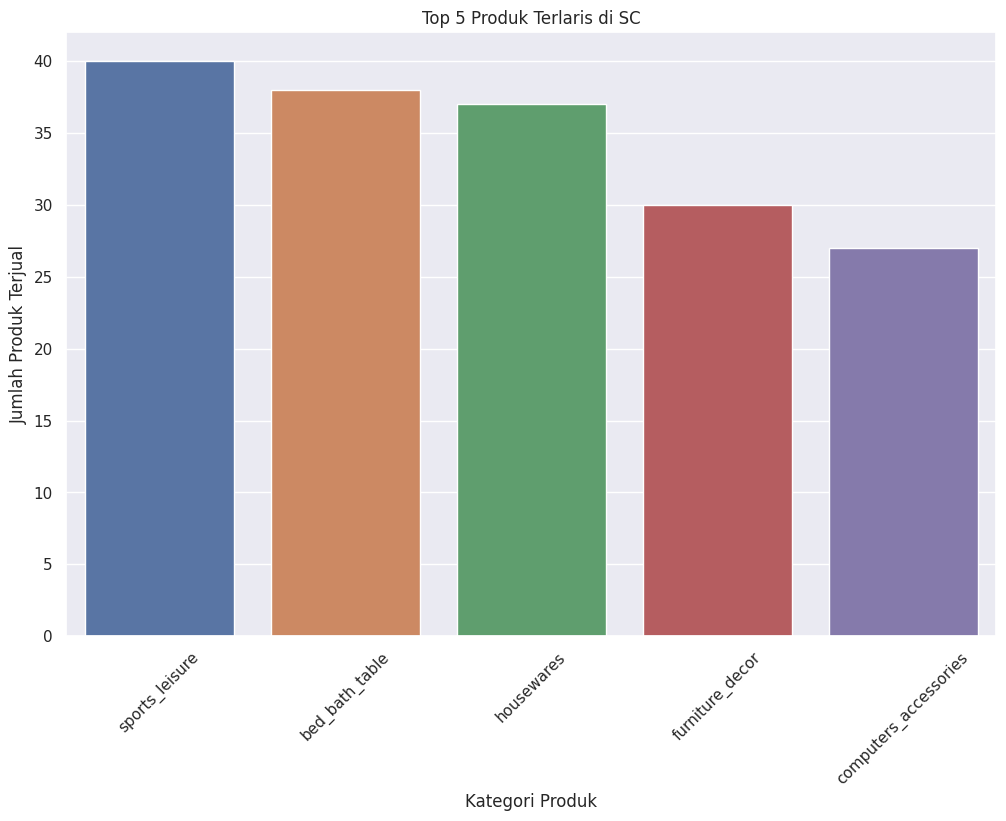

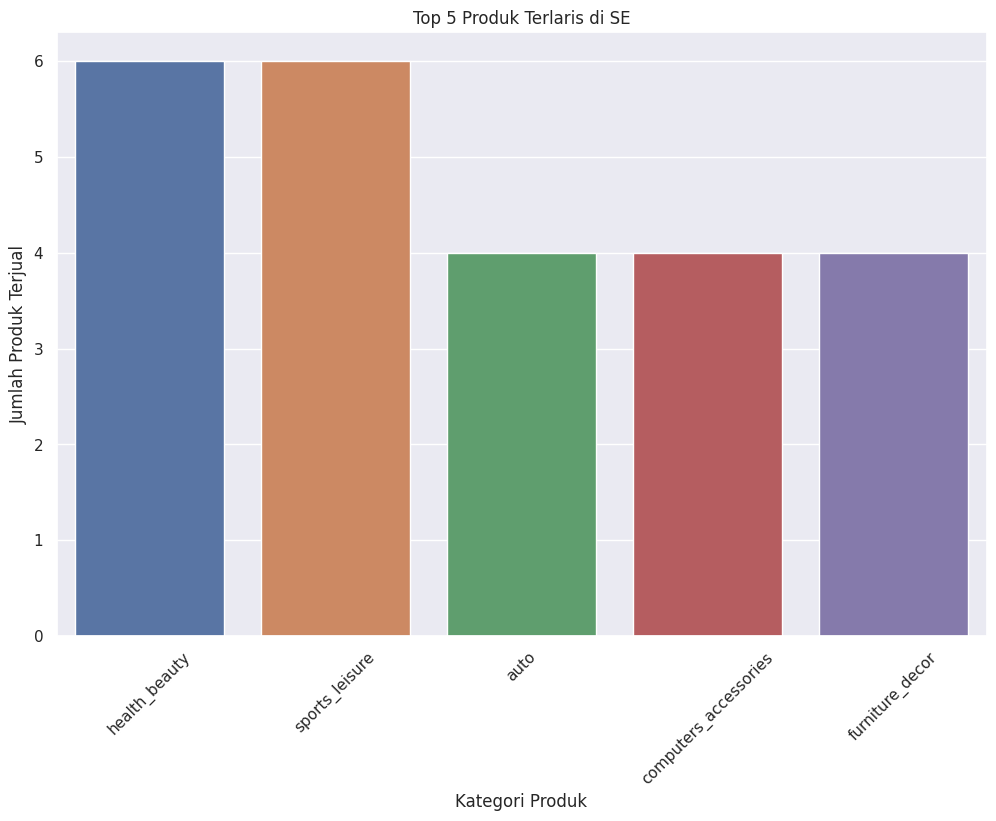

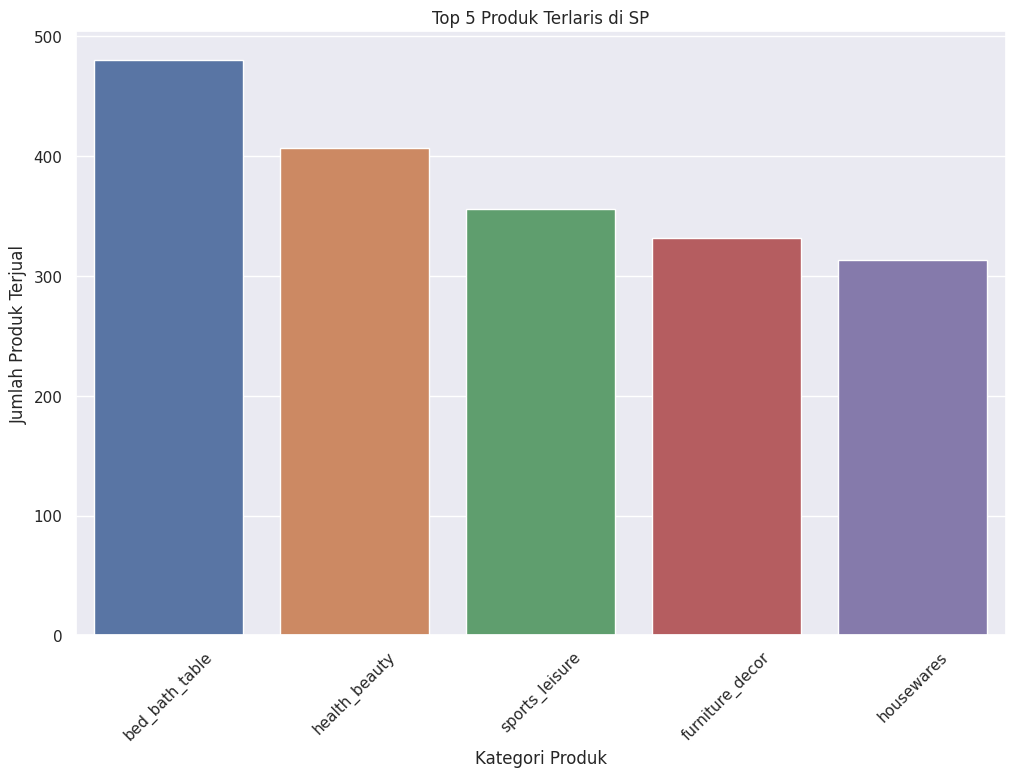

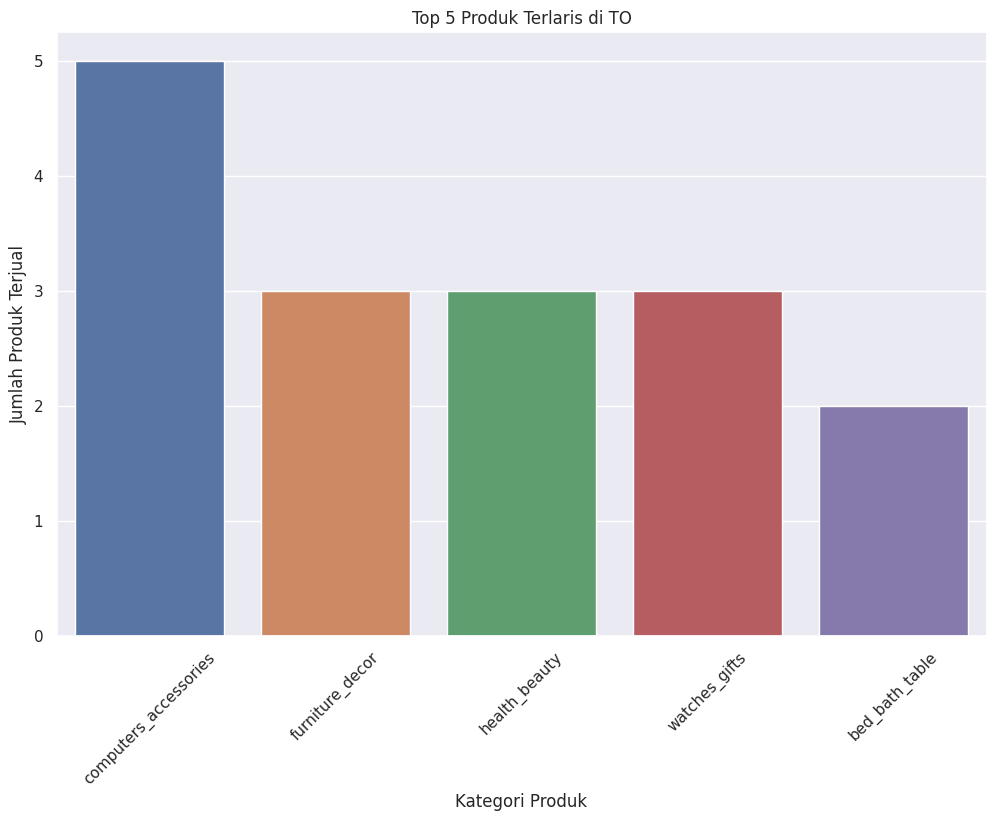

In [48]:
state_products = df3.groupby(['customer_state', 'product_category_name'])['product_id.1'].count().reset_index().sort_values(['customer_state', 'product_id.1'], ascending=[True, False])
top5_state_products = state_products.groupby('customer_state').head(5)

for state in top5_state_products['customer_state'].unique():
    data = top5_state_products[top5_state_products['customer_state'] == state]
    plt.figure(figsize=(12, 8), dpi=100)
    sns.barplot(x='product_category_name', y='product_id.1', data=data)
    plt.title(f'Top 5 Produk Terlaris di {state}')
    plt.xlabel('Kategori Produk')
    plt.ylabel('Jumlah Produk Terjual')
    plt.xticks(rotation=45)
    plt.show()

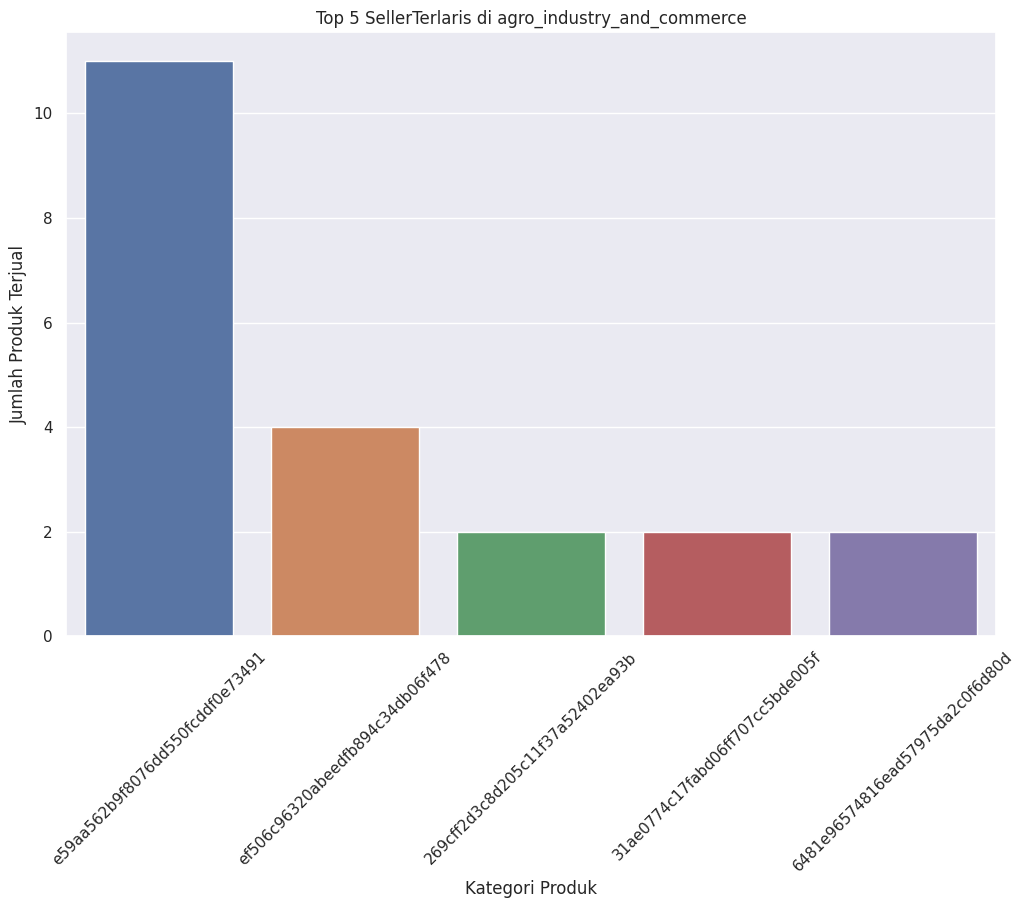

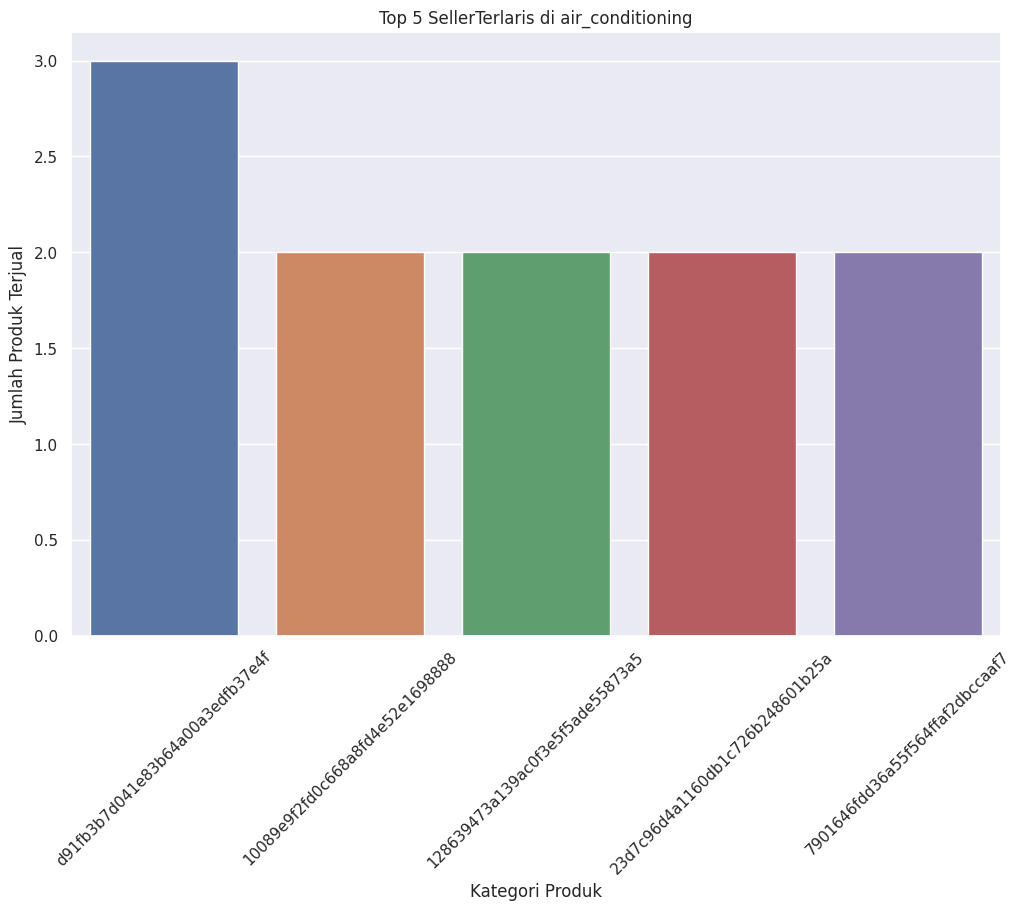

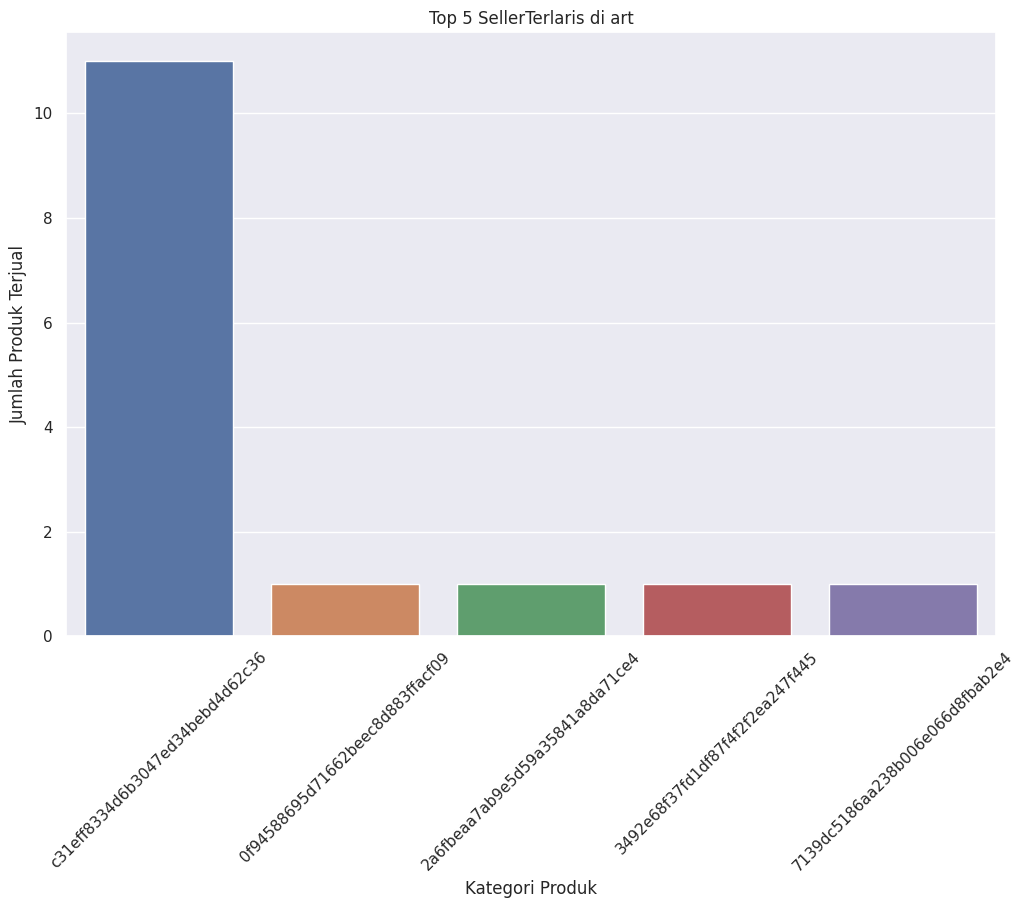

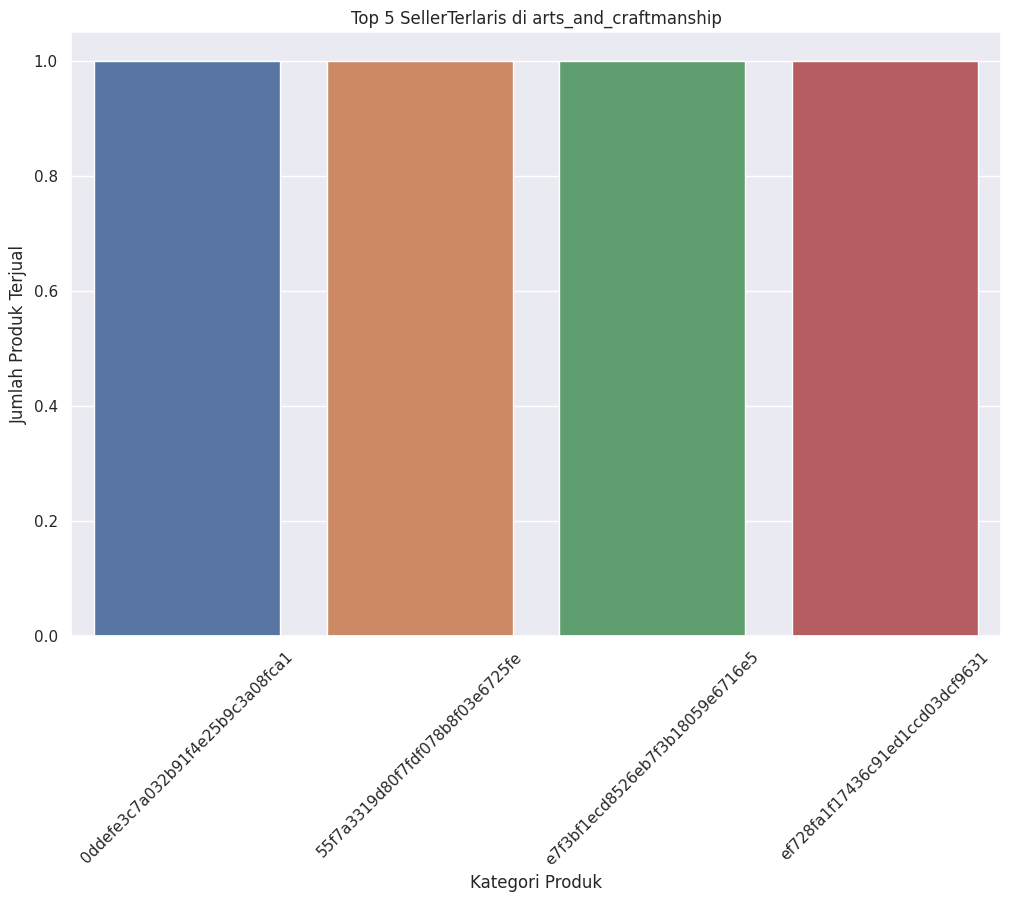

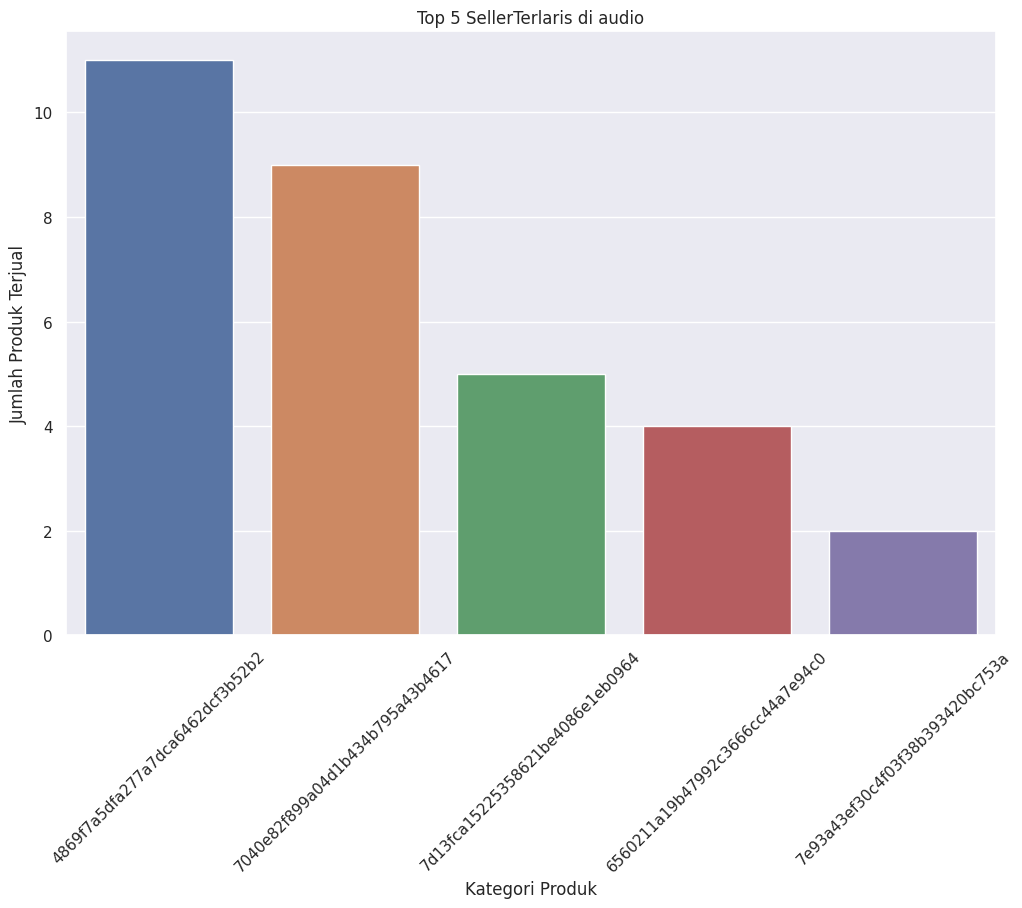

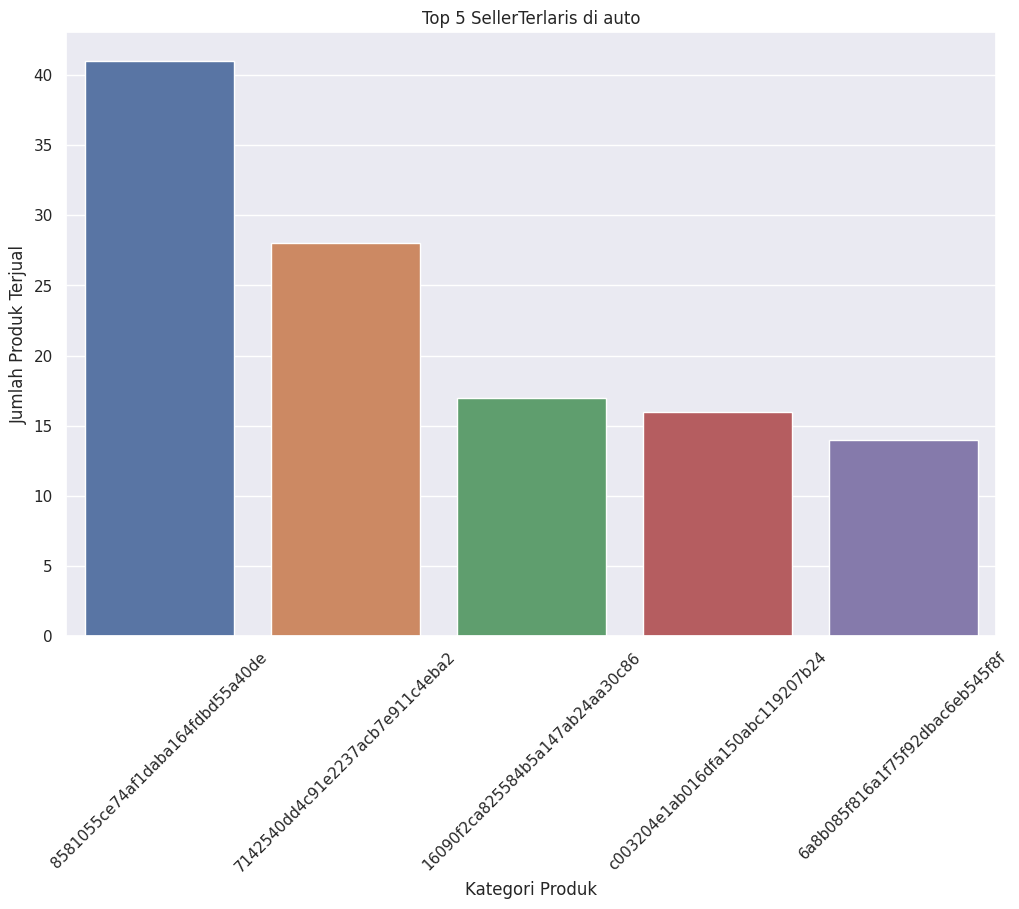

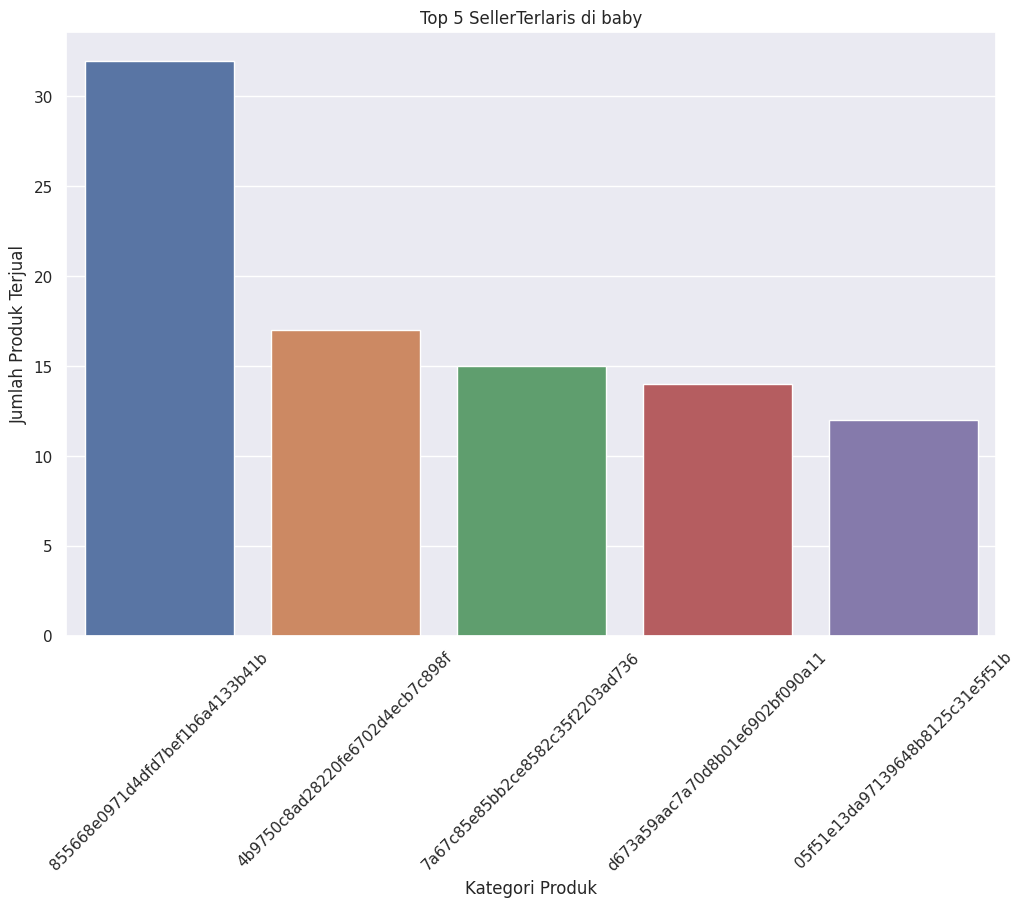

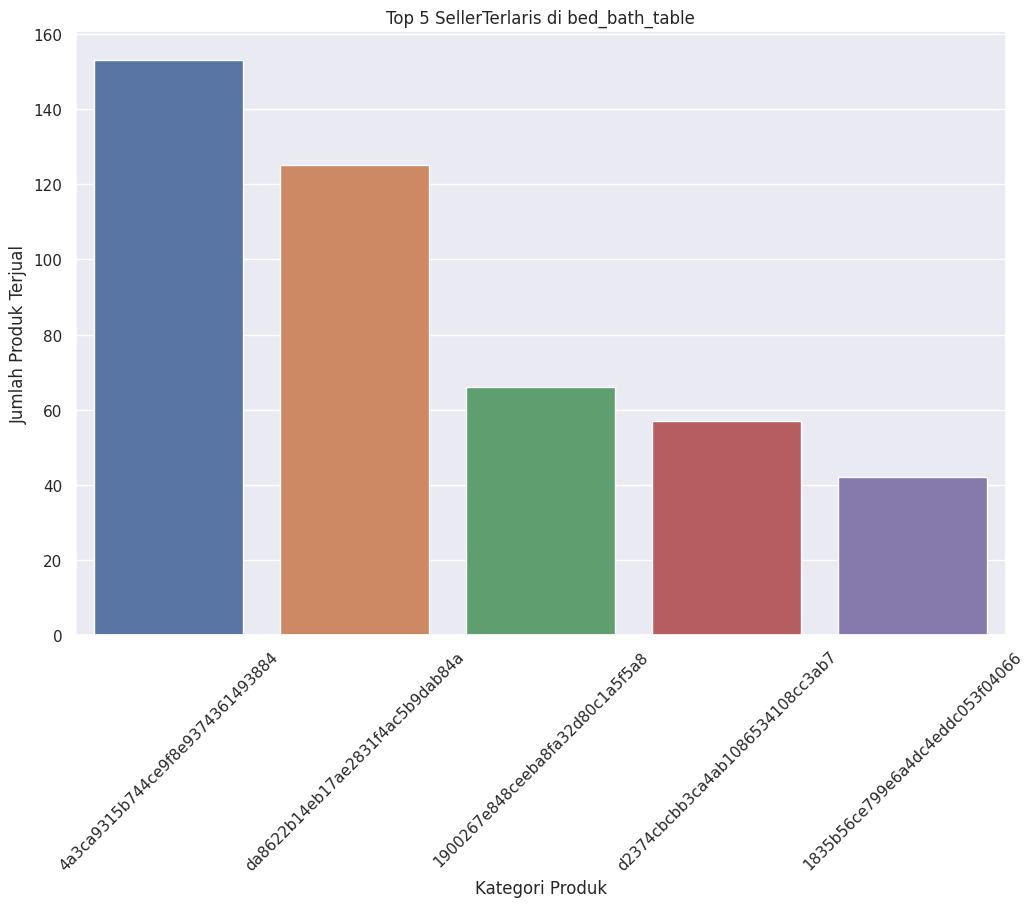

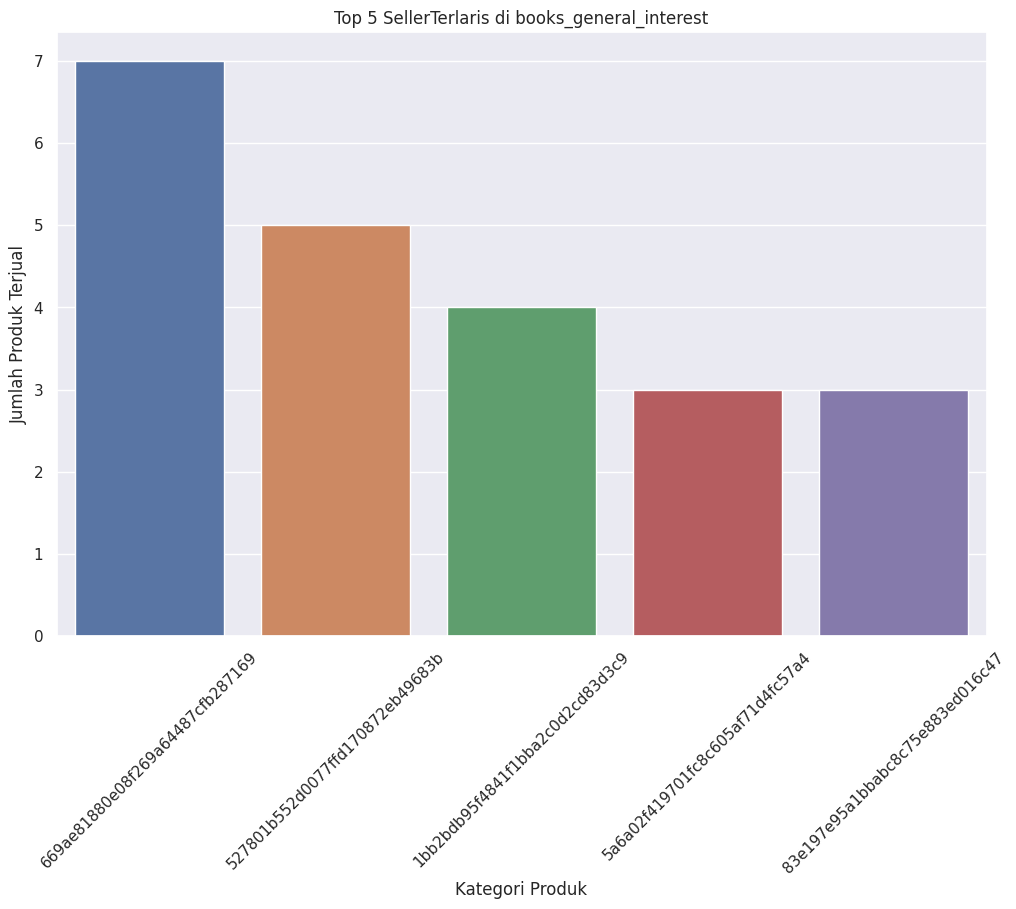

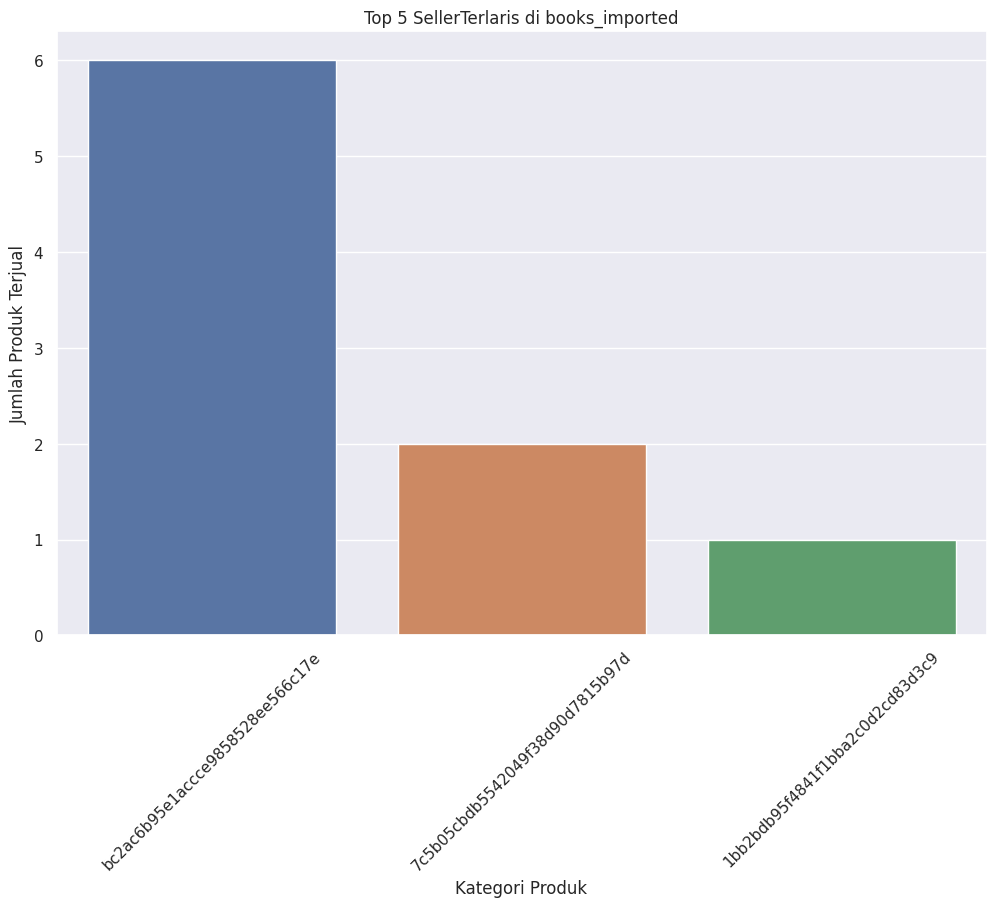

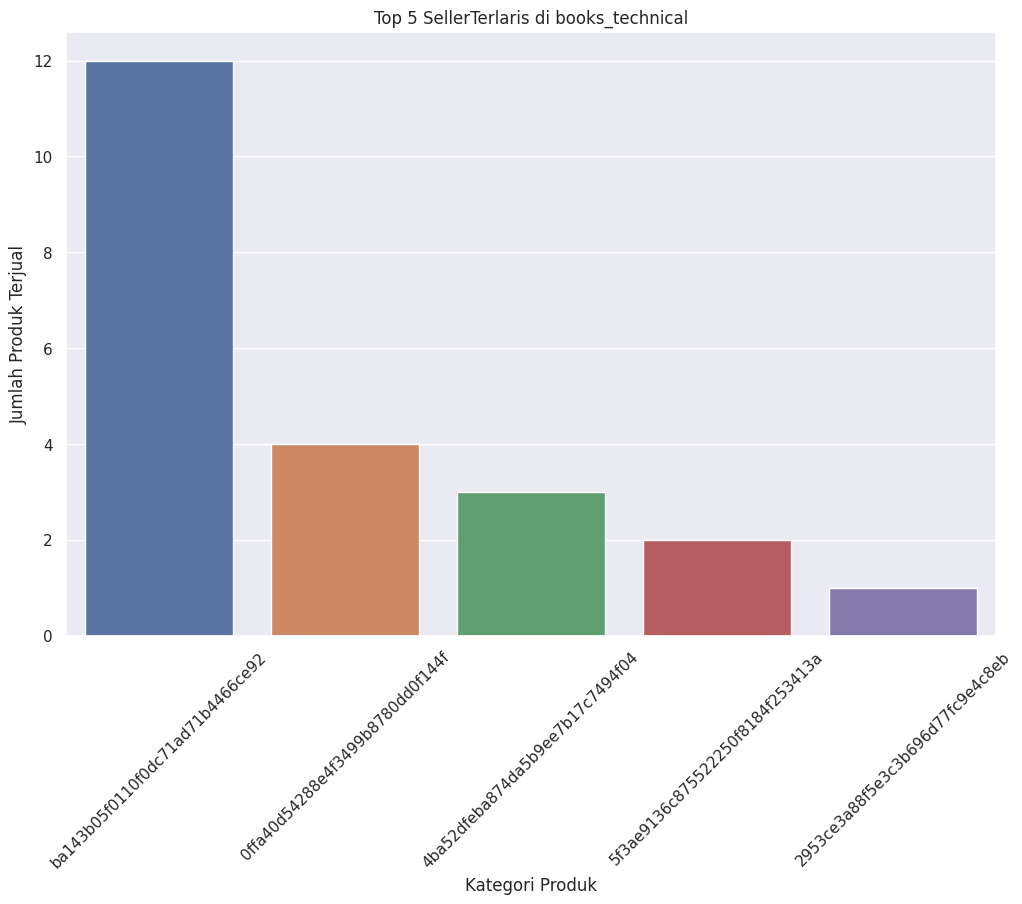

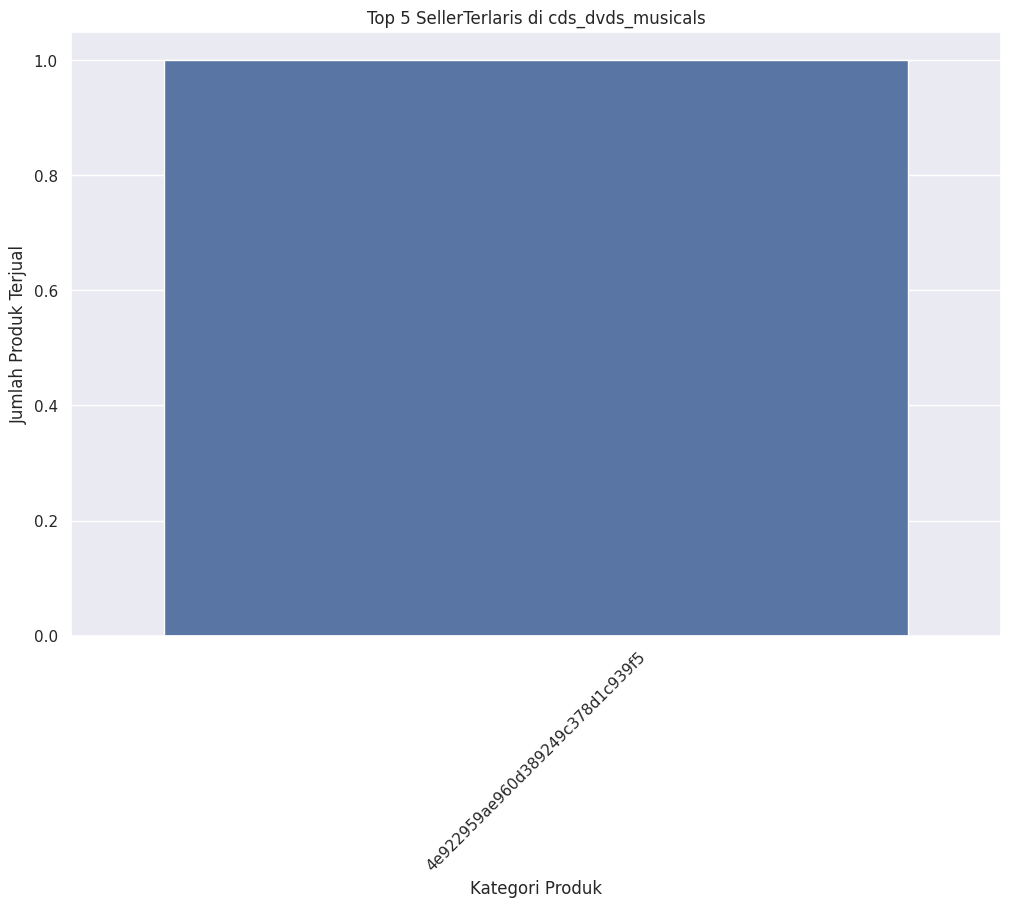

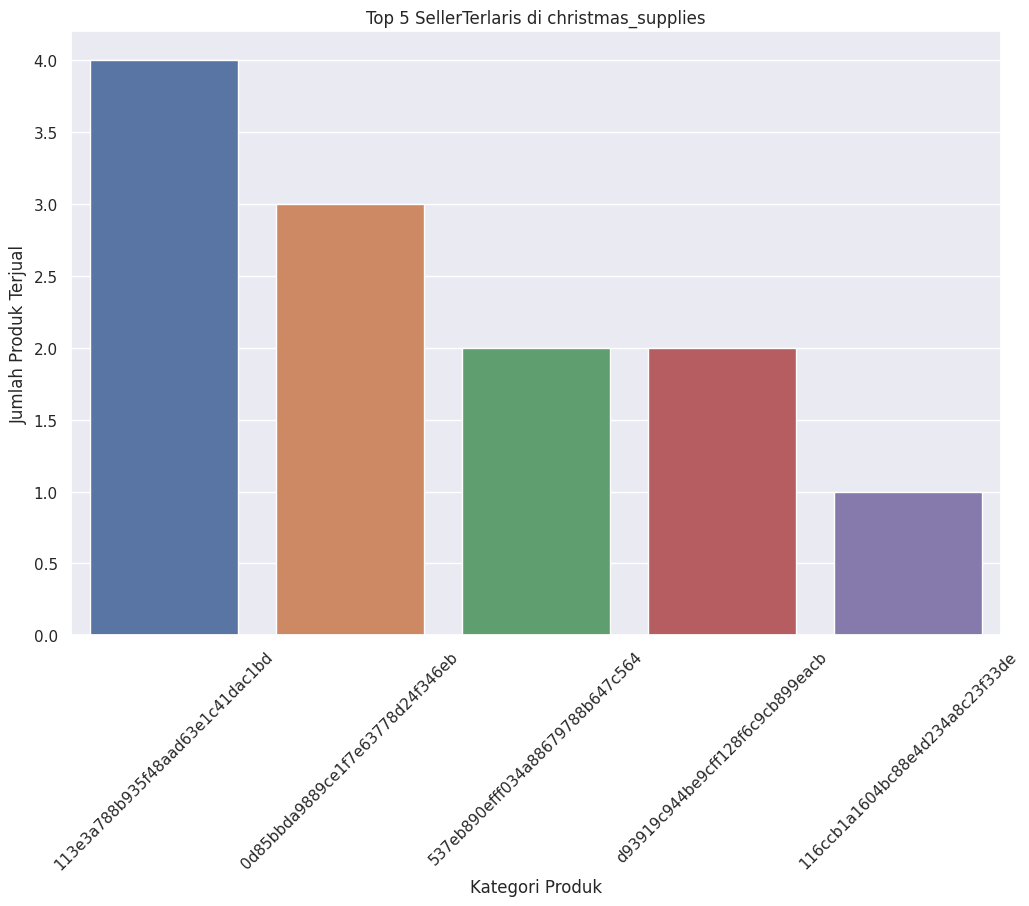

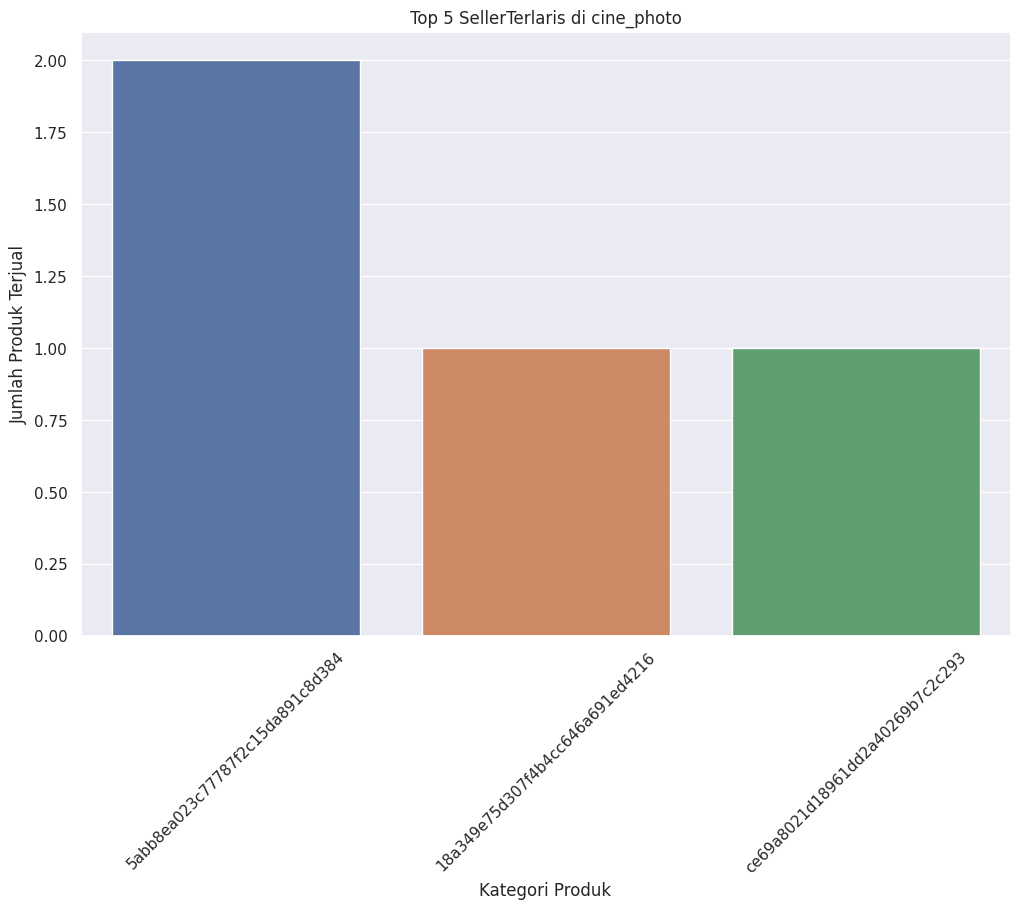

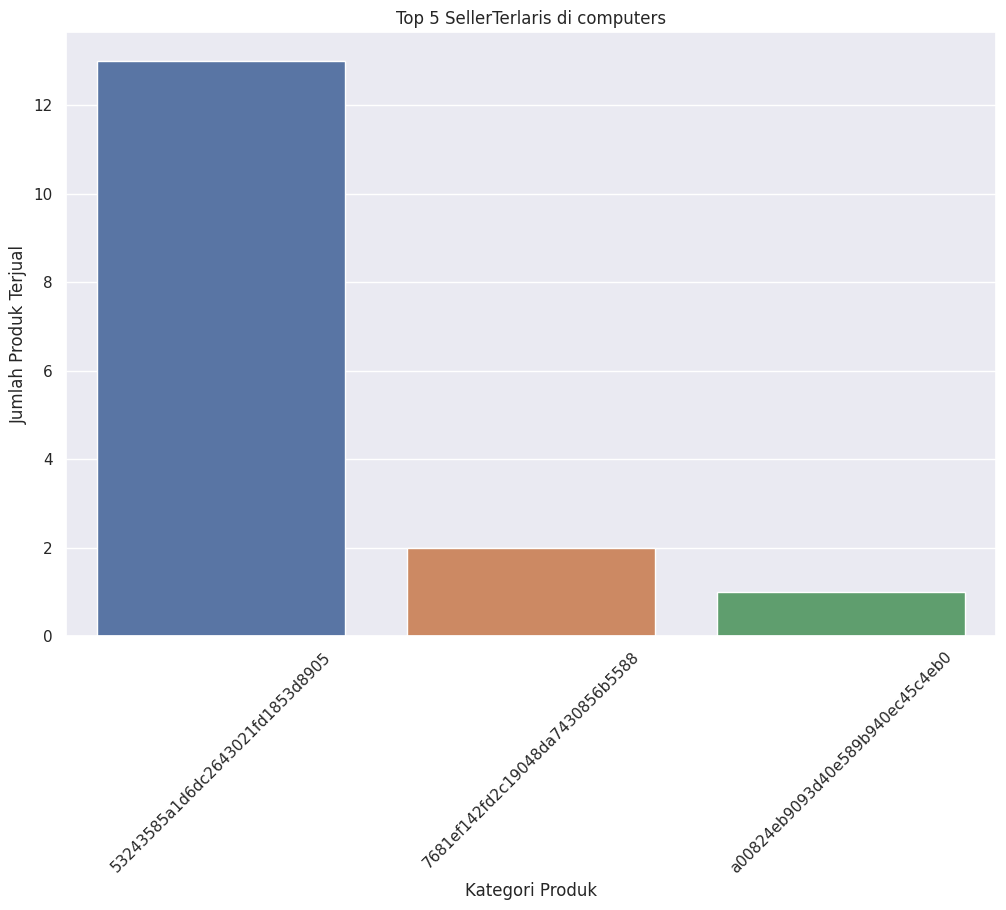

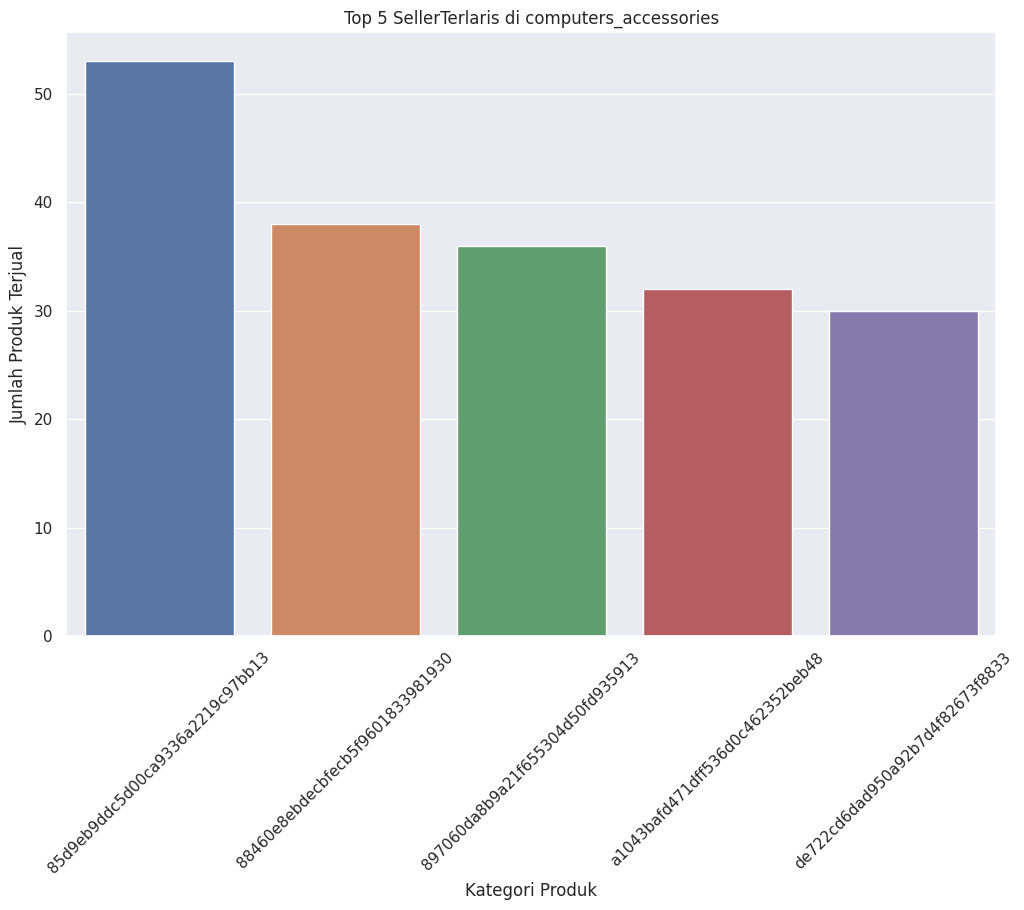

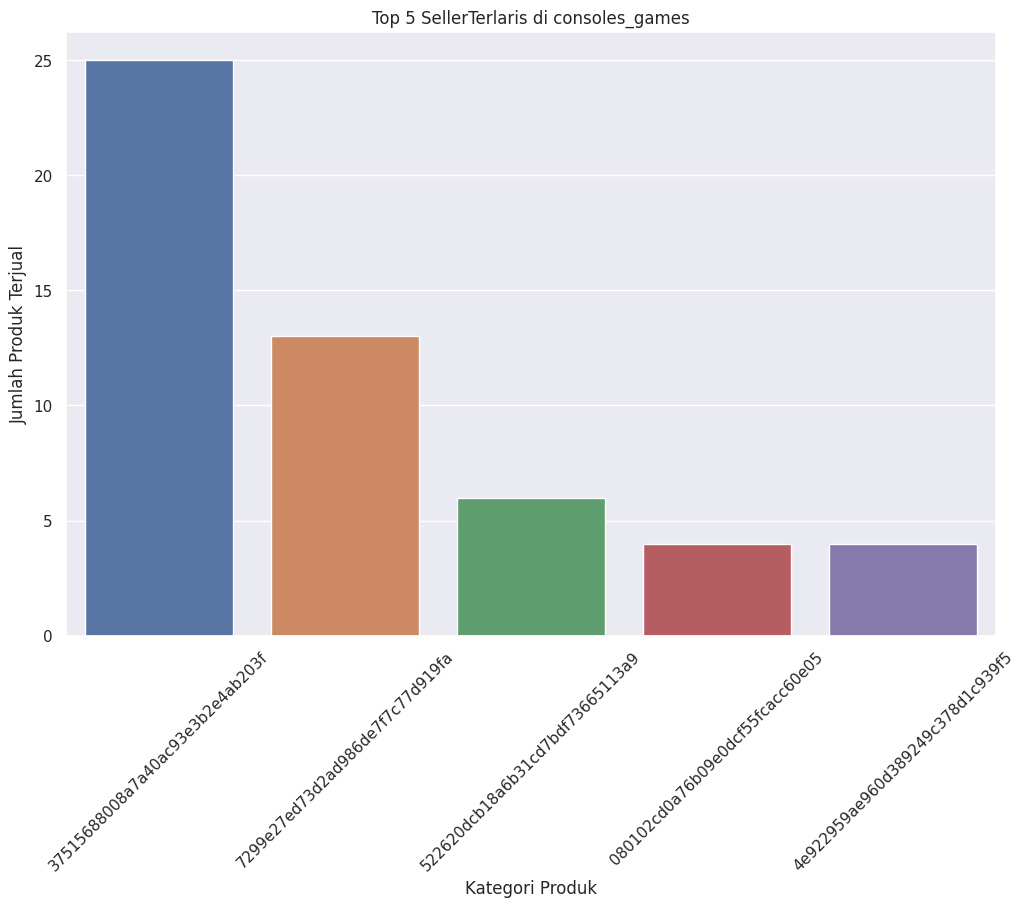

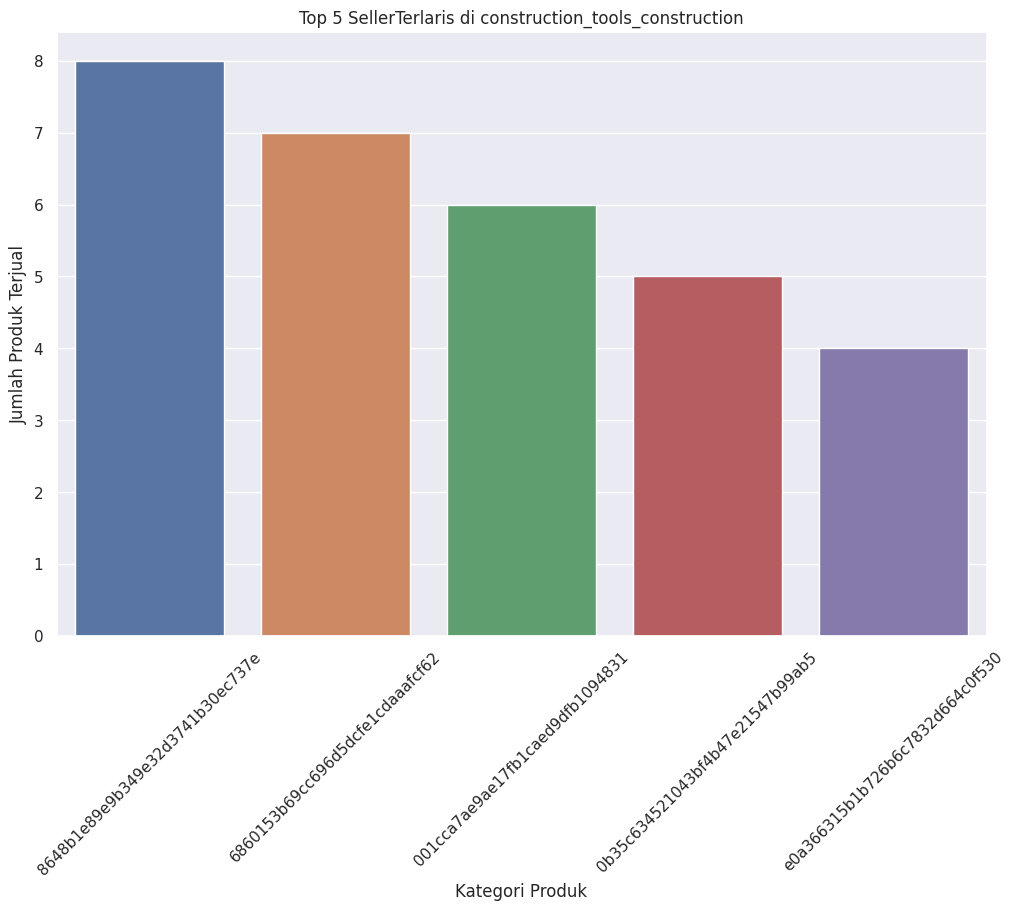

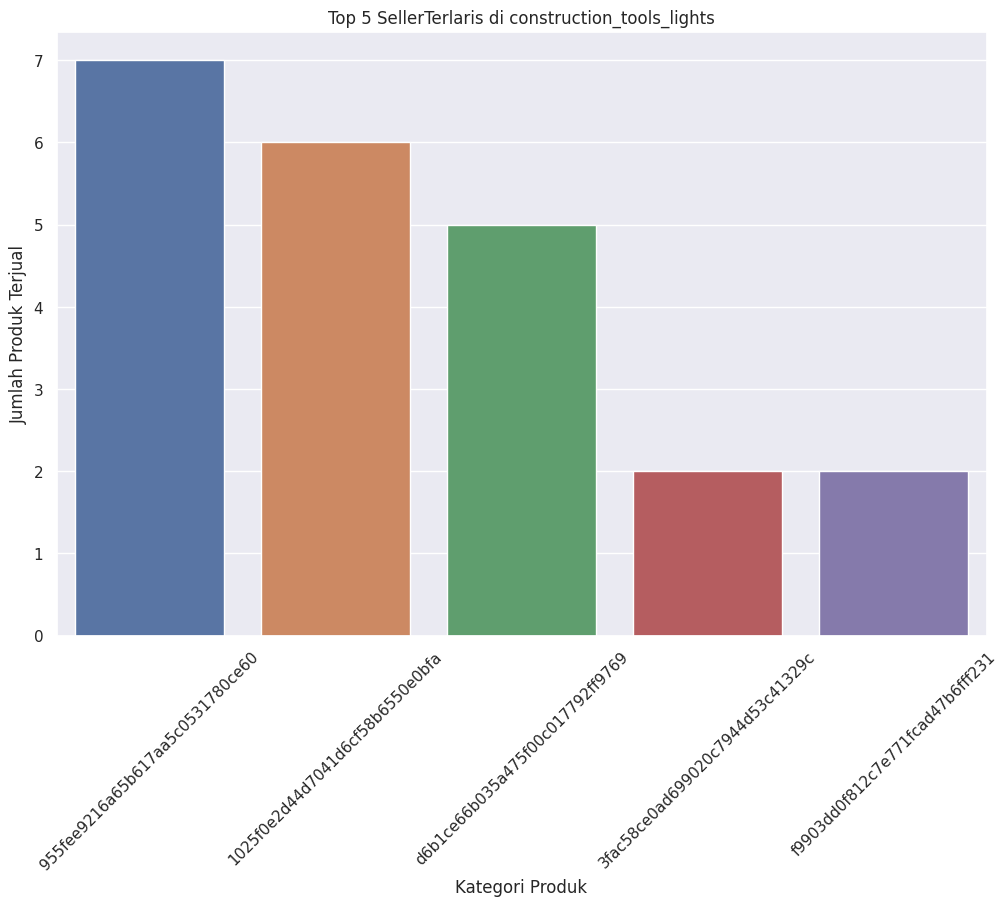

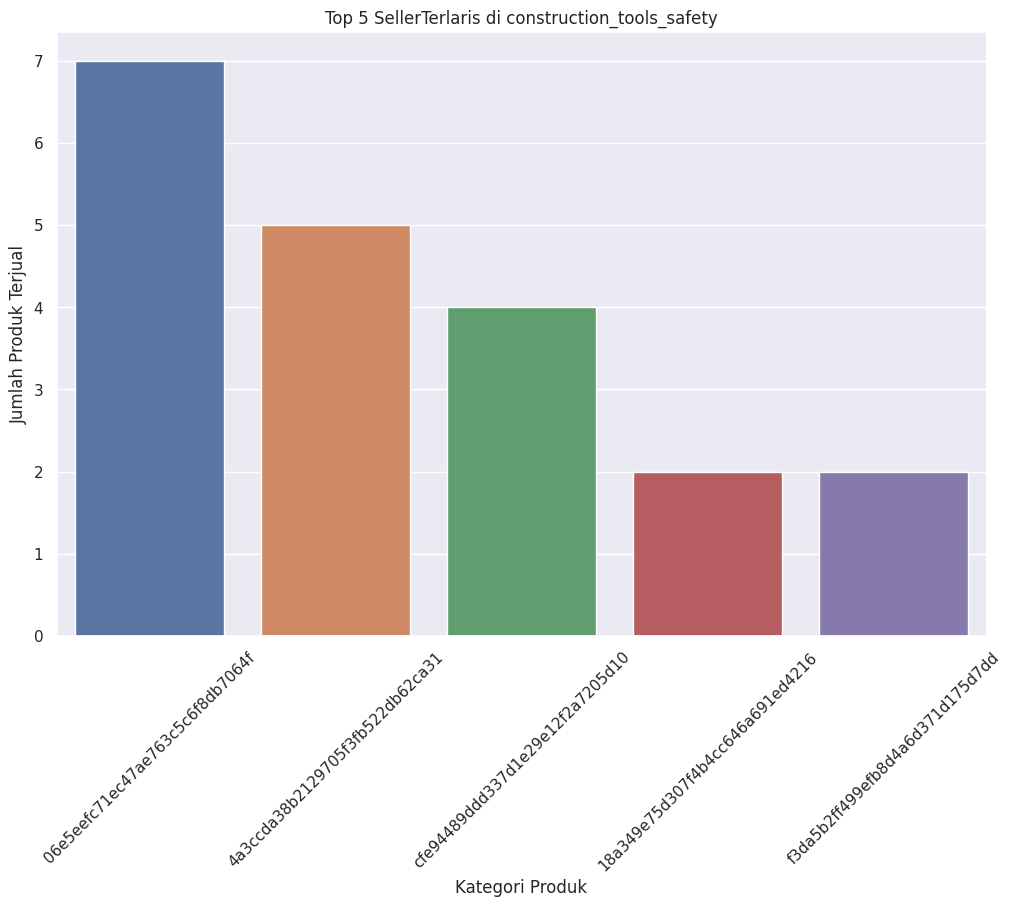

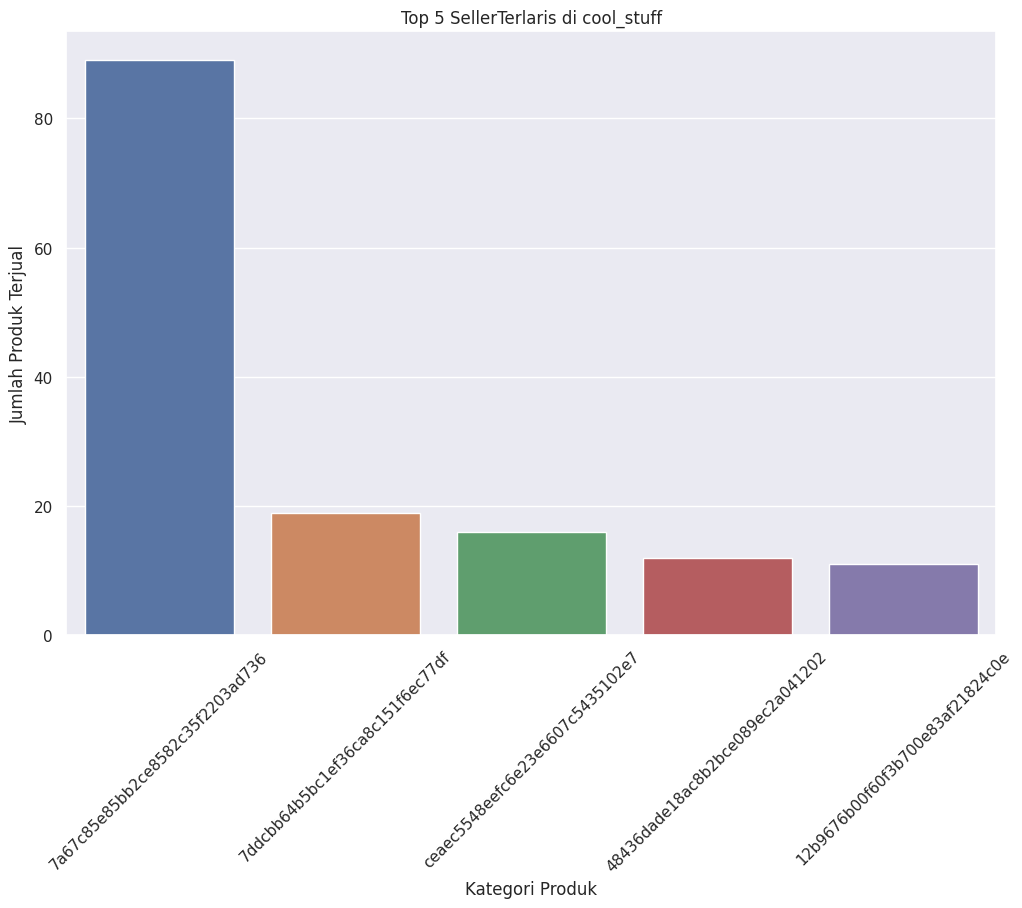

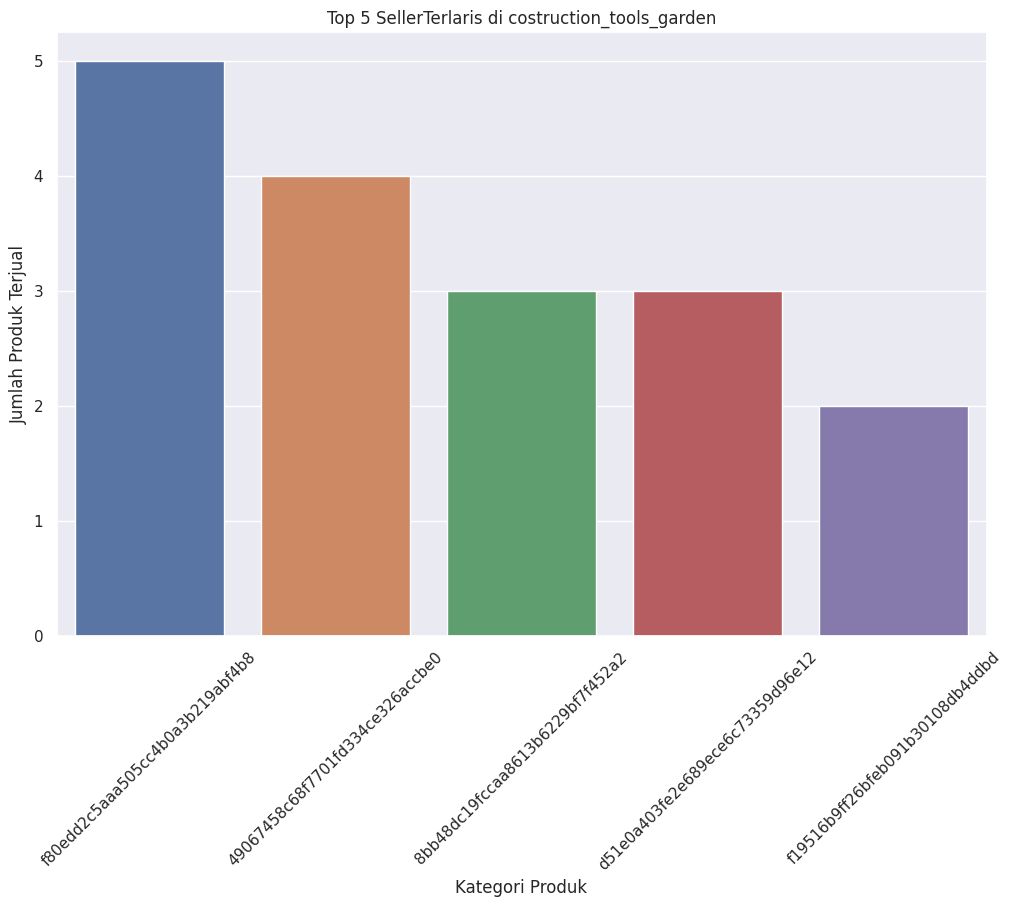

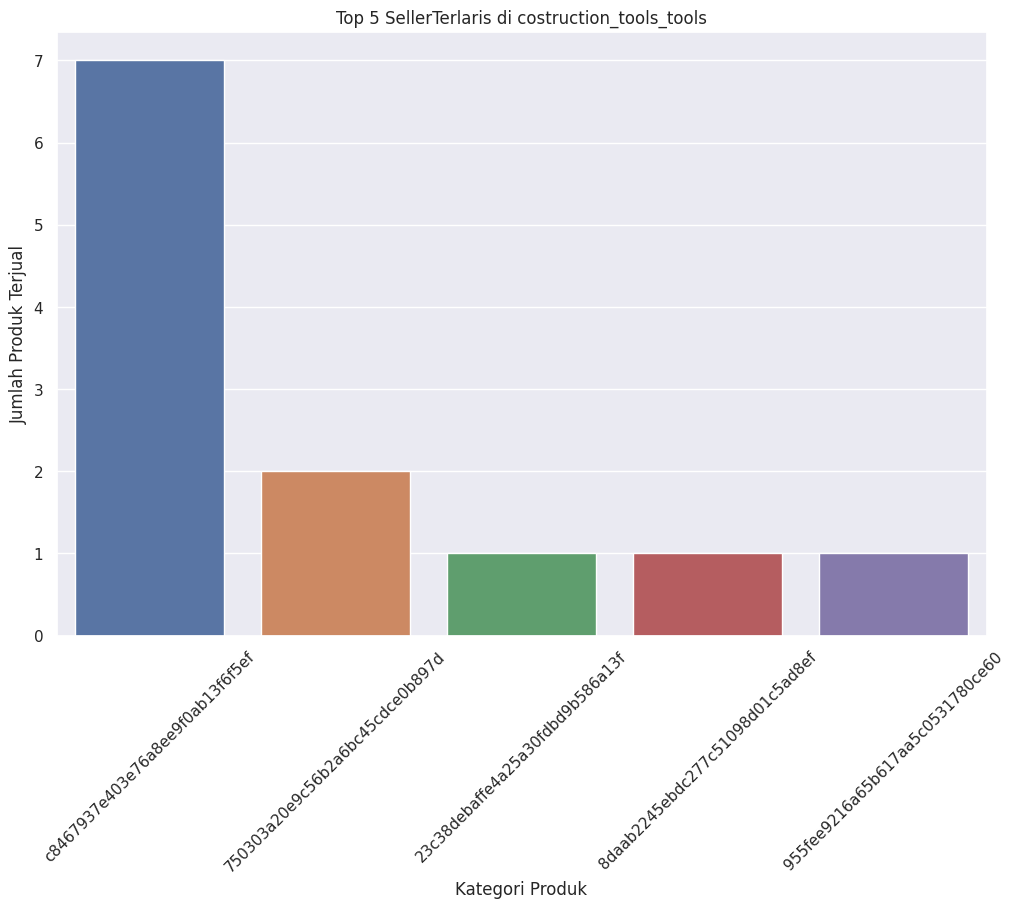

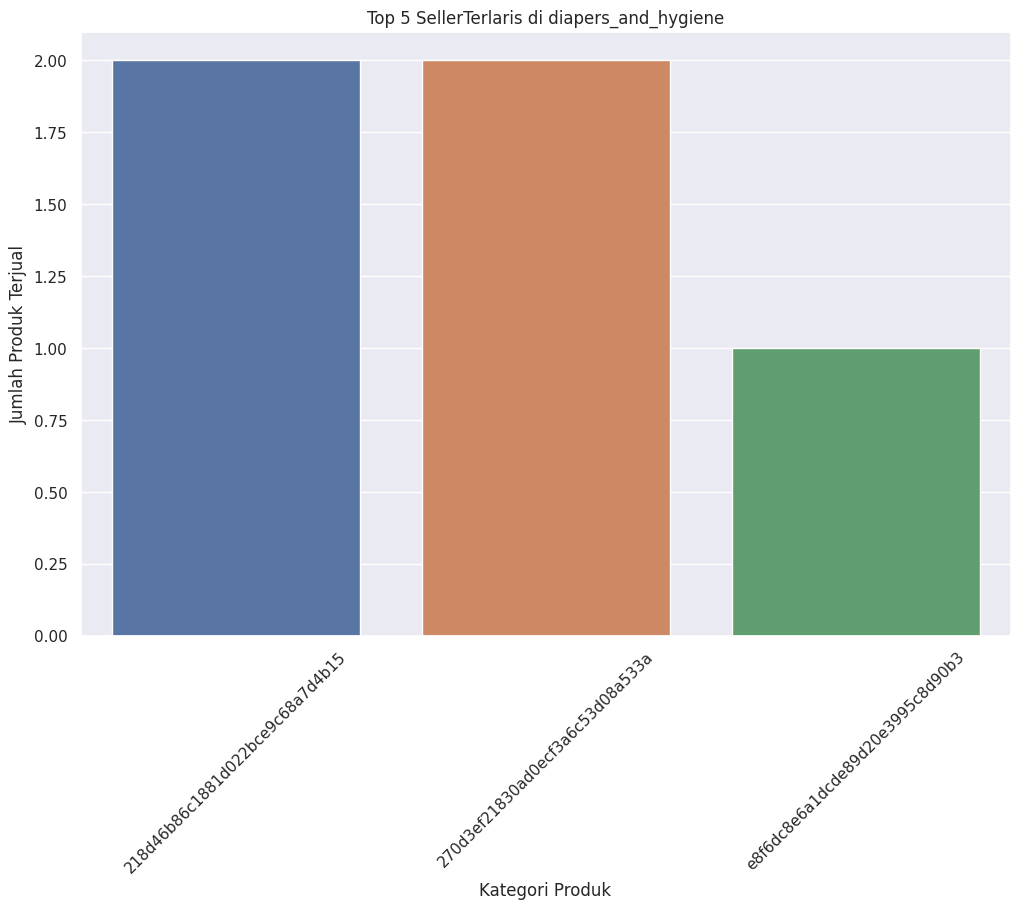

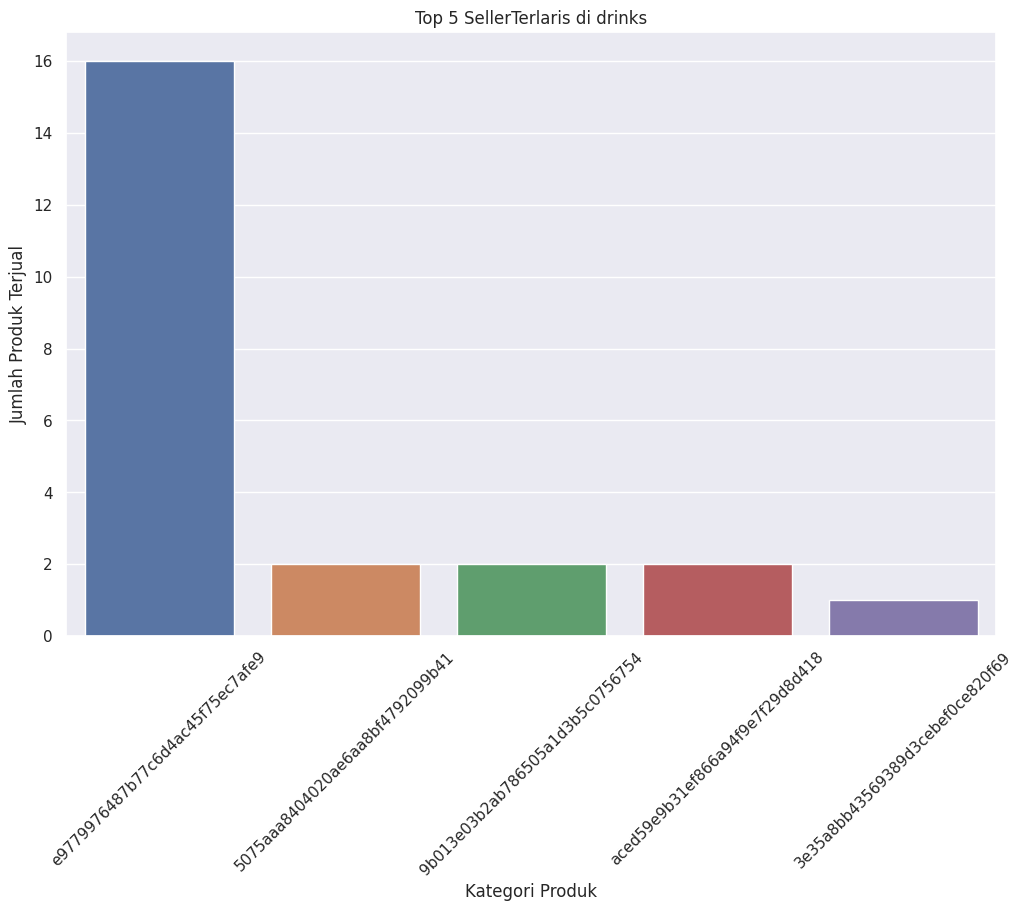

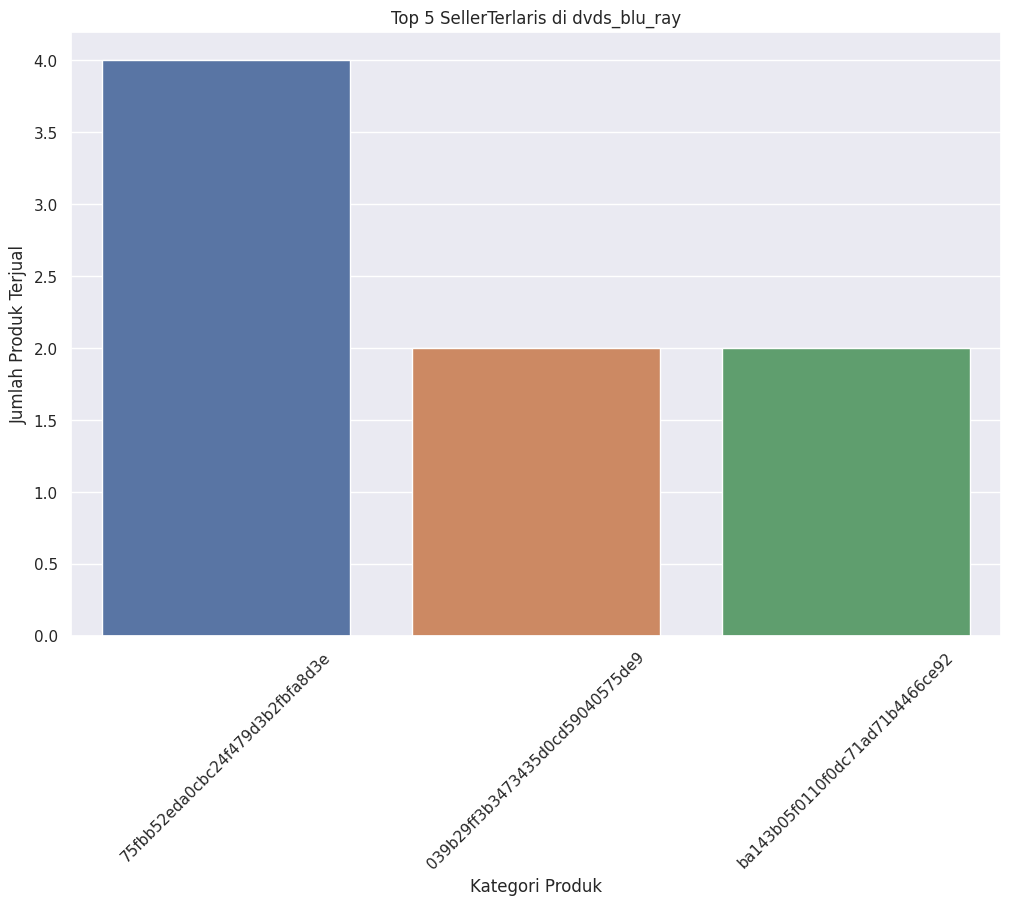

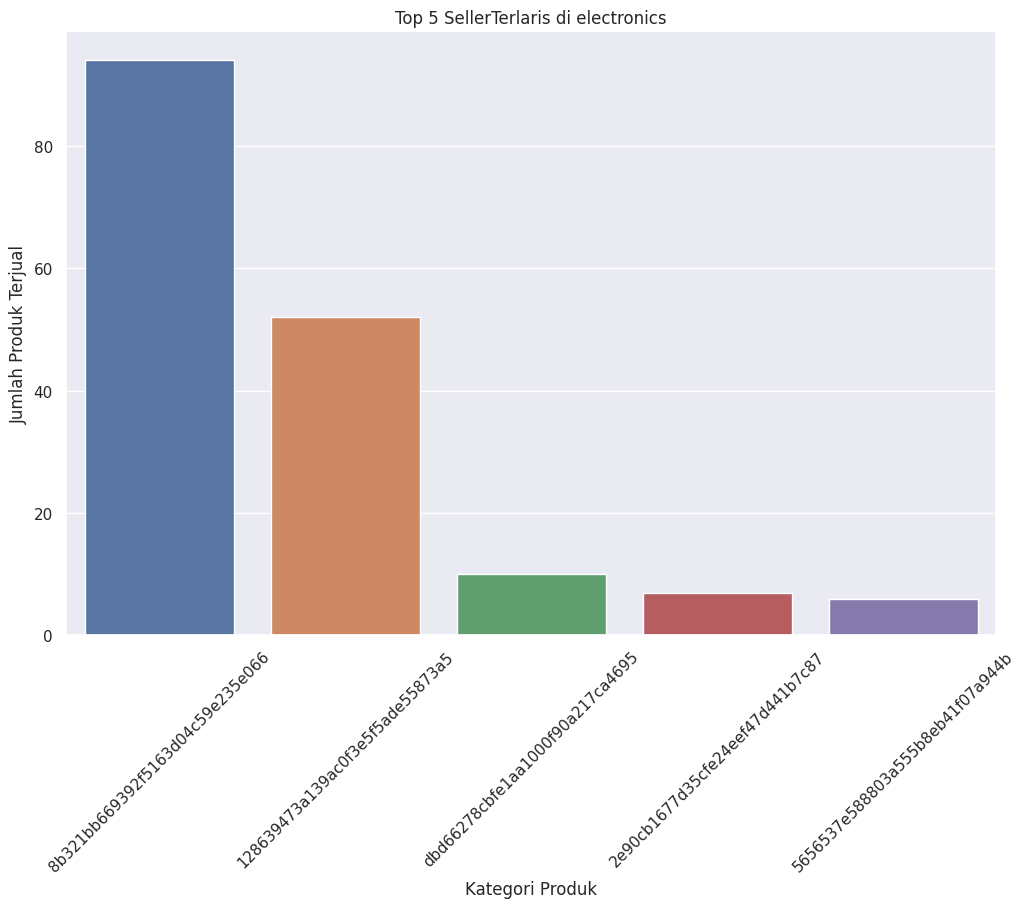

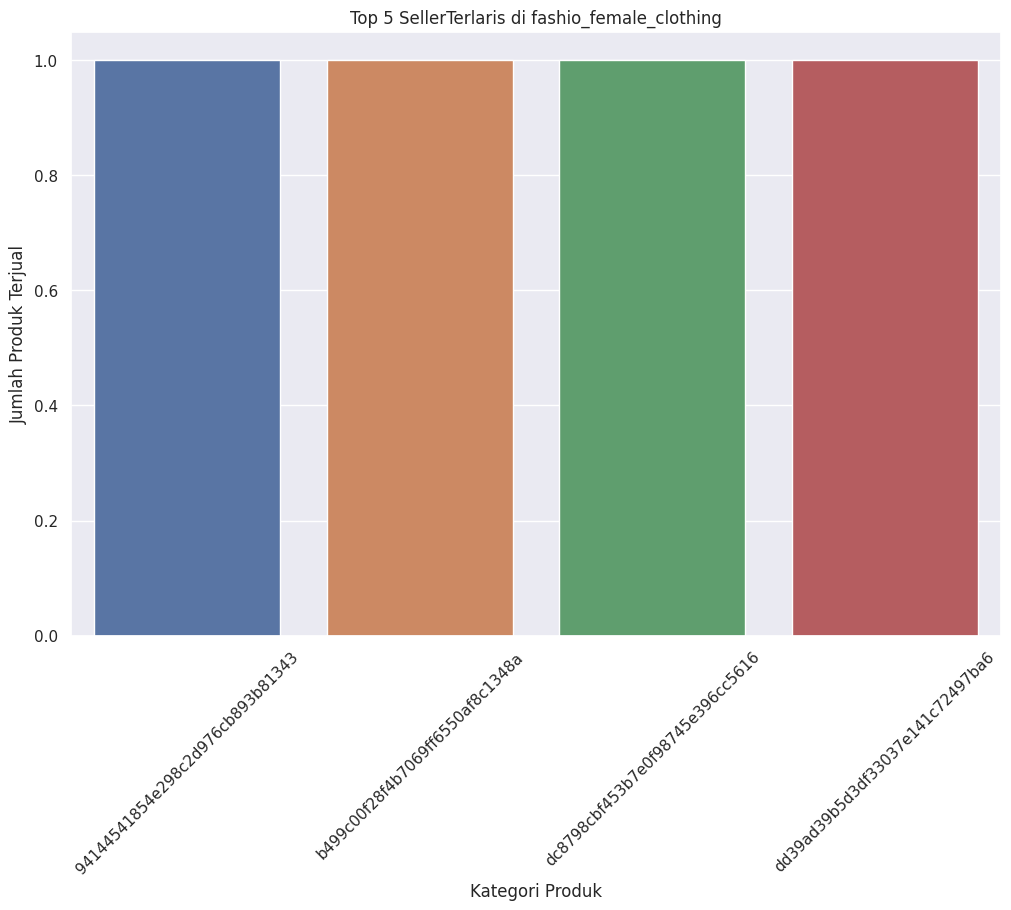

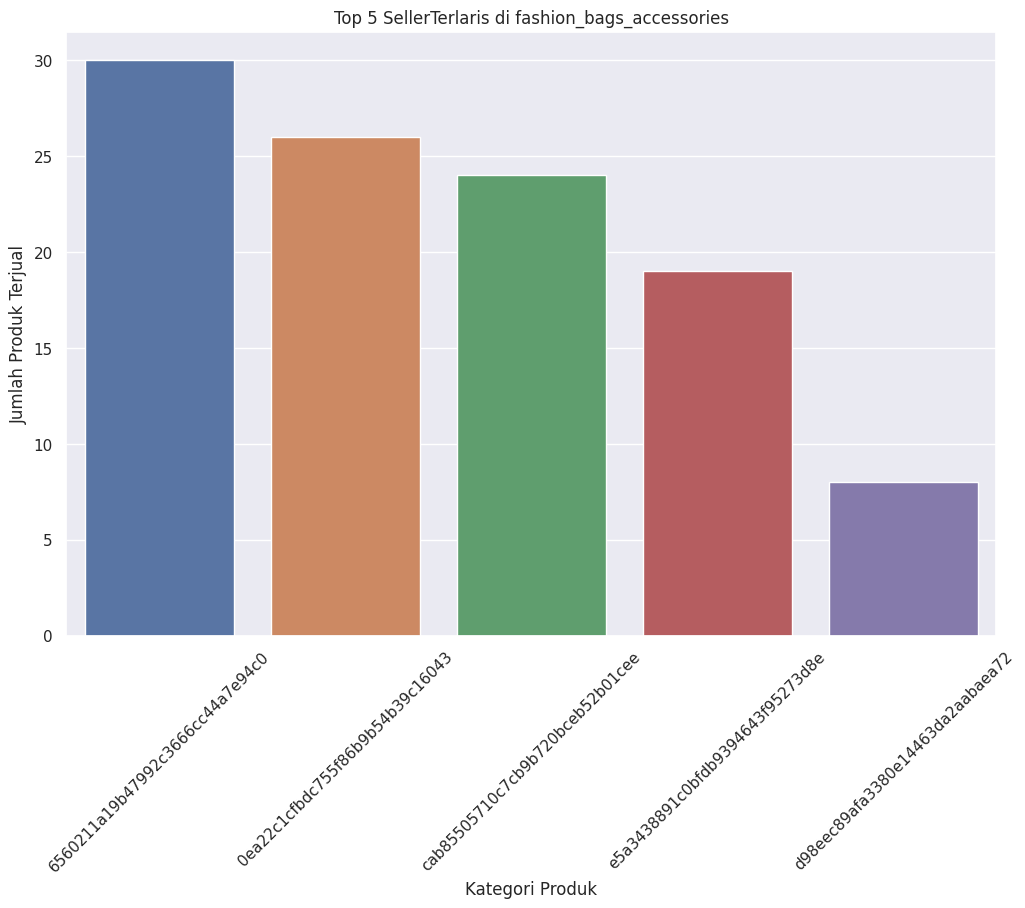

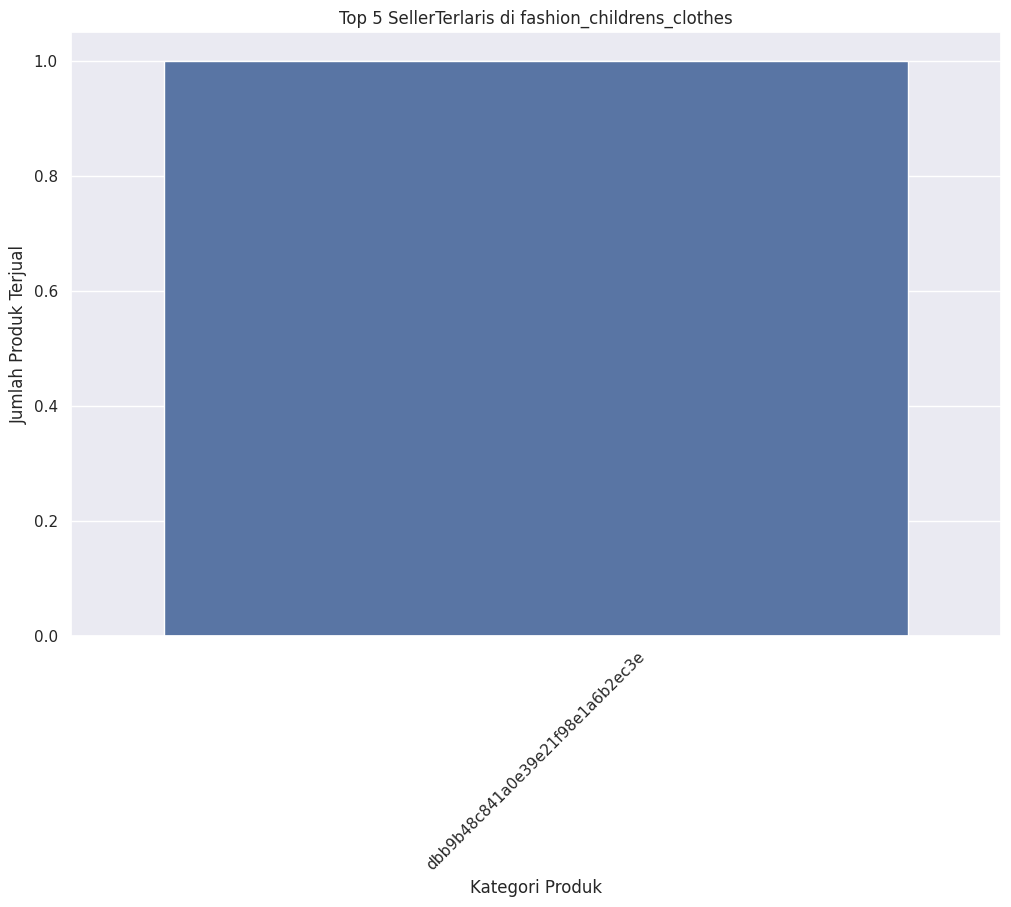

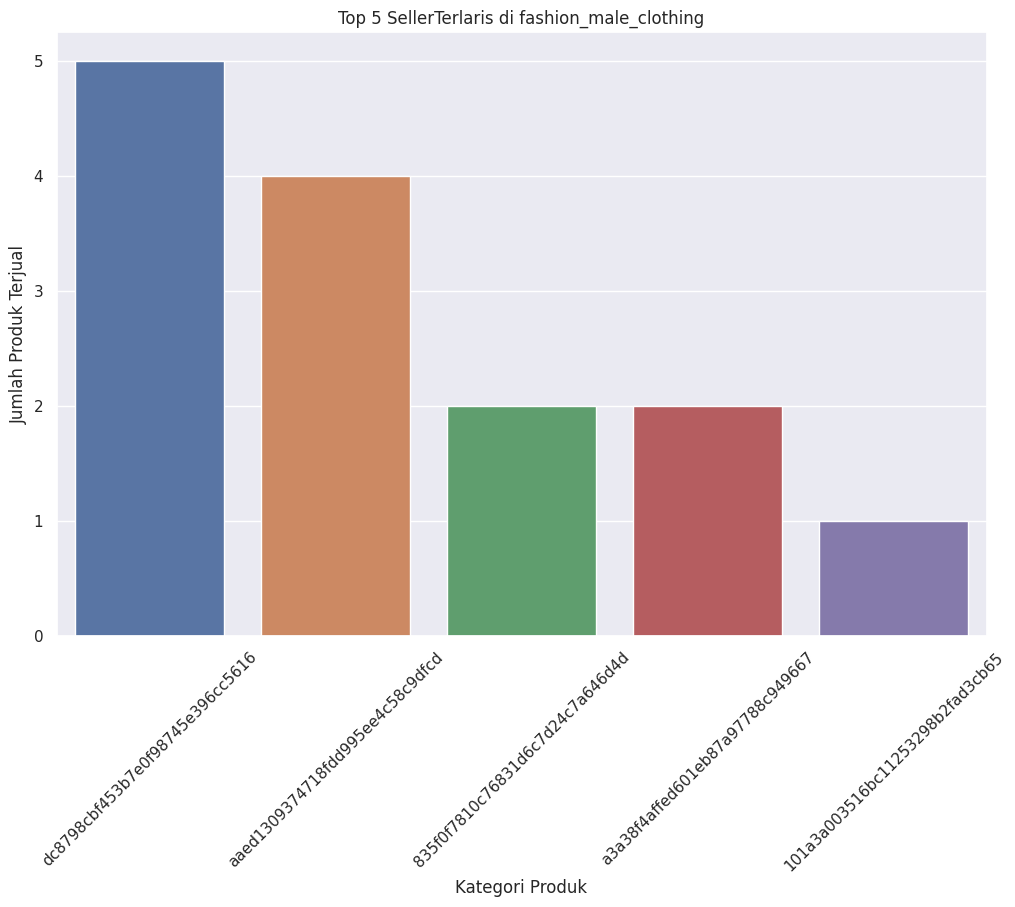

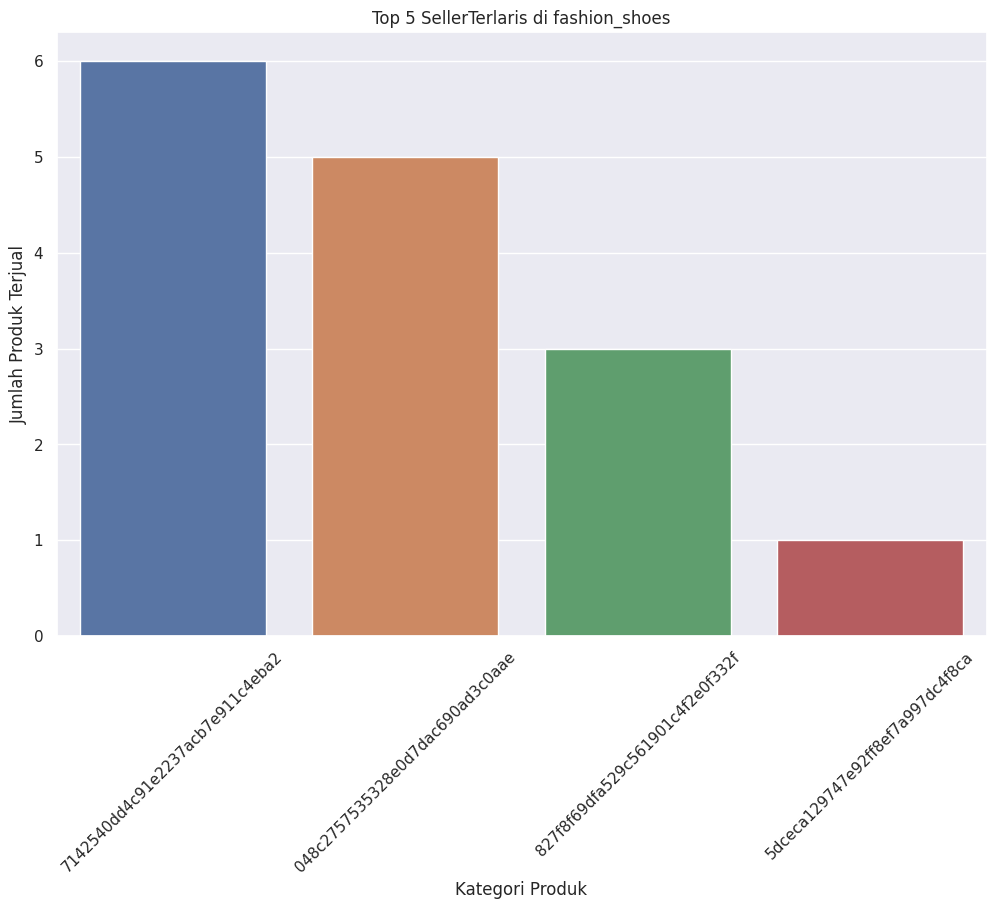

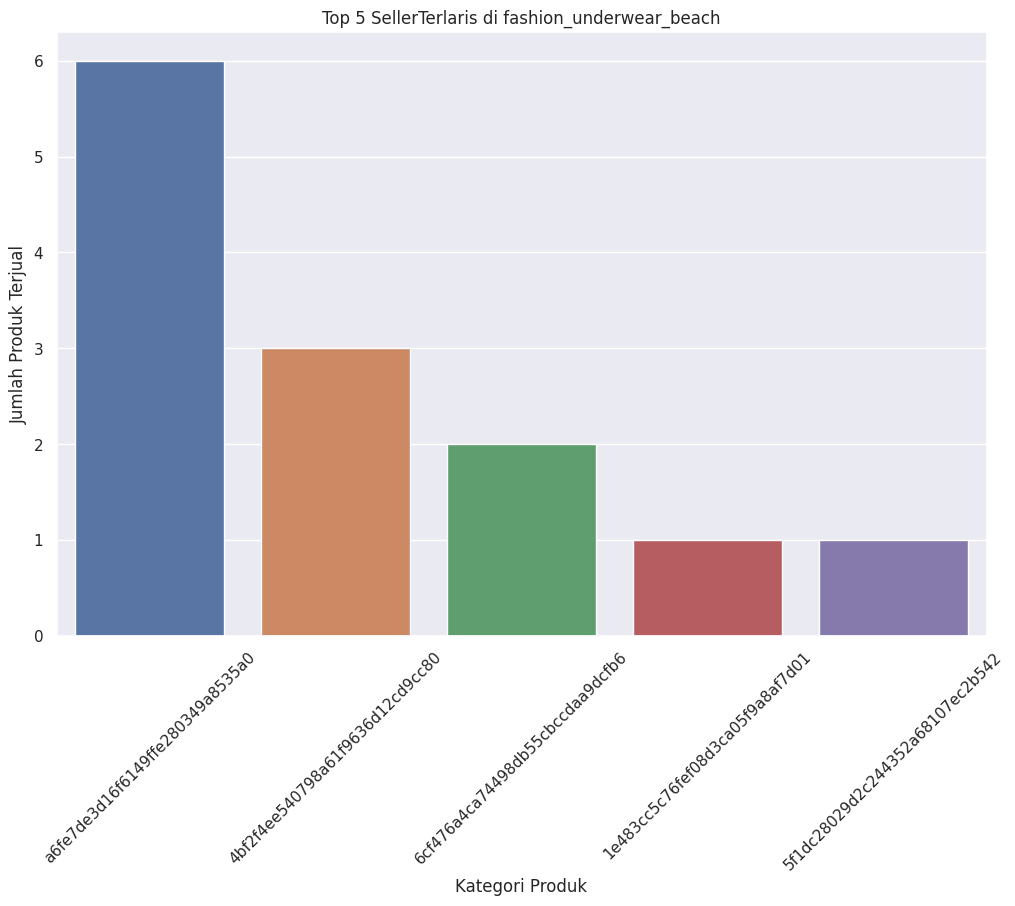

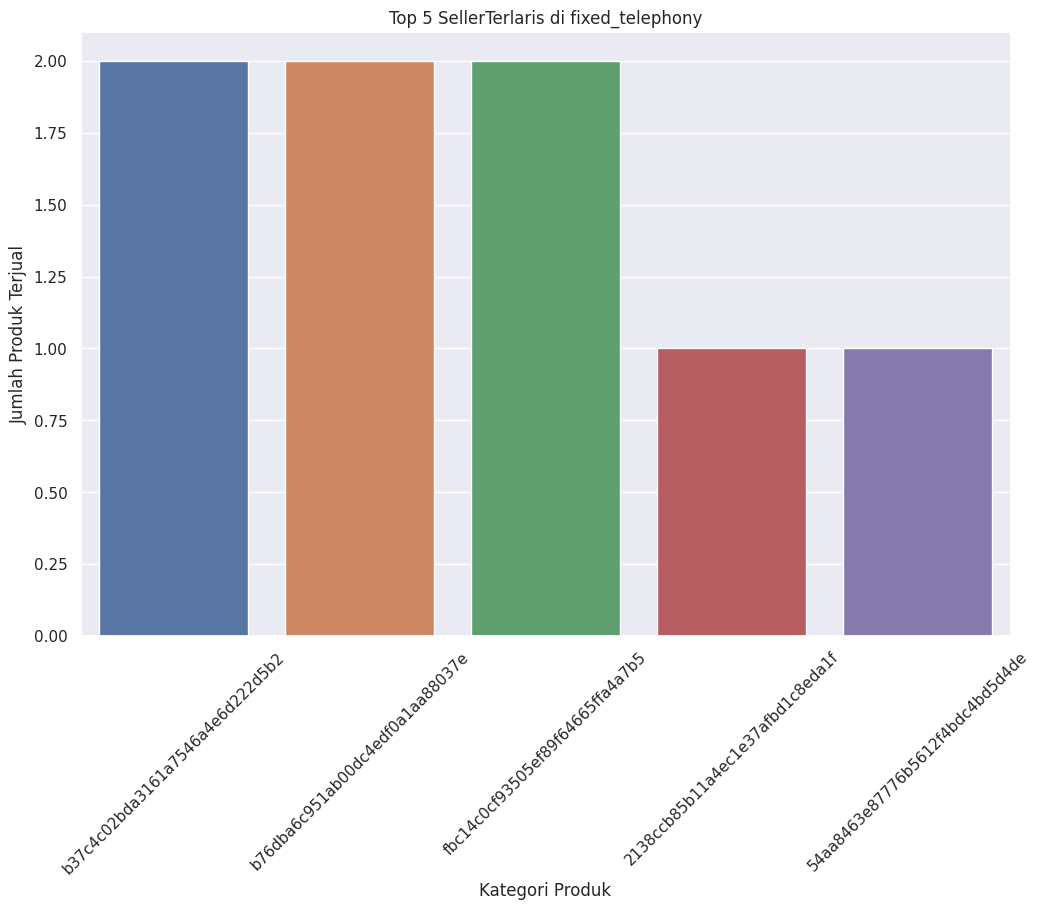

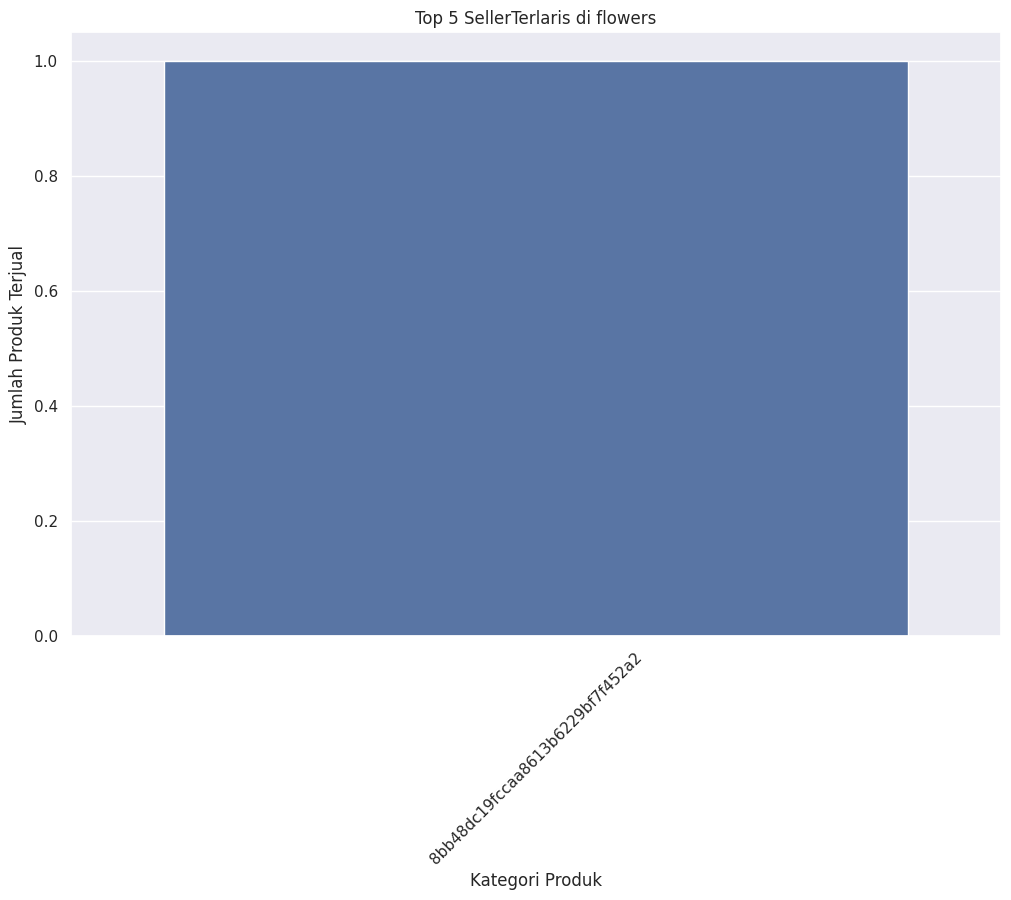

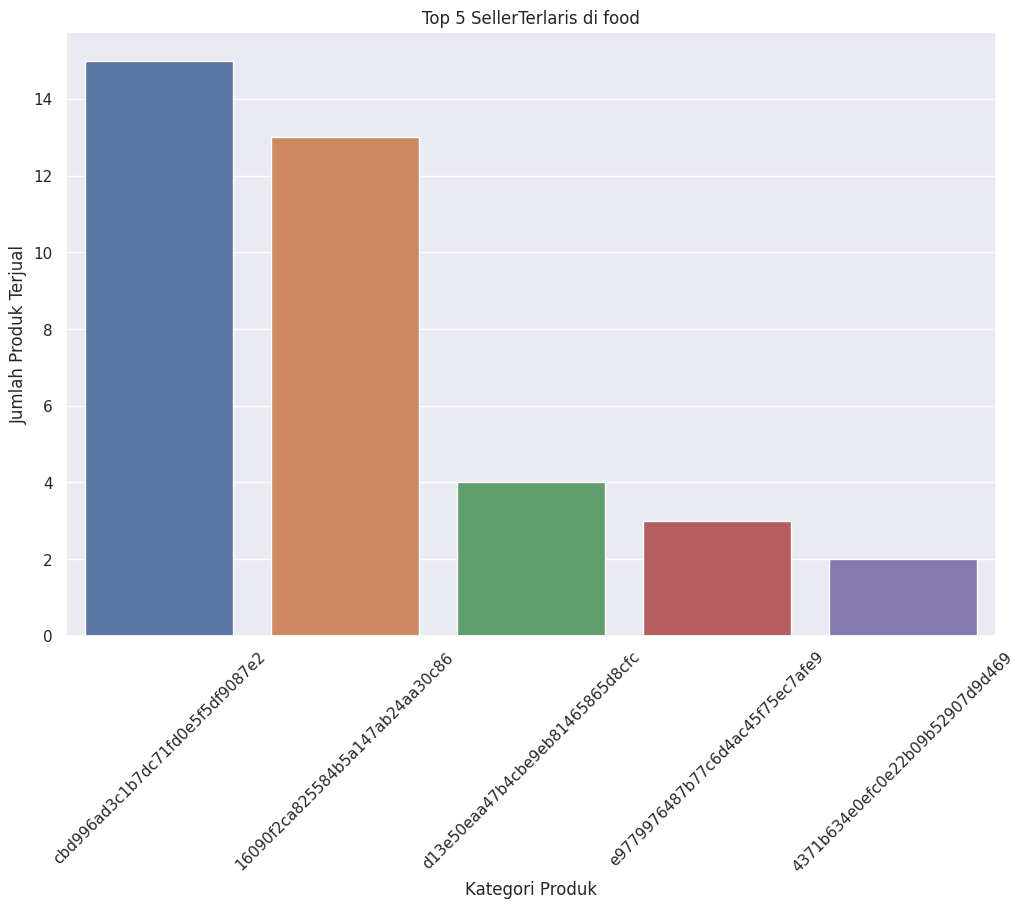

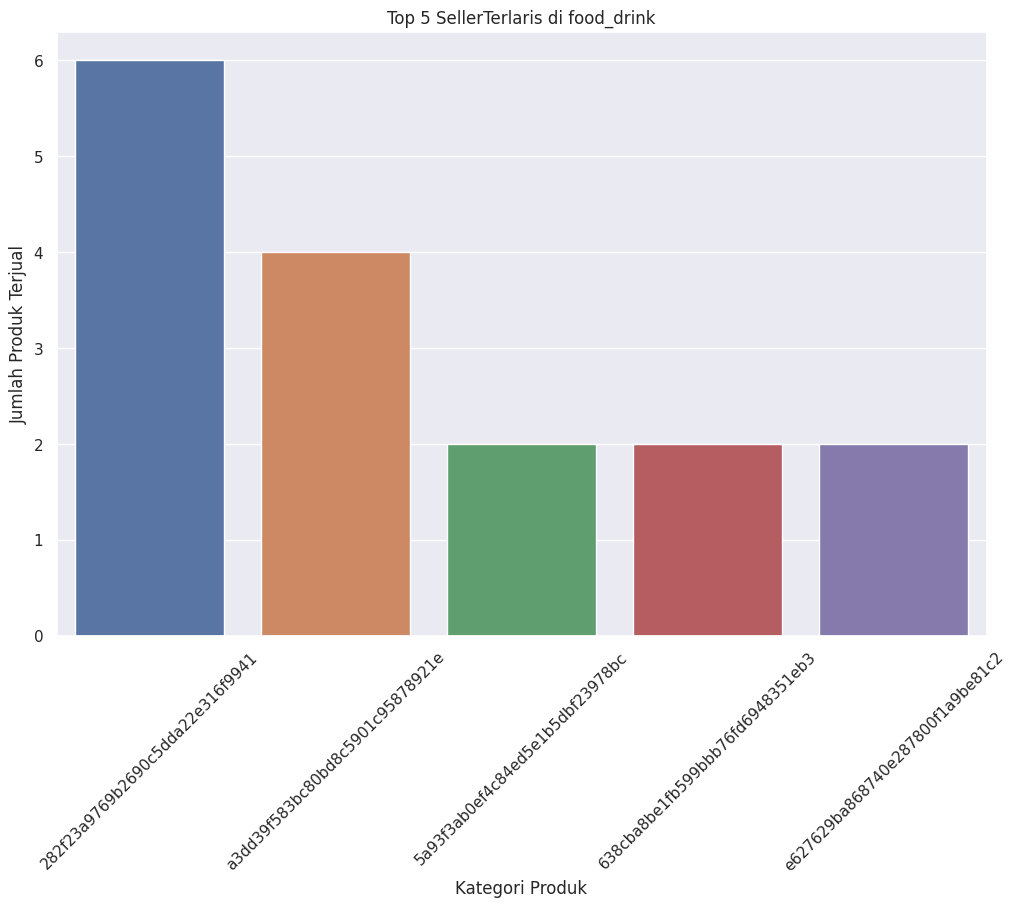

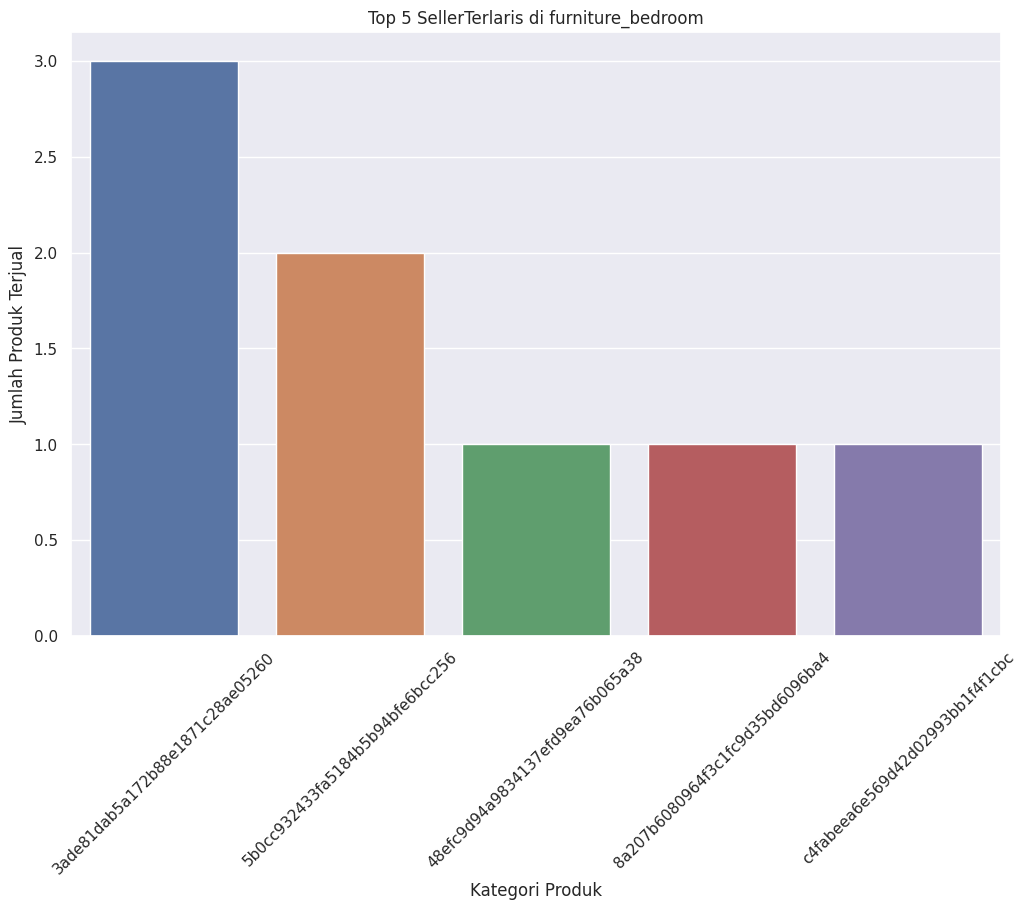

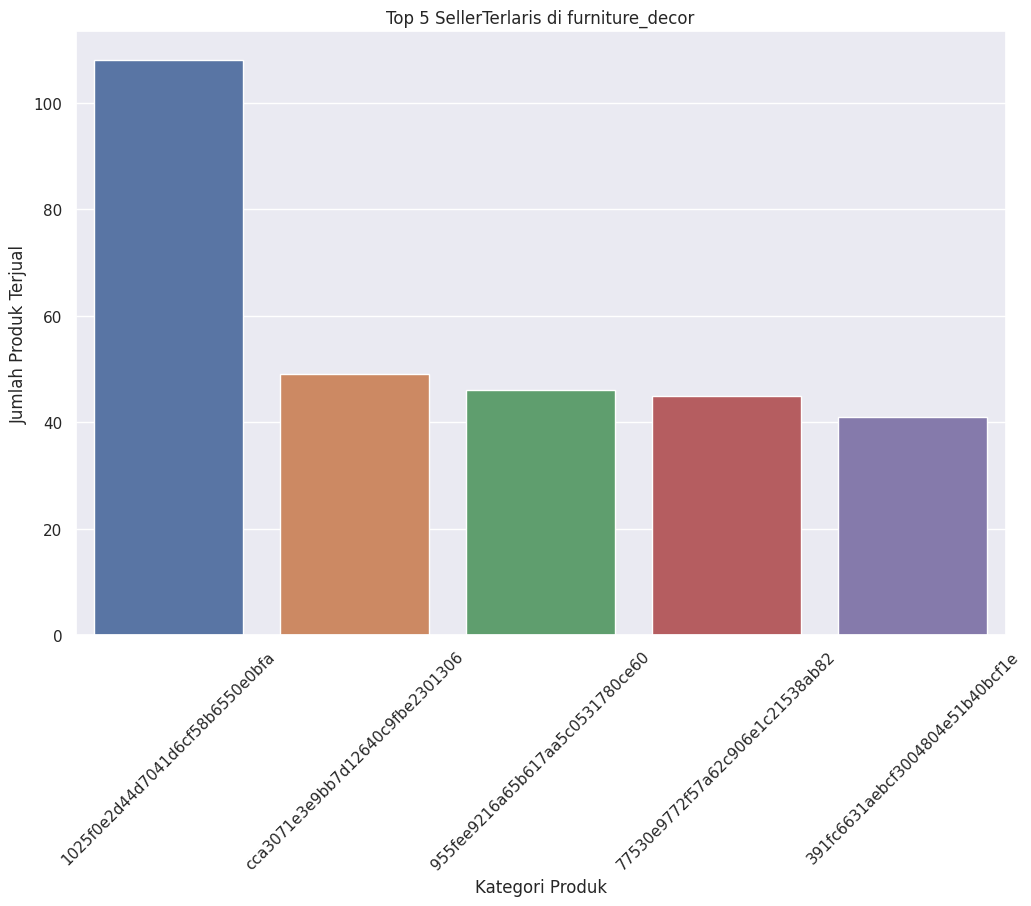

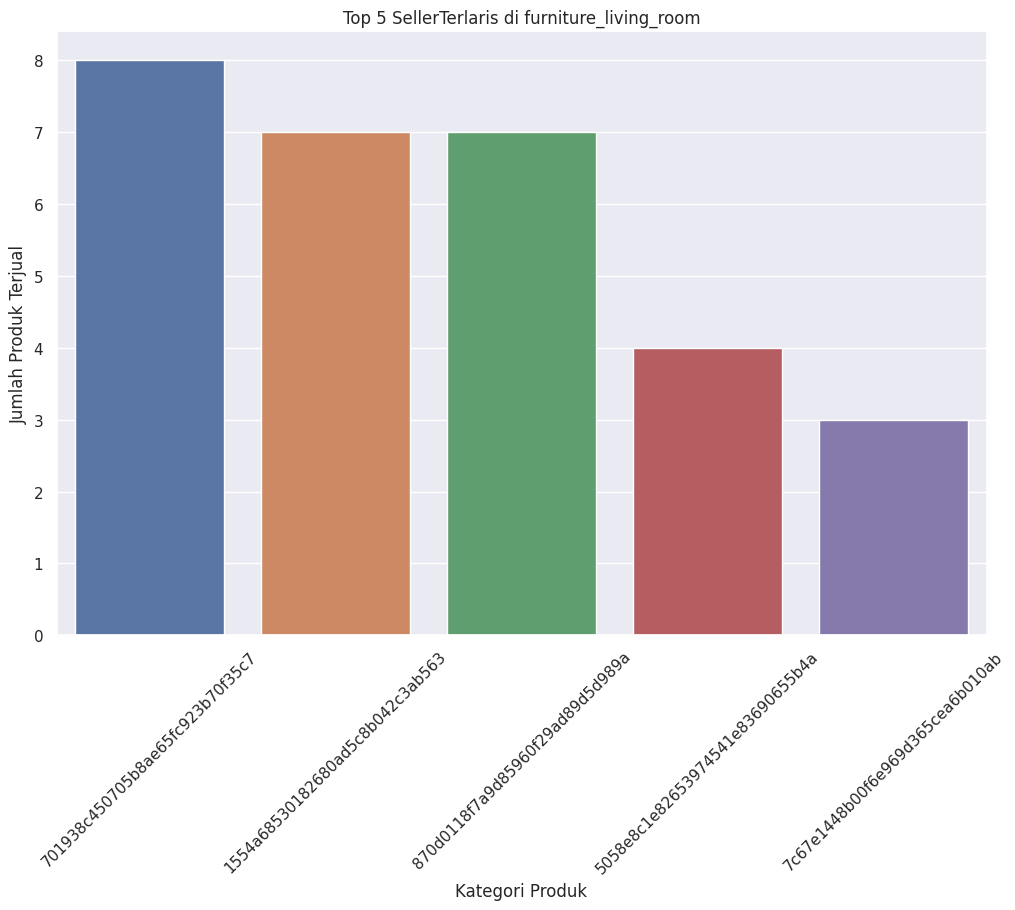

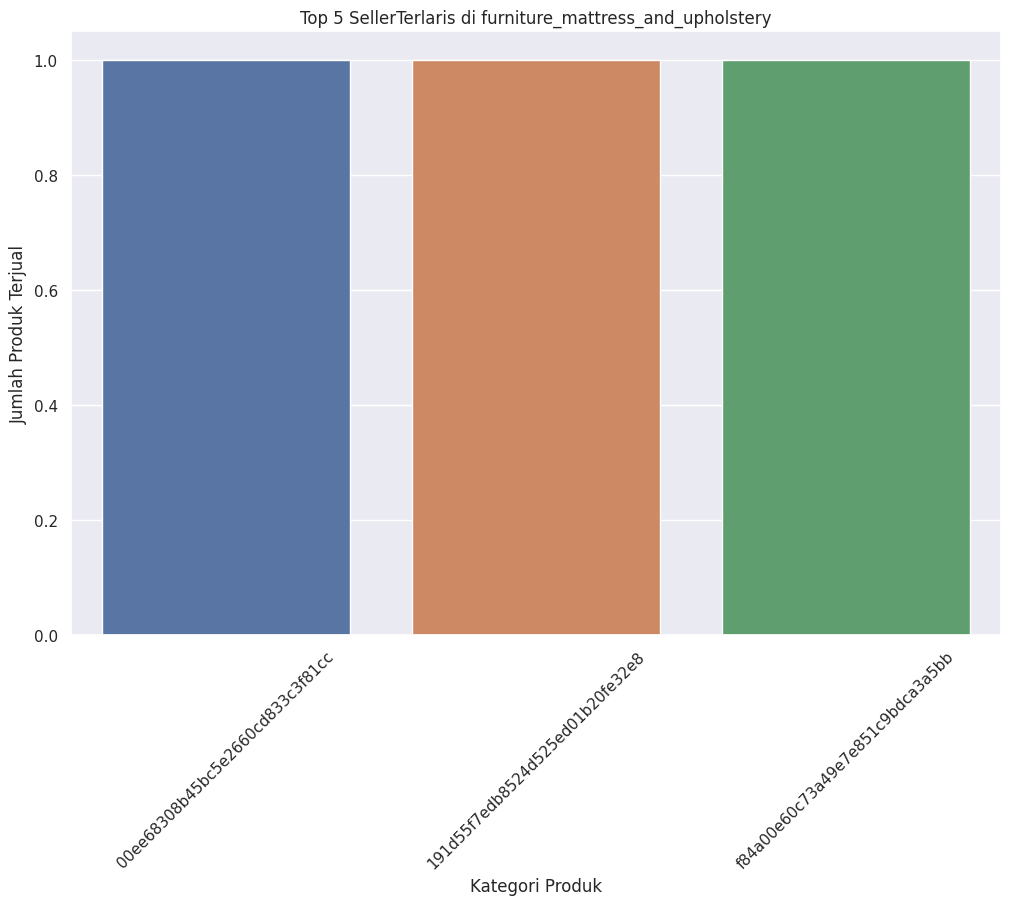

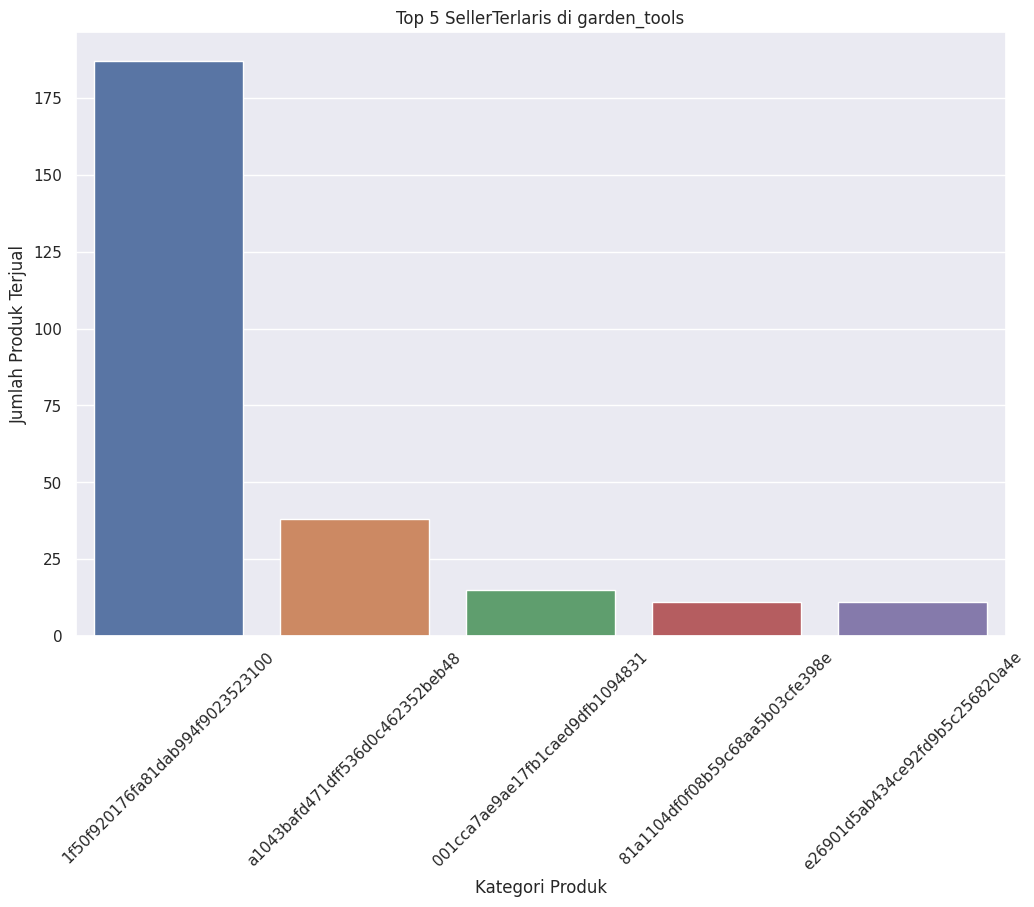

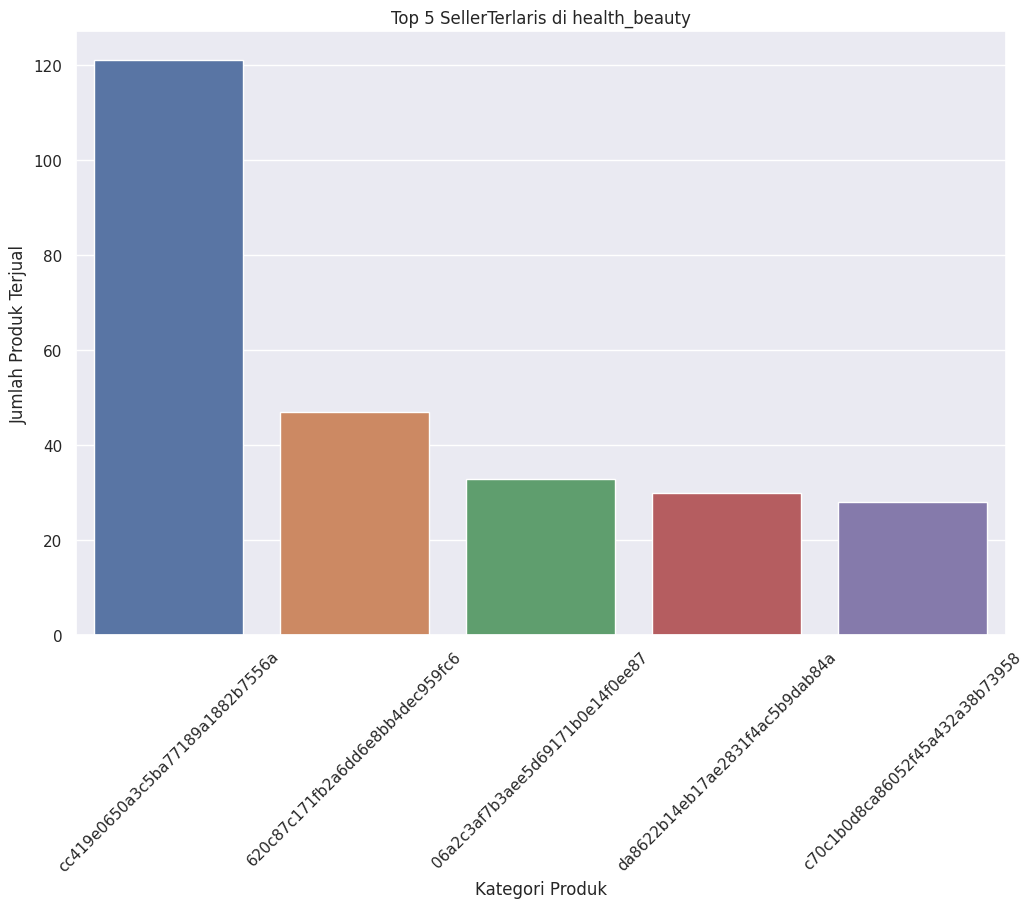

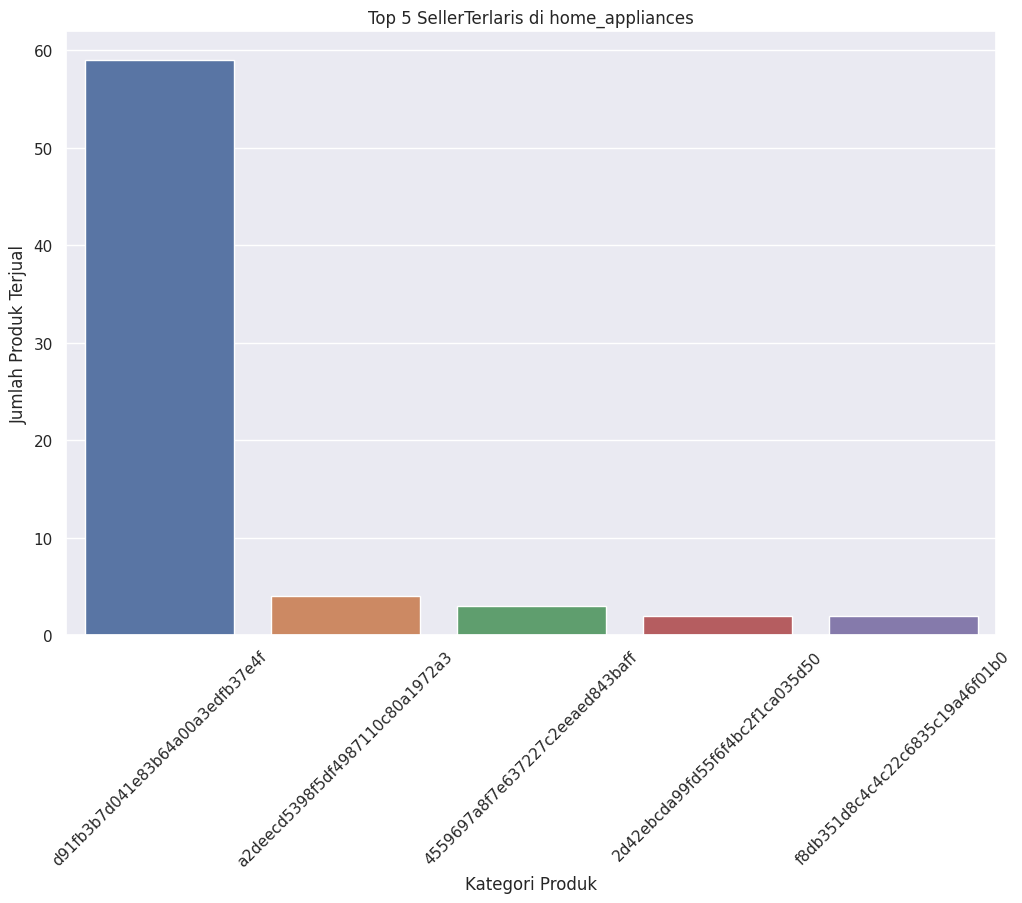

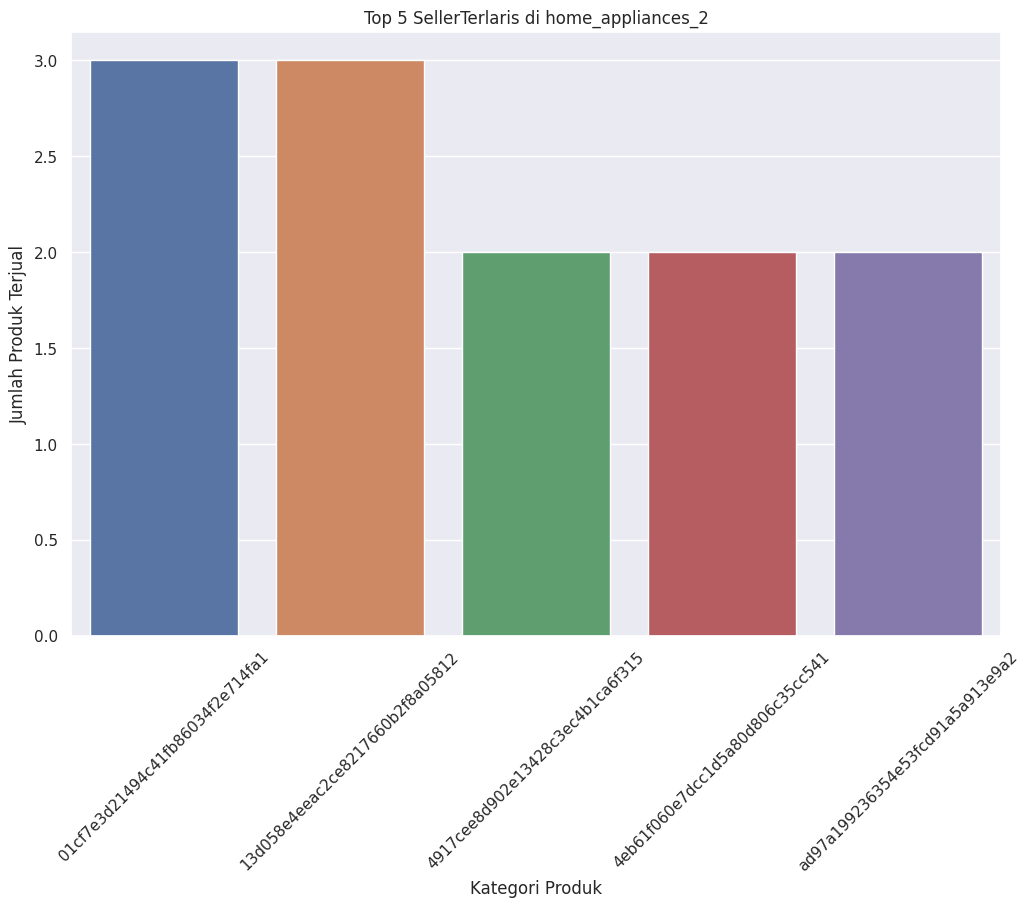

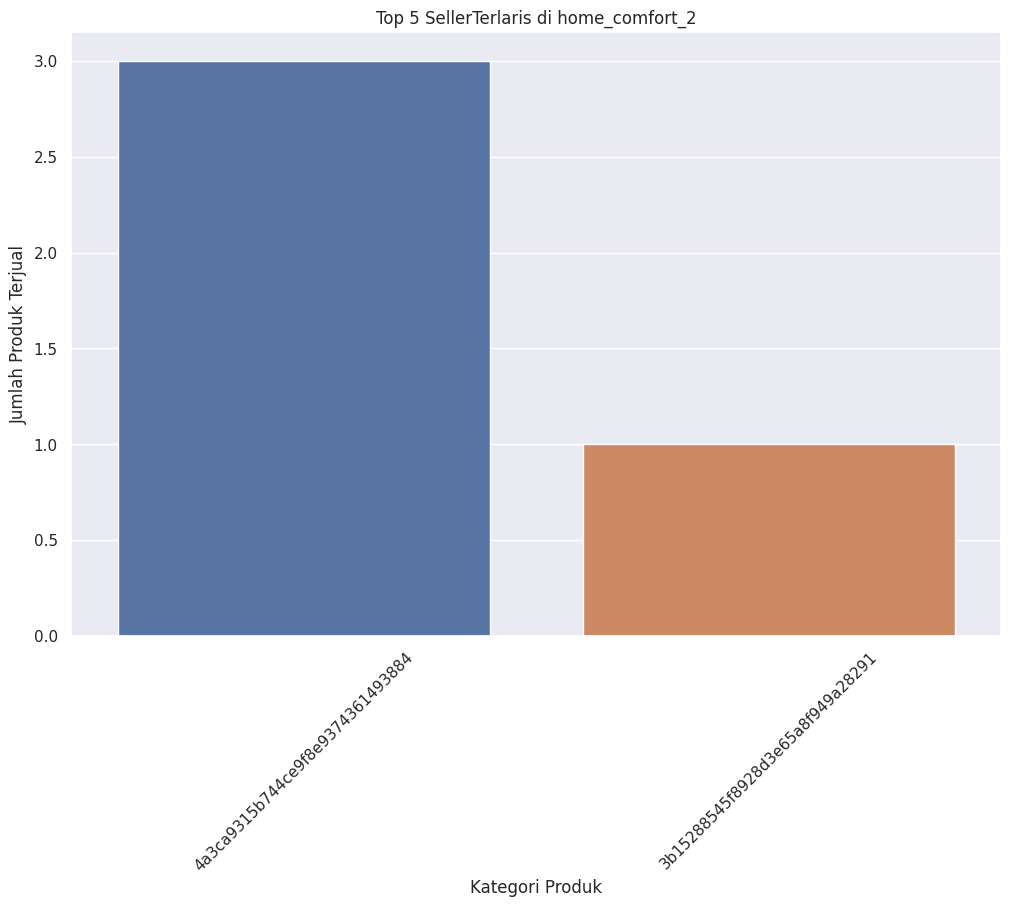

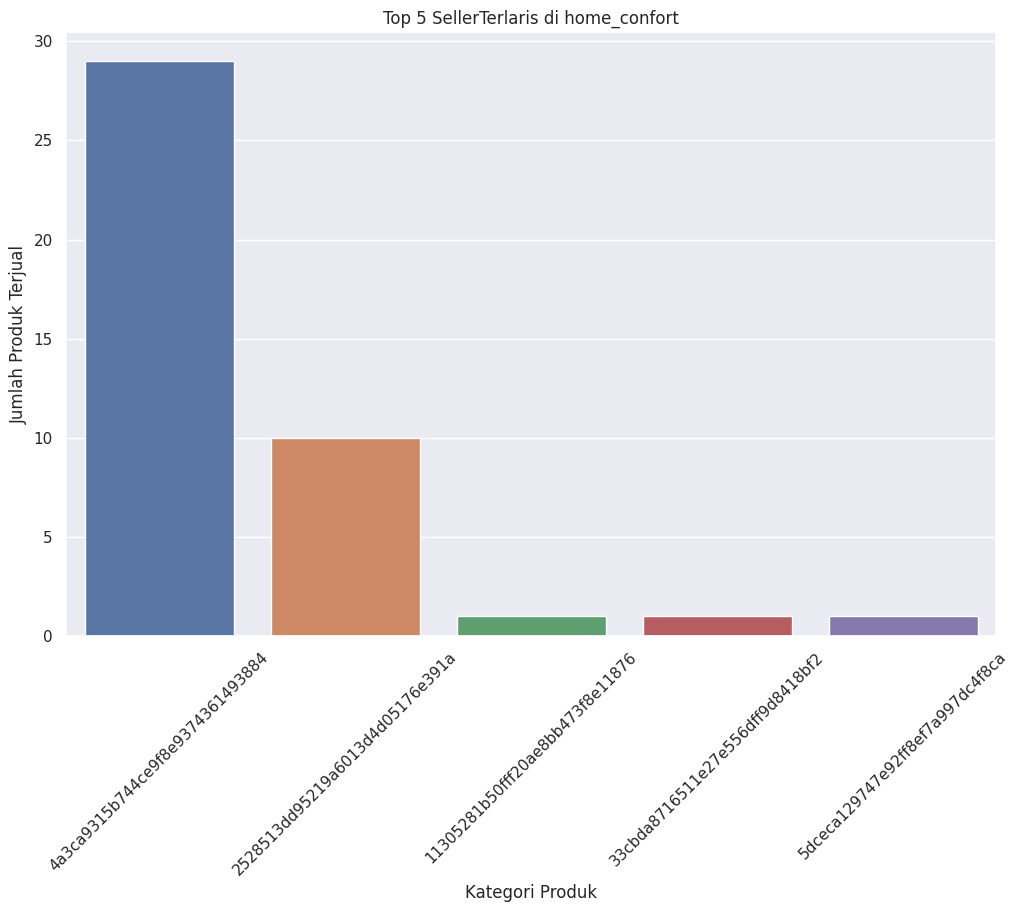

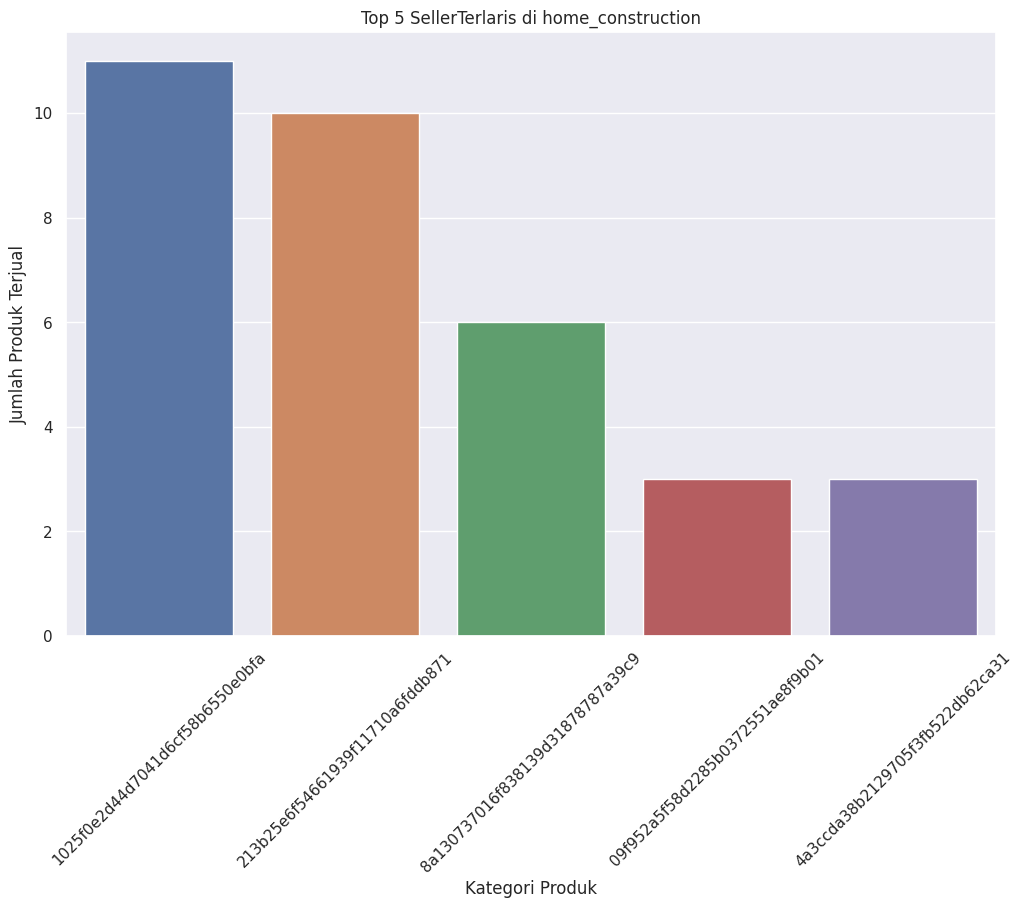

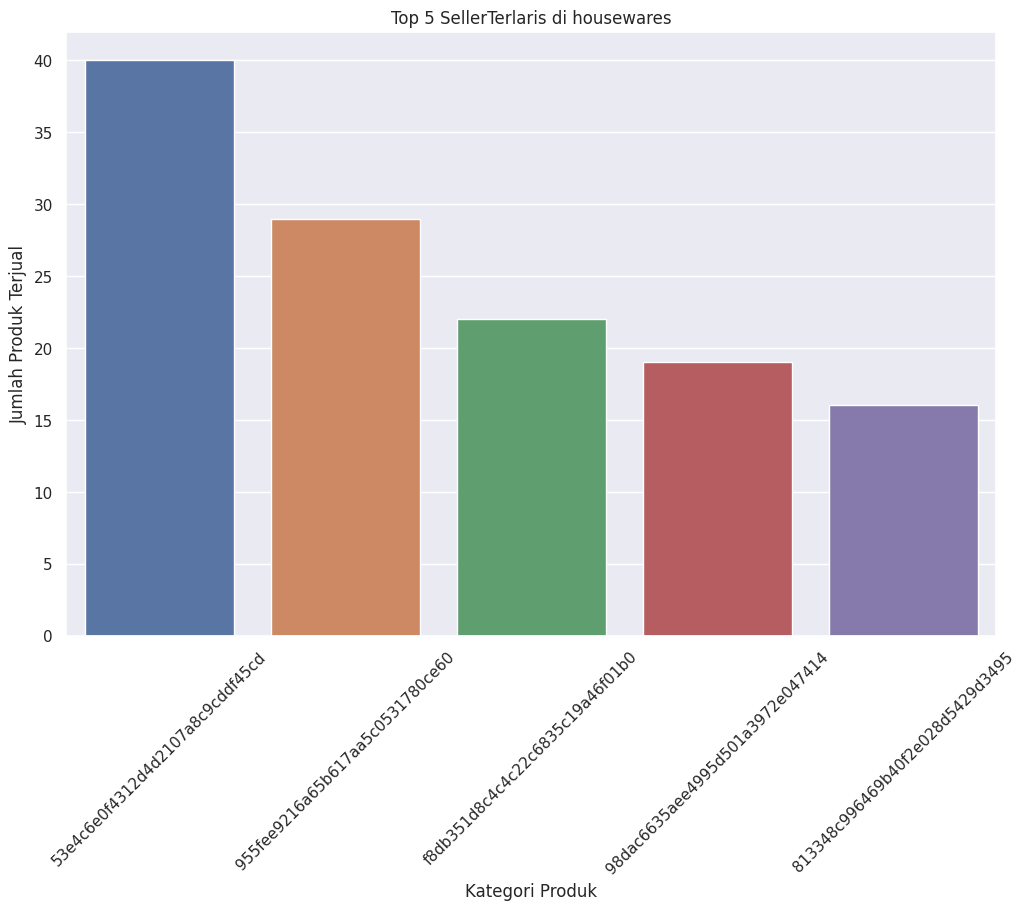

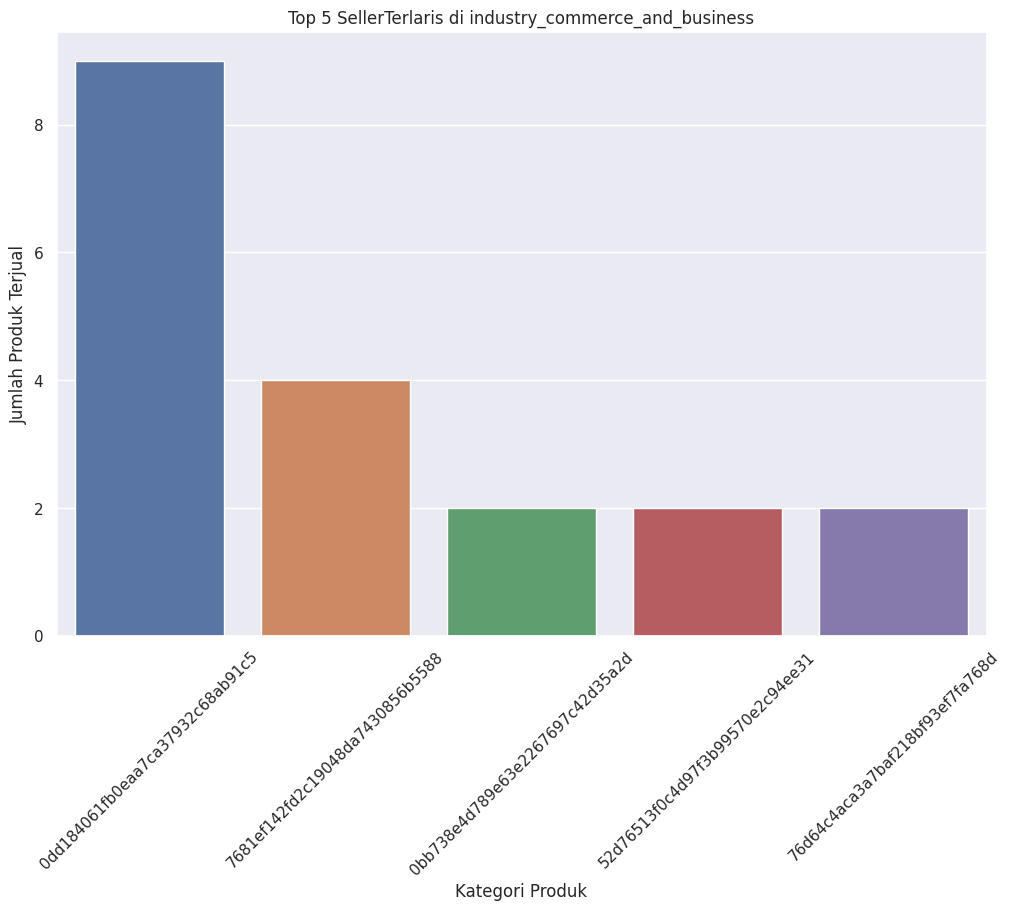

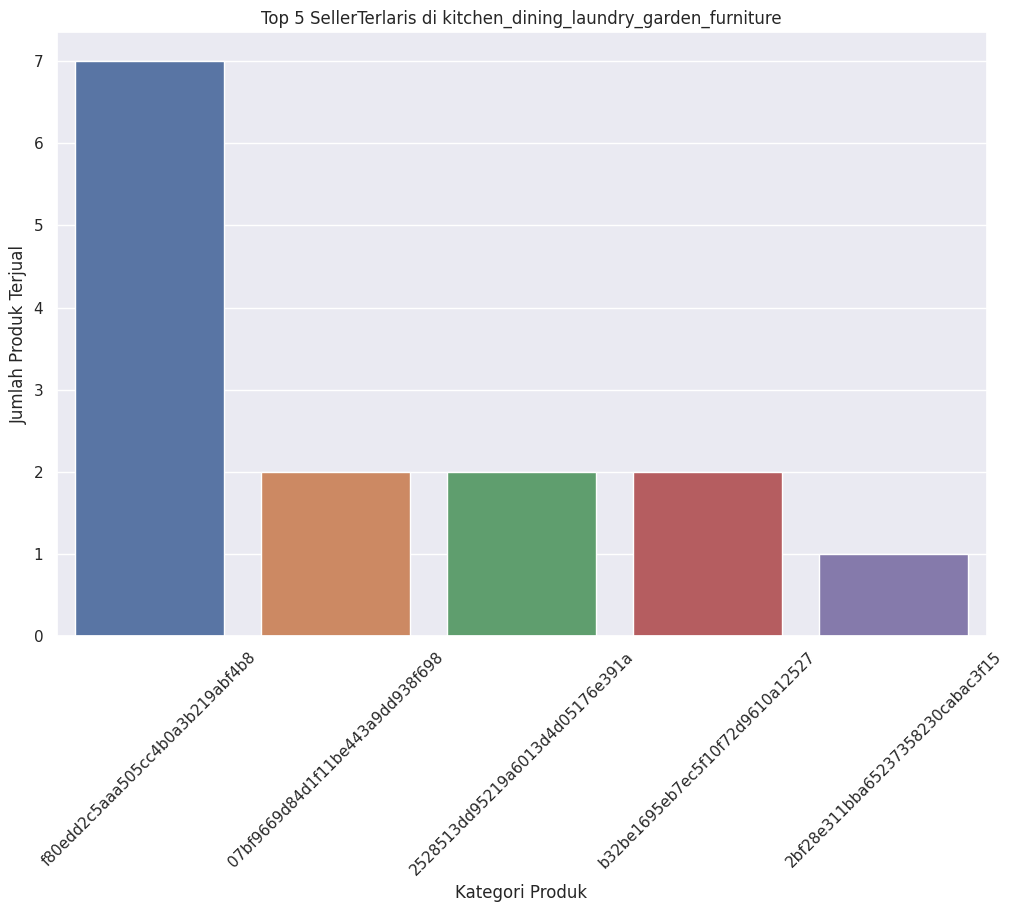

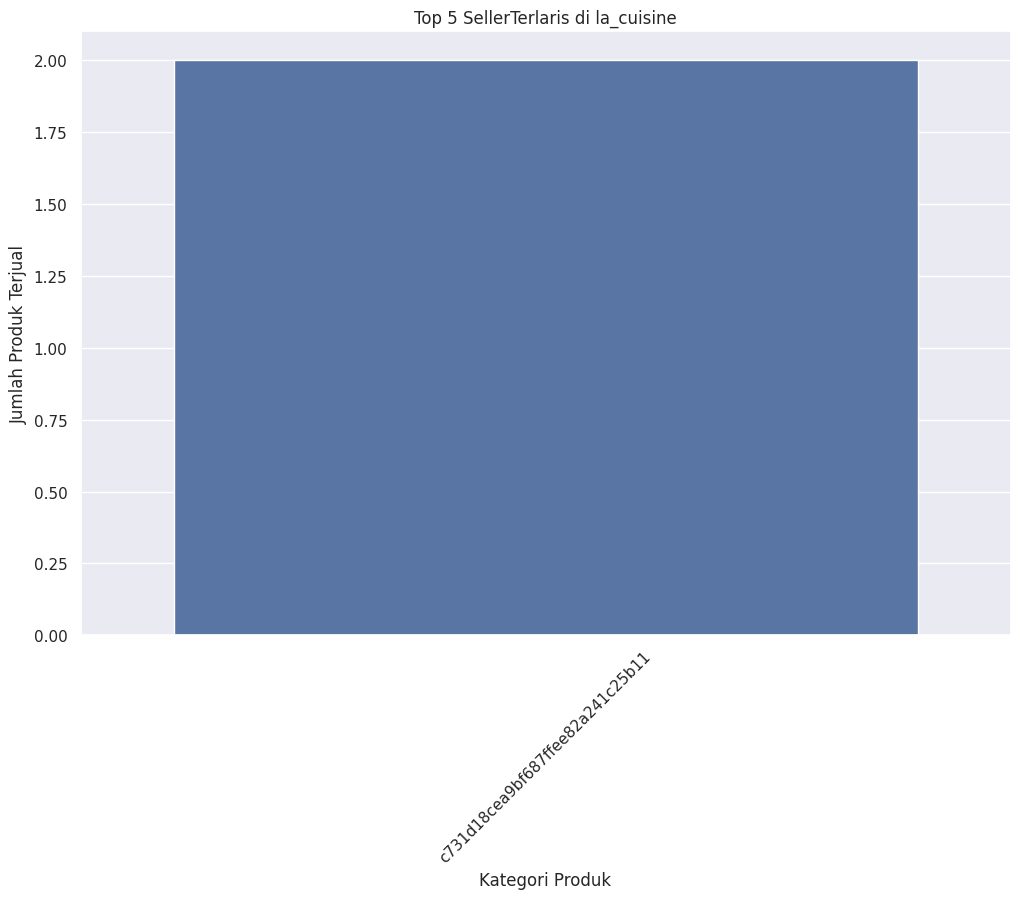

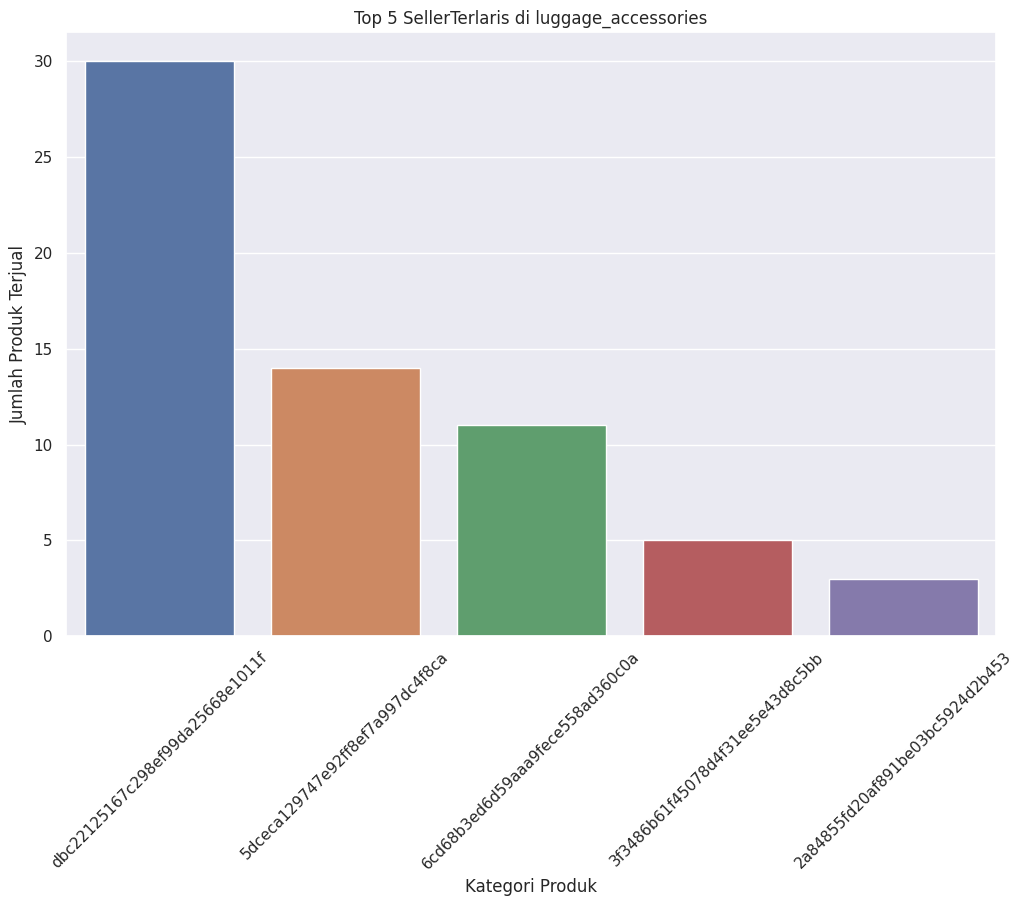

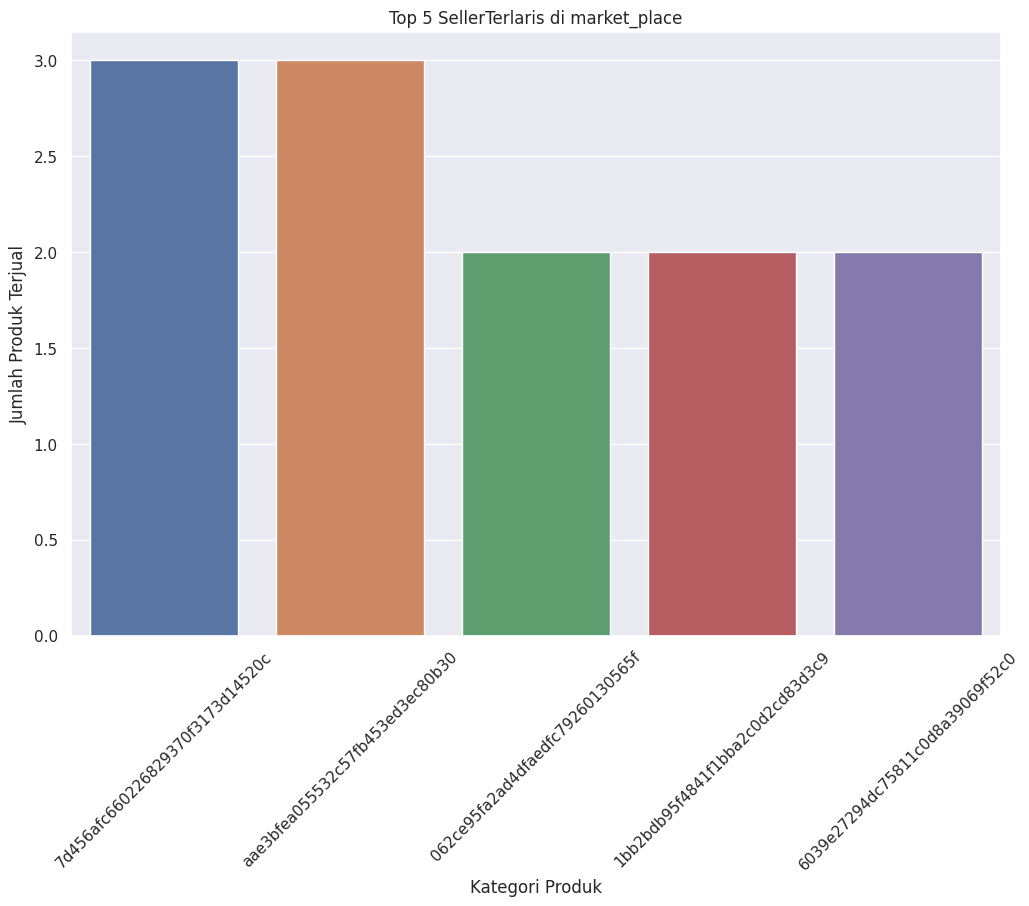

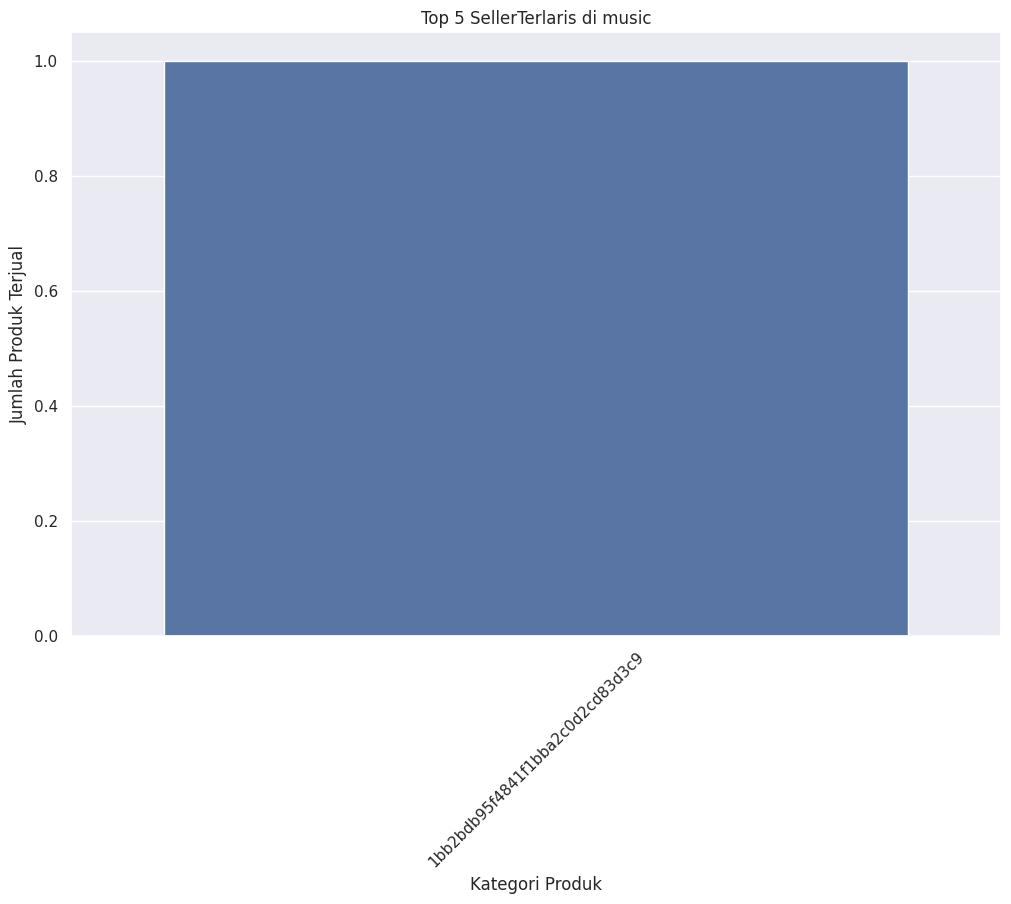

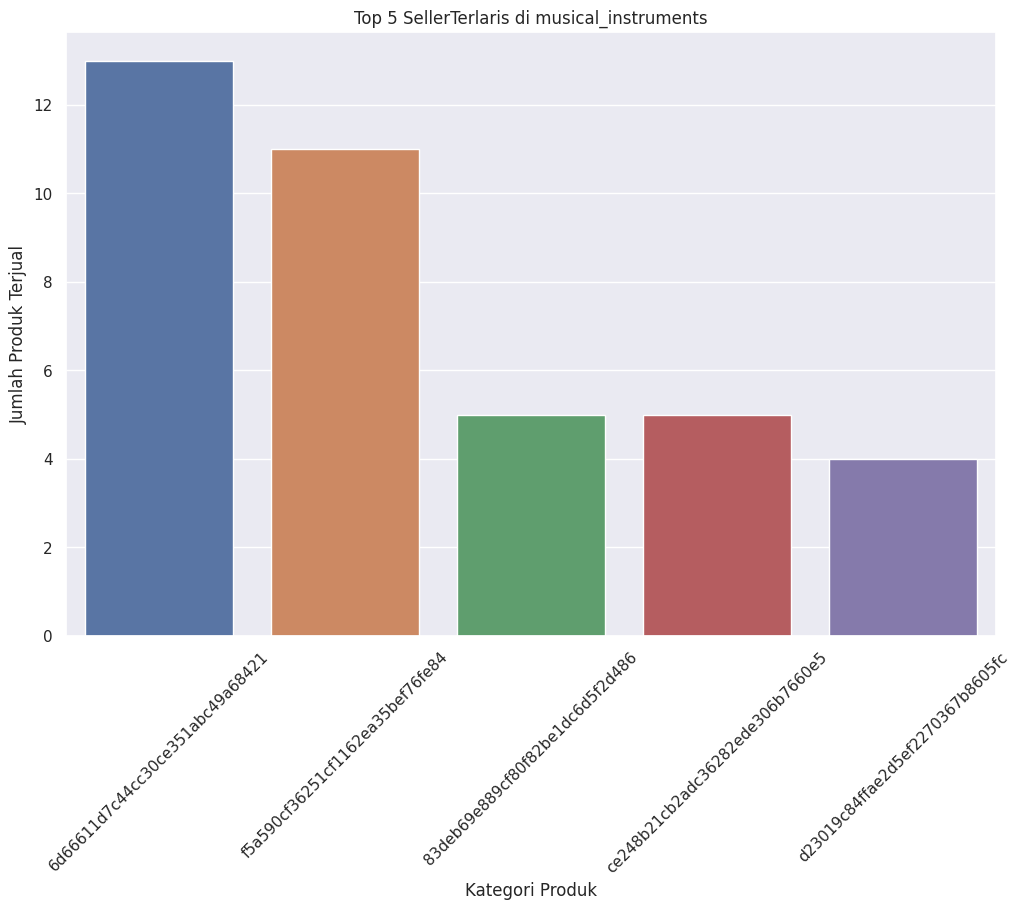

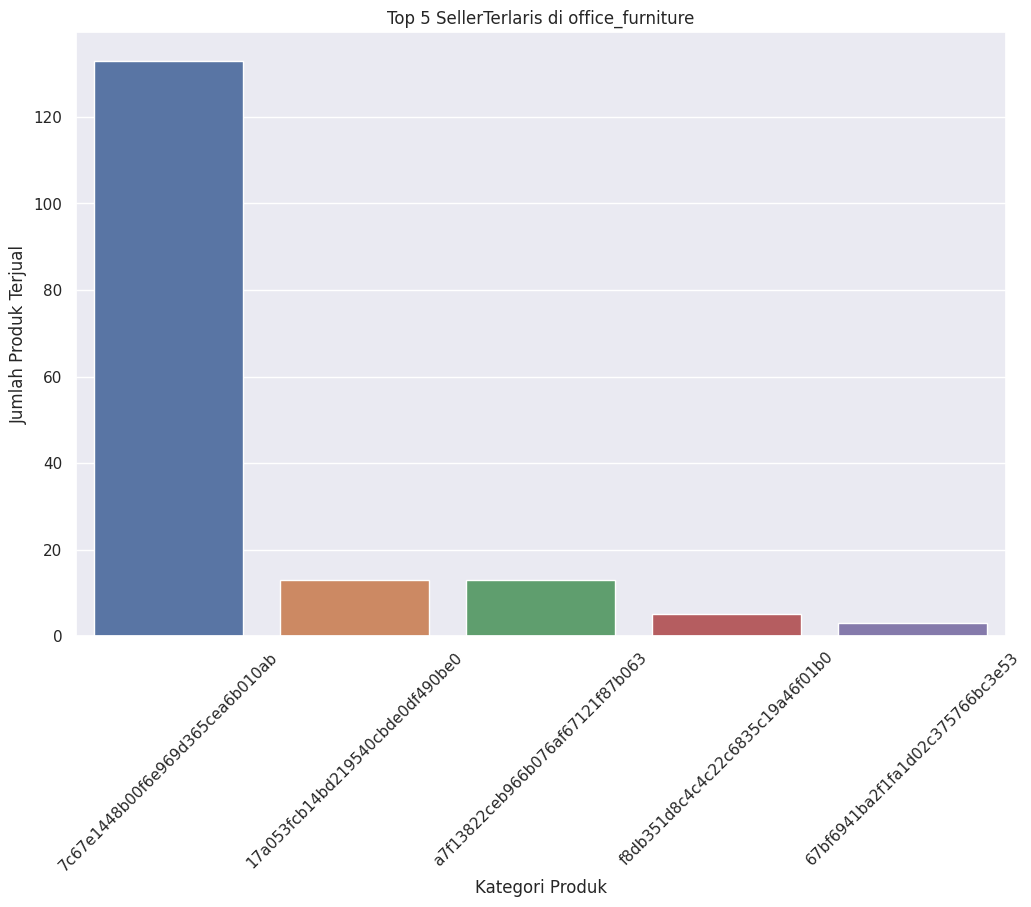

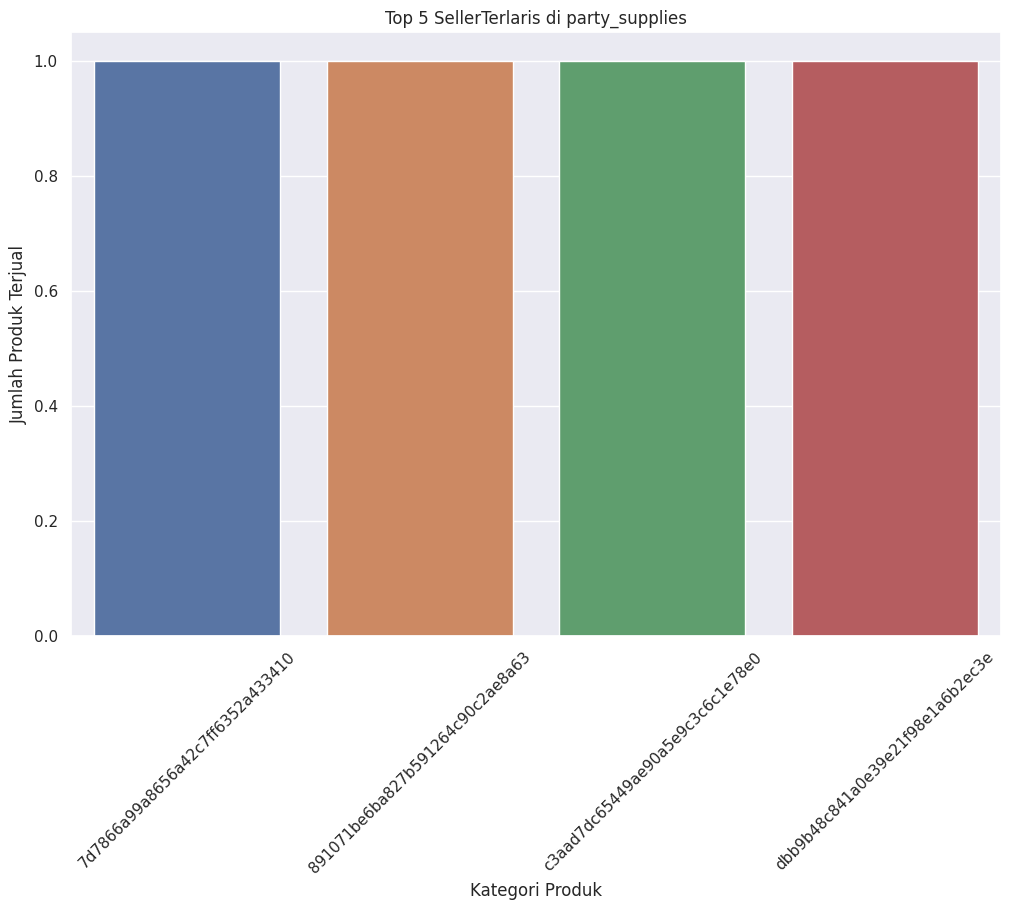

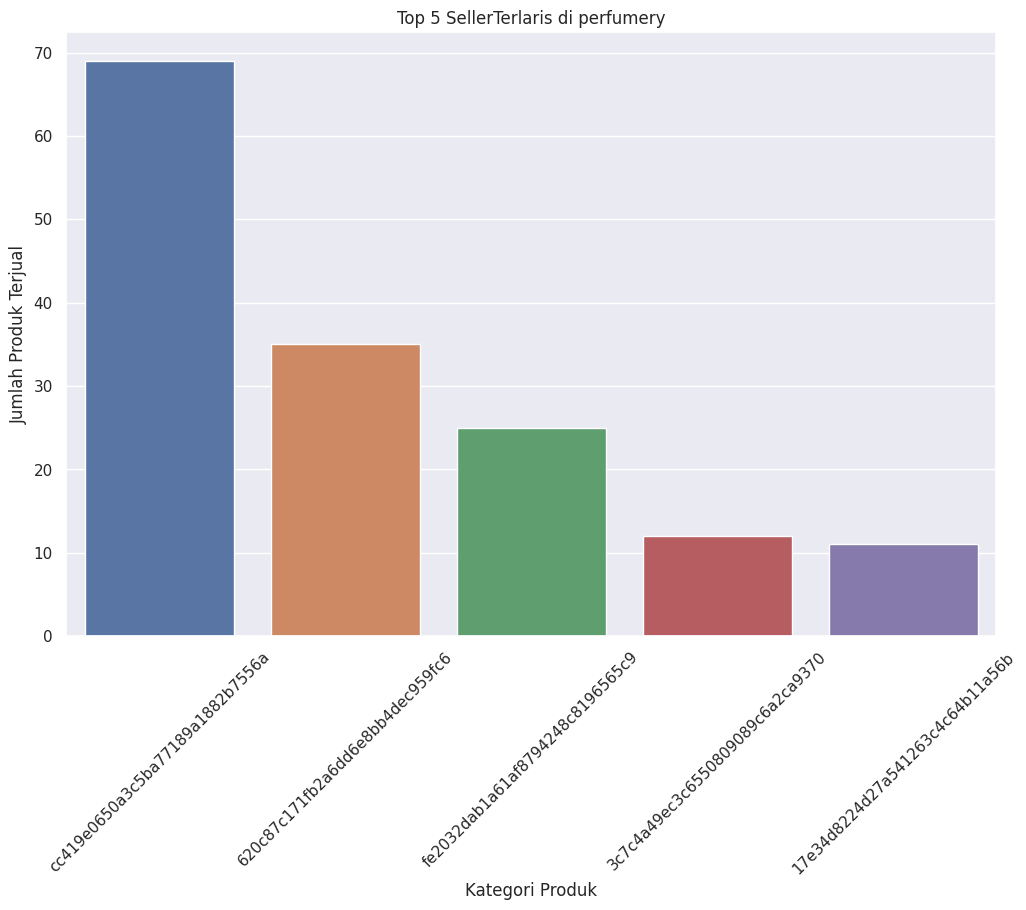

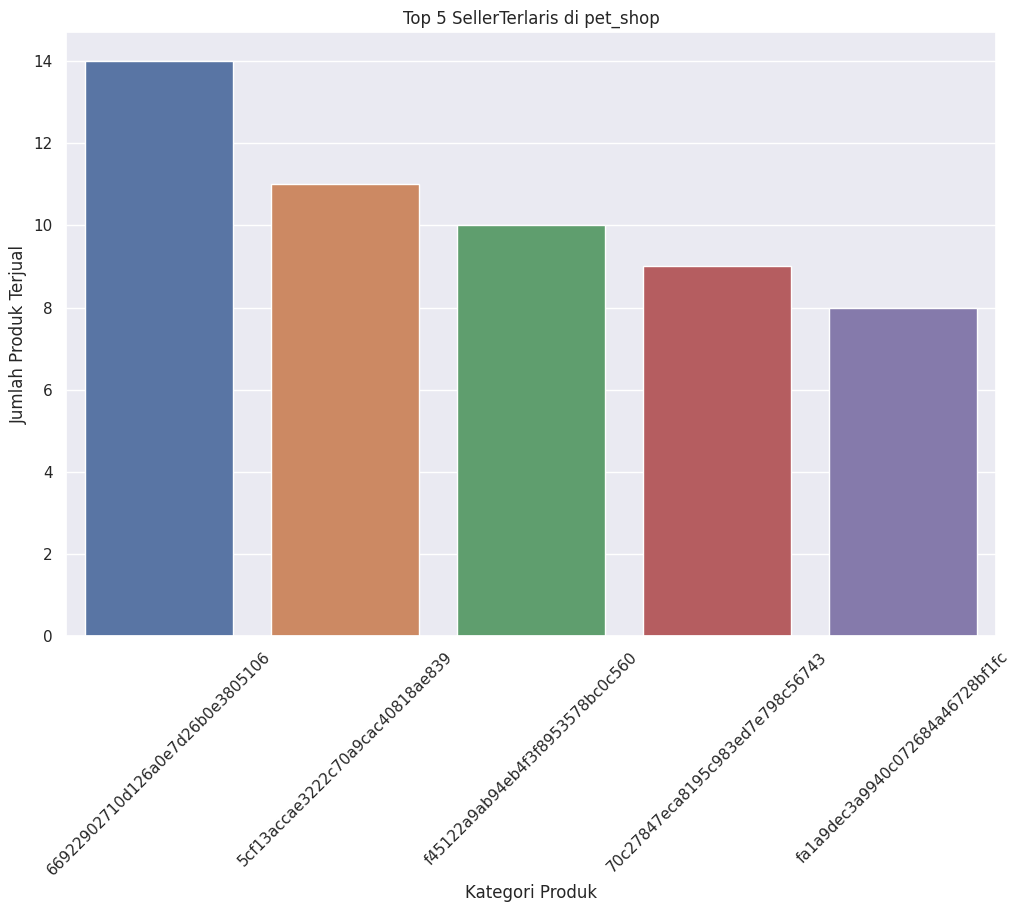

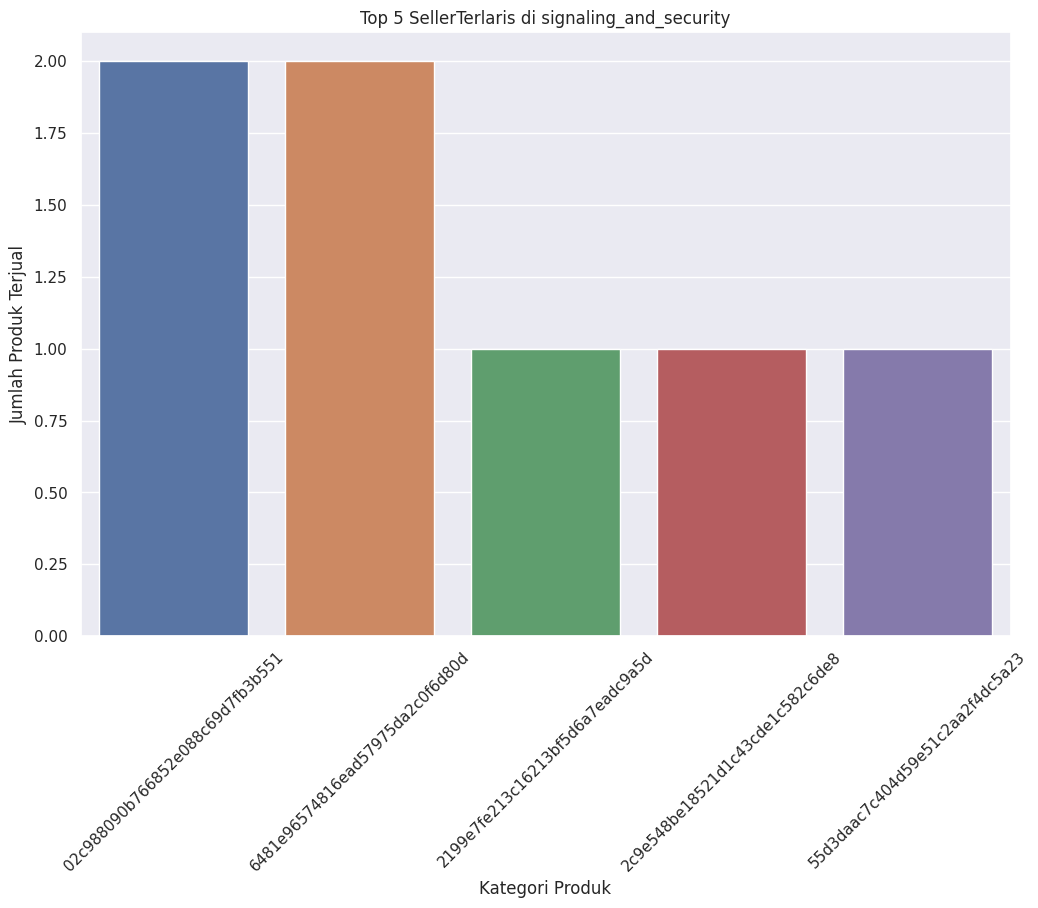

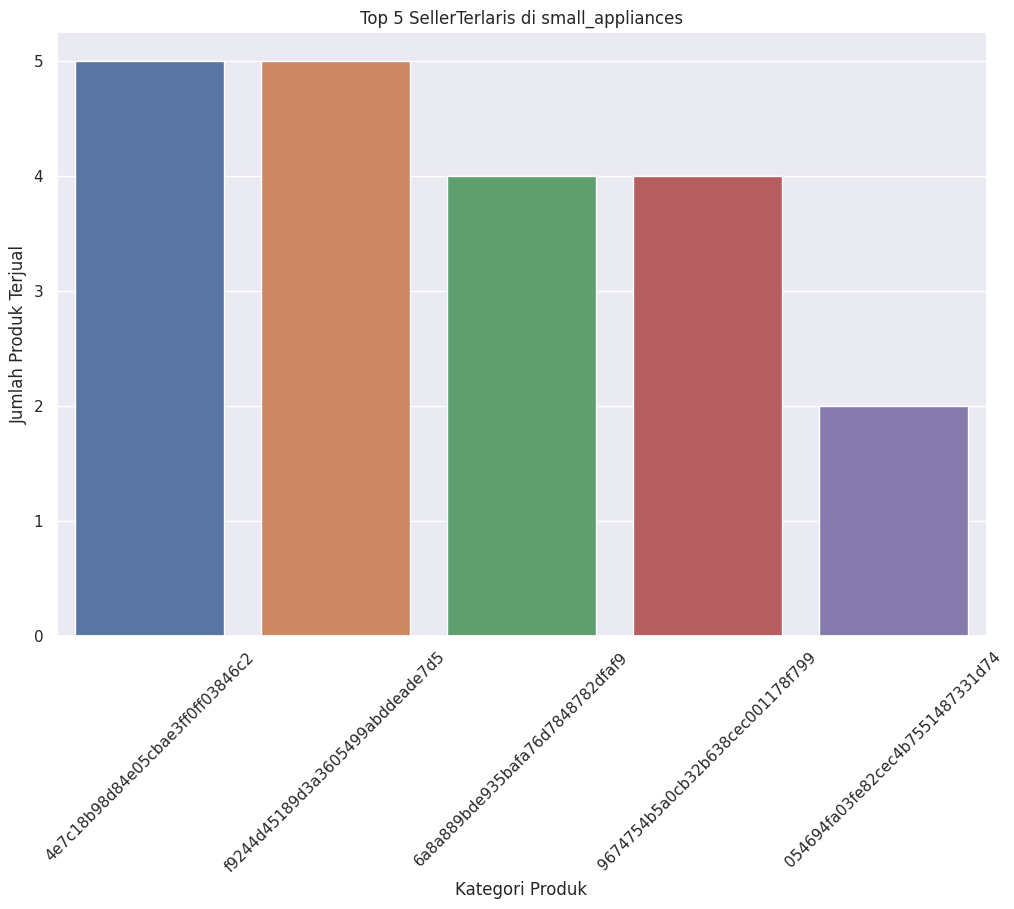

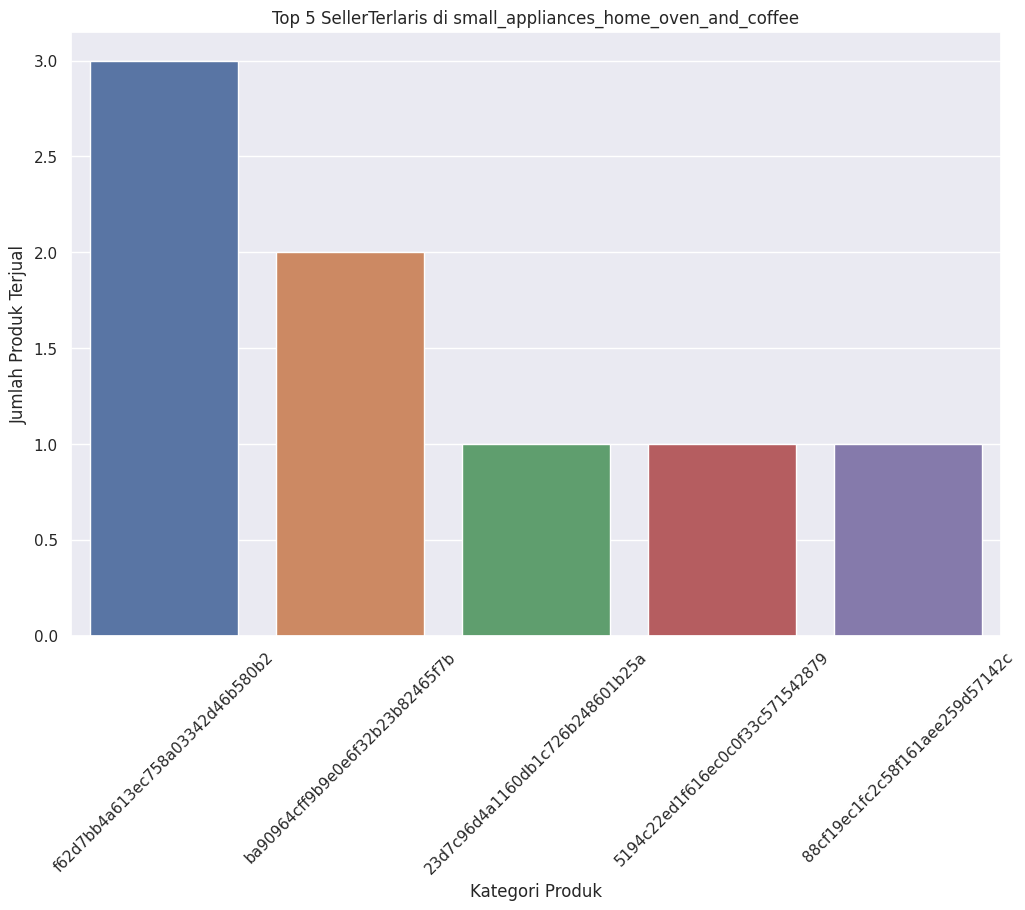

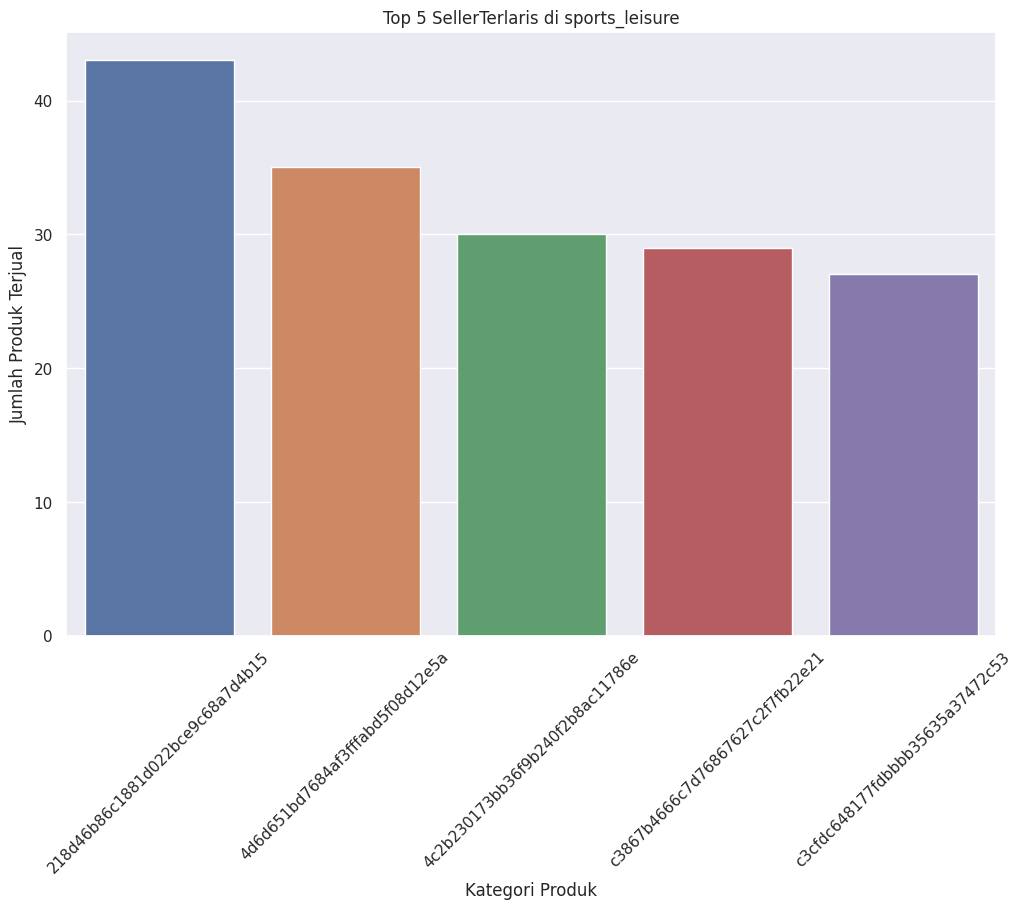

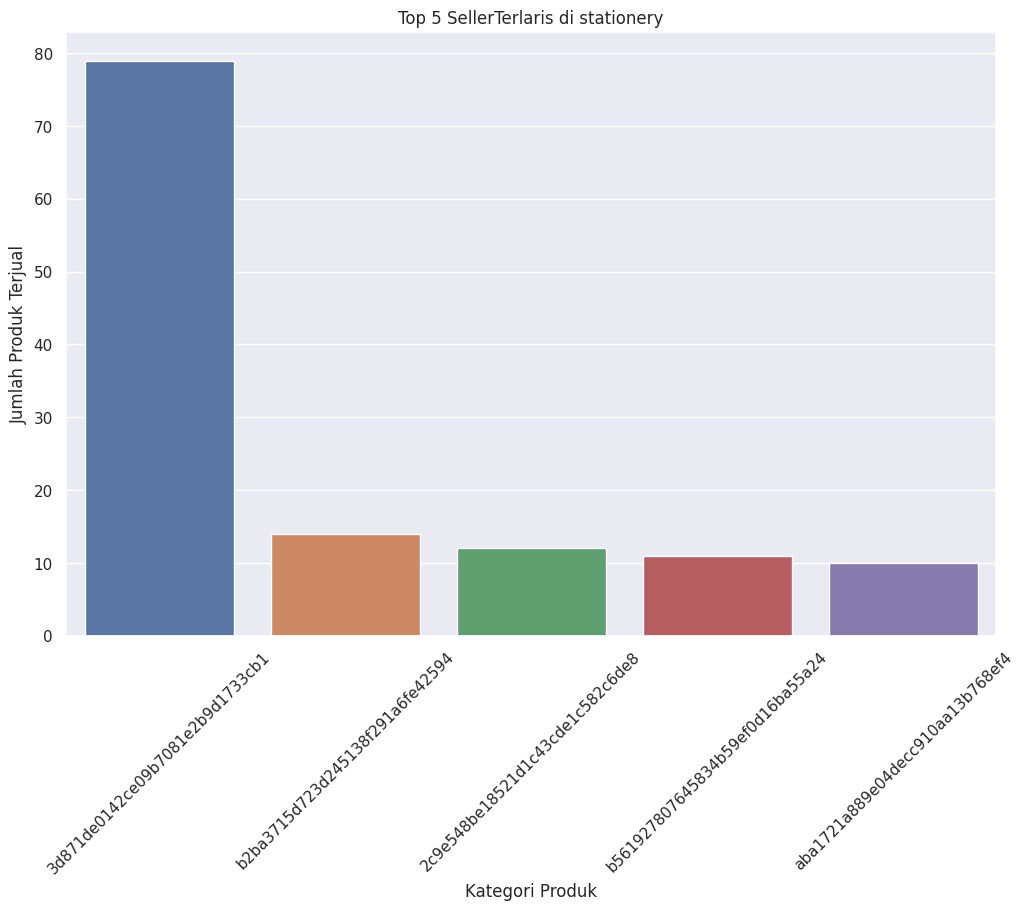

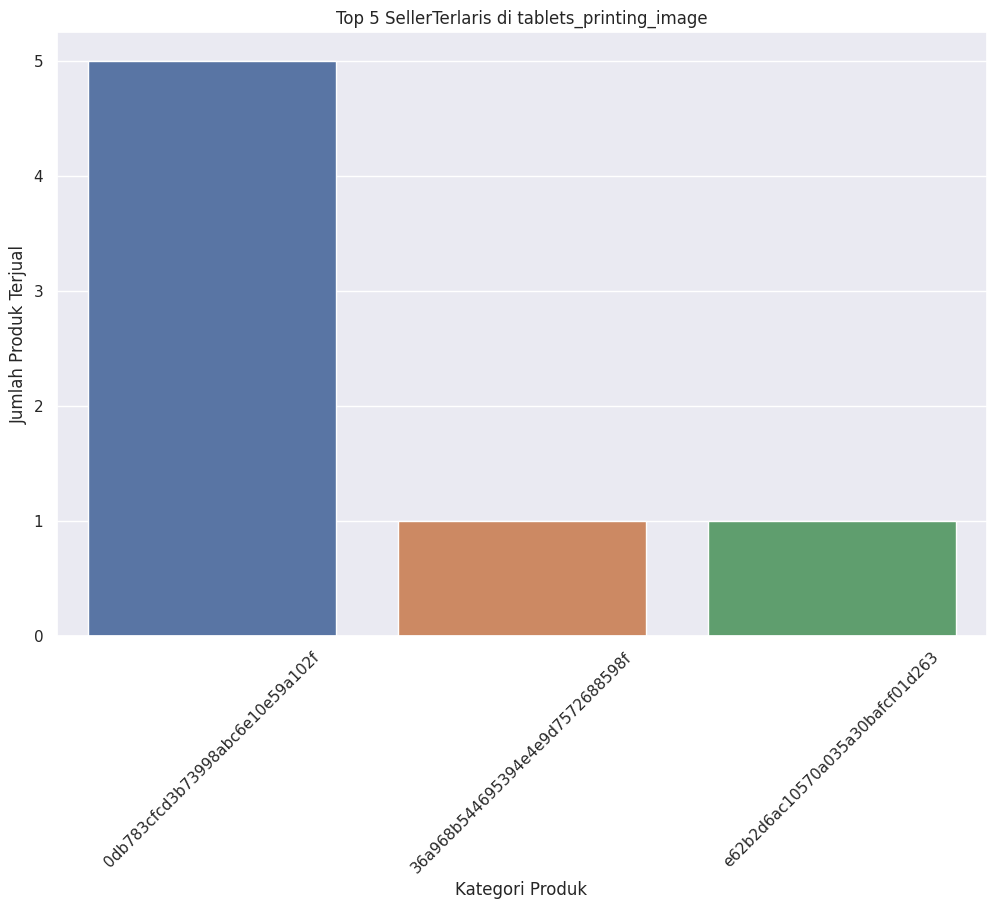

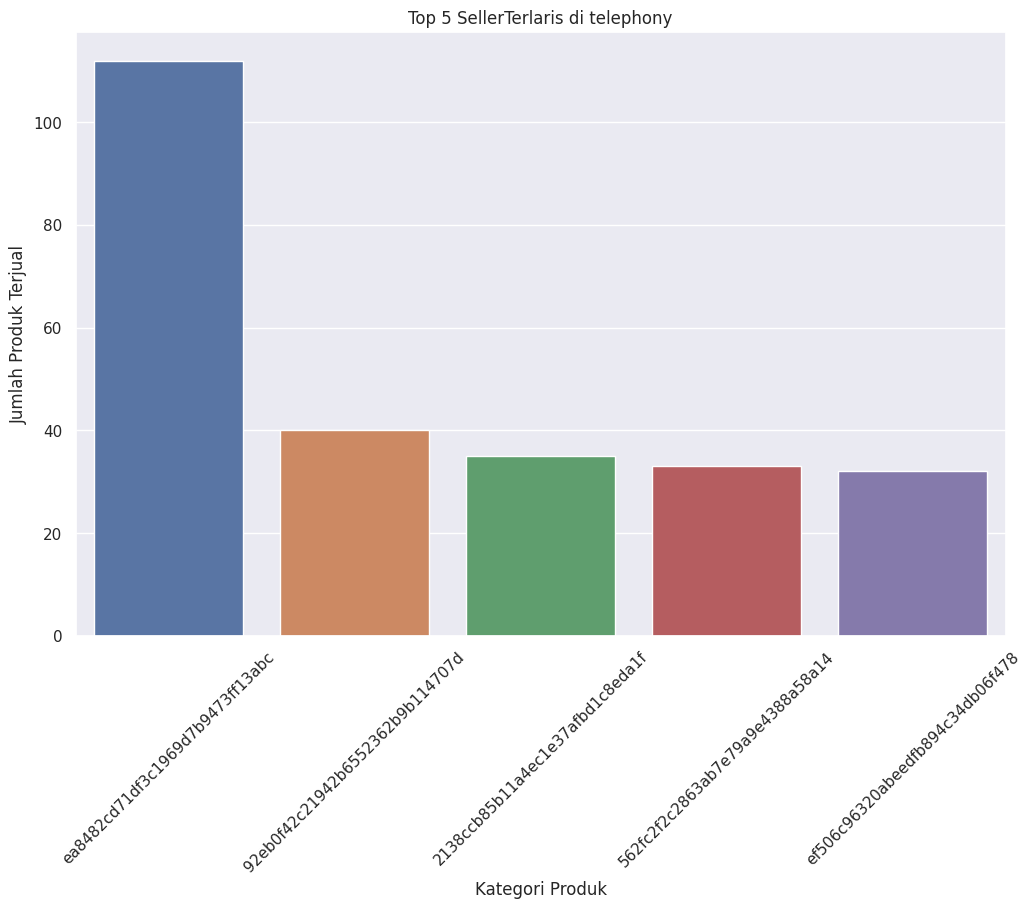

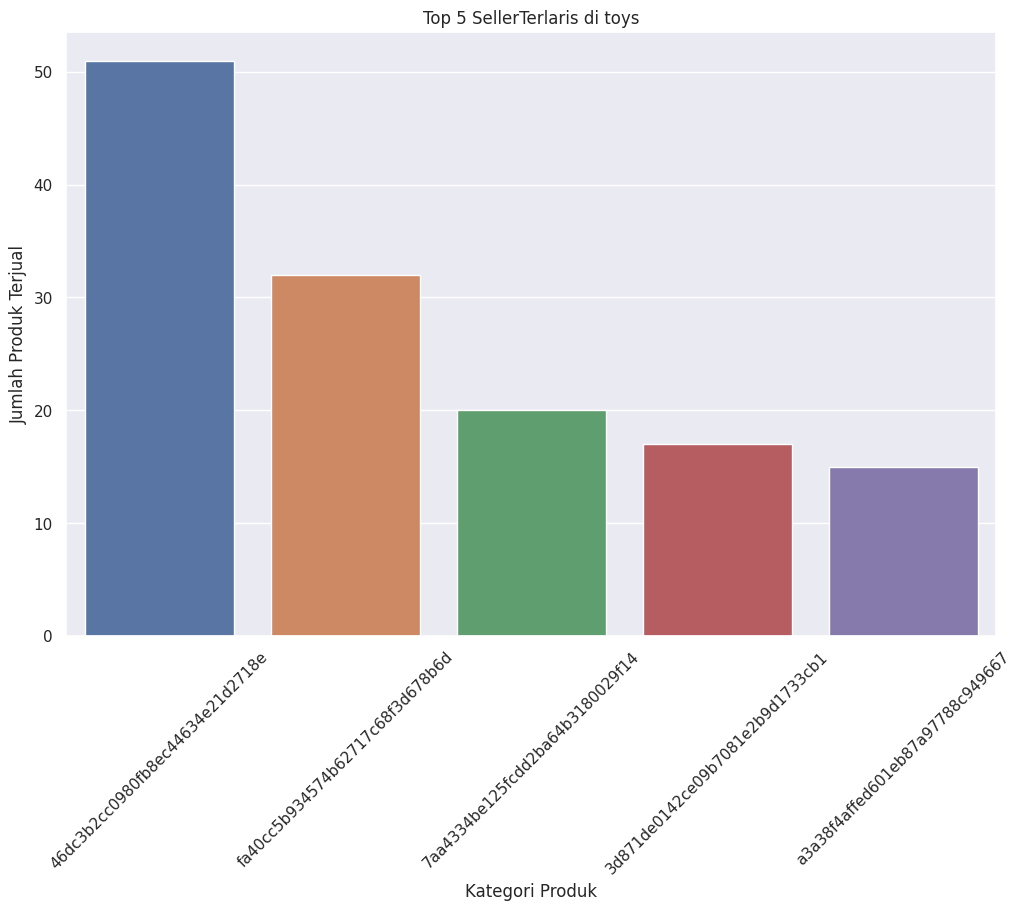

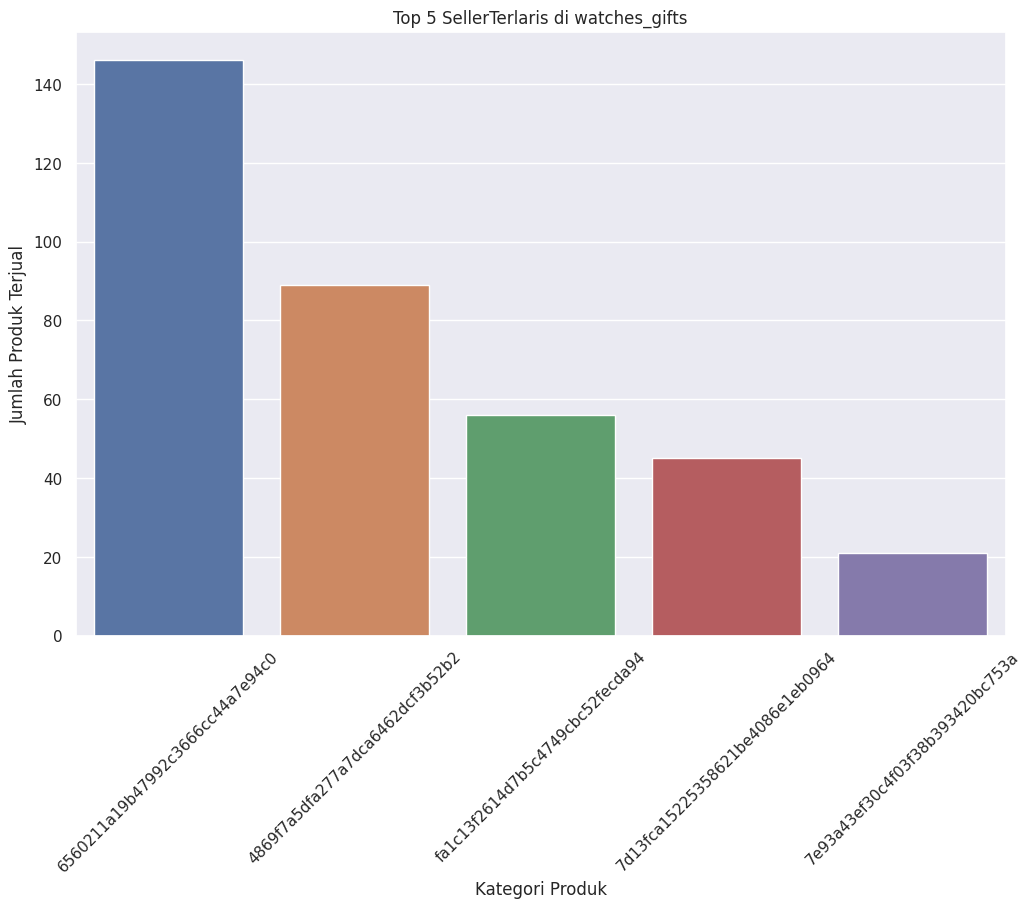

In [49]:
seller_products = df3.groupby(['product_category_name','seller_id'])['product_id.1'].count().reset_index().sort_values(['product_category_name', 'product_id.1'], ascending=[True, False])
top5_seller_products = seller_products.groupby('product_category_name').head(5)

for seller in top5_seller_products['product_category_name'].unique():
    data = top5_seller_products[top5_seller_products['product_category_name'] == seller]
    plt.figure(figsize=(12, 8), dpi=100)
    sns.barplot(x='seller_id', y='product_id.1', data=data)
    plt.title(f'Top 5 SellerTerlaris di {seller}')
    plt.xlabel('Kategori Produk')
    plt.ylabel('Jumlah Produk Terjual')
    plt.xticks(rotation=45)
    plt.show()

In [50]:
def categorize_review(score, threshold):
    if score > threshold:
        return 'Positif'
    elif score == threshold:
        return 'Netral'
    else:
        return 'Negatif'


# definisikan threshold untuk kategori positif/negatif
threshold = 3

# tambahkan kolom baru yang berisi kategori positif/negatif
df3['review_category'] = df3['review_score'].apply(lambda x: categorize_review(x, threshold))

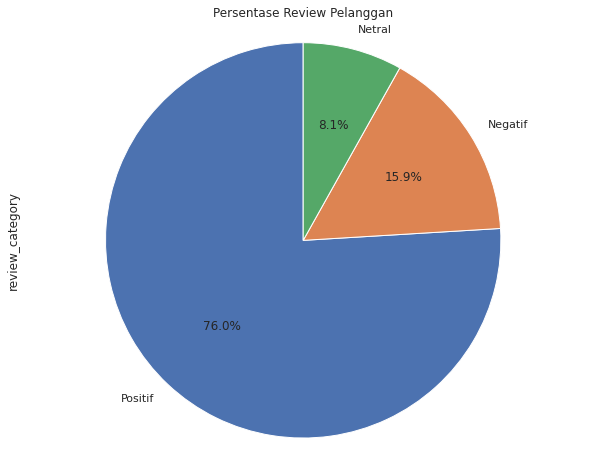

In [51]:
review_count = df3['review_category'].value_counts()

review_count.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Persentase Review Pelanggan')
plt.show()

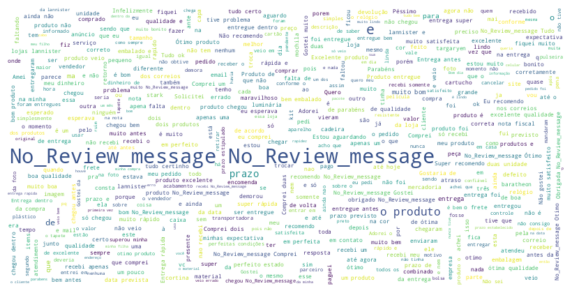

In [52]:
from wordcloud import WordCloud

# Menggabungkan kolom-kolom teks yang ingin ditampilkan
text = " ".join(review for review in df3.review_comment_message.dropna())

# Membuat objek WordCloud
wordcloud = WordCloud(width=800, height=400, max_words=500, background_color='white').generate(text)

# Menampilkan WordCloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [53]:
#RFM ANALYSIS
import datetime as dt

last= df3['order_purchase_timestamp'].max()
dhari_plus1 = last + dt.timedelta(days=1)

#calculate RFM metrics
rfm_table = df3.groupby('customer_unique_id').agg({
    'order_purchase_timestamp' : lambda x : (dhari_plus1- x.max()).days,
    'order_id' : 'count',
    'payment_value' : 'sum'})

#Mengganti nama agar gambar diidentifikasi
rfm_table.reset_index(inplace=True)
rfm_table.rename(columns= {'order_purchase_timestamp': 'Recency',
                        'order_id': 'Frequency',
                        'payment_value': 'Monetary'},inplace= True)

rfm_table

,customer_unique_id,Recency,Frequency,Monetary
0,000de6019bb59f34c099a907c151d855,377,1,257.44
1,000e309254ab1fc5ba99dd469d36bdb4,66,1,8.53
2,000ed48ceeb6f4bf8ad021a10a3c7b43,101,1,20.75
3,0011c98589159d6149979563c504cb21,390,1,117.94
4,0015752e079902b12cd00b9b7596276b,27,1,74.82
...,...,...,...,...
10420,ffbcd1715dfbead64e1b896044d73c76,114,1,35.77
10421,ffca77d46c6d7d815549a5e4482dba2f,160,1,155.34
10422,ffe780a8995715d9560ca10f3351710f,385,1,142.50
10423,ffec490ab531184a483efe2eedd68908,26,1,57.98


In [54]:
#Mengambil nilai RFM saja
RFM_only = rfm_table[['Recency', 'Frequency', 'Monetary']]

#Duplikasi data RFM
RFM1 = RFM_only.copy()

<ipython-input-55-5c68fabde5d9>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(RFM1['Recency'])
<ipython-input-55-5c68fabde5d9>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distplot(RFM1['Frequency'])
<ipython-input-55-5c68fabde5d9>:5: UserWarning: 

`dis

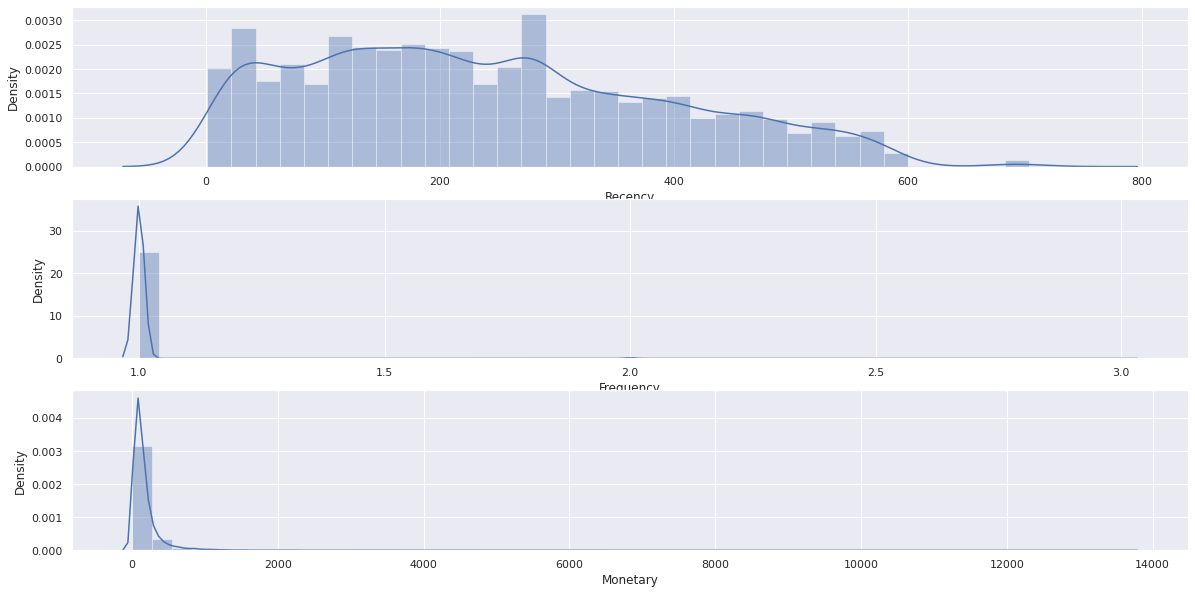

In [55]:
# Visualisasi Distribusi RFM
fig = plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1); sns.distplot(RFM1['Recency'])
plt.subplot(3, 1, 2); sns.distplot(RFM1['Frequency'])
plt.subplot(3, 1, 3); sns.distplot(RFM1['Monetary'])
plt.show()

Dari chart diatas, dapat dilihat bahwa visualisasi Monetary condong ke kiri, selanjutnya kita akan membuat Monetary tidak condong dengan cara Log Transformasi

In [56]:
#Log Transformasi untuk Monetary
RFM1['Monetary']= np.log(RFM1['Monetary'])

<ipython-input-57-6043f8c06213>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(RFM1['Recency'])
<ipython-input-57-6043f8c06213>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distplot(RFM1['Frequency'])
<ipython-input-57-6043f8c06213>:5: UserWarning: 

`dis

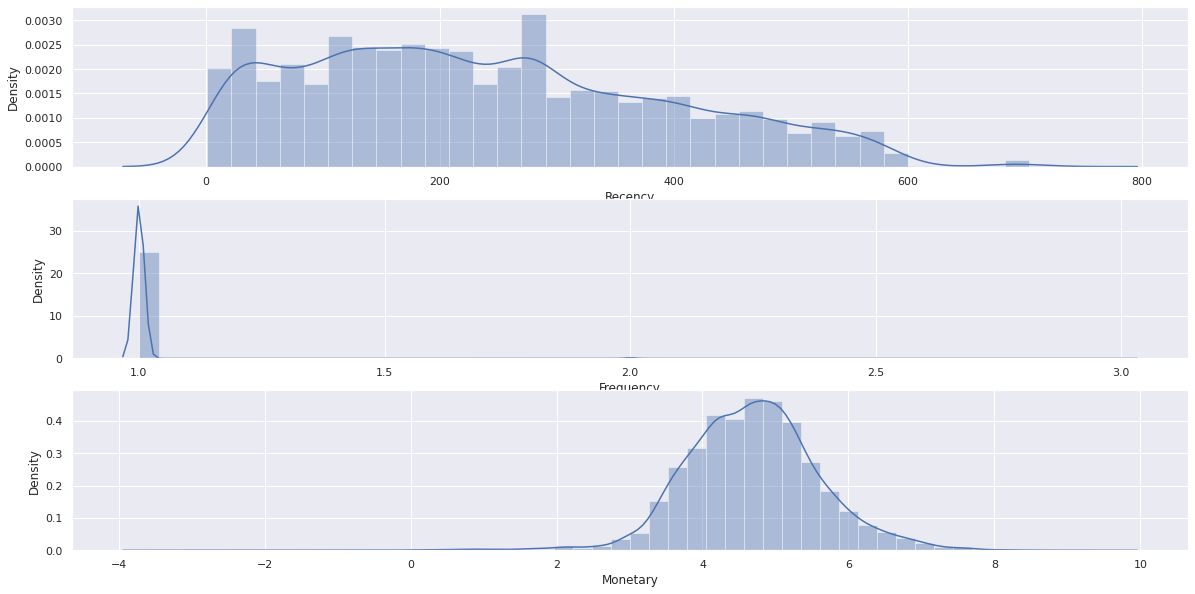

In [57]:
# visualisasi kembali setelah dilakukan transformasi
fig = plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1); sns.distplot(RFM1['Recency'])
plt.subplot(3, 1, 2); sns.distplot(RFM1['Frequency'])
plt.subplot(3, 1, 3); sns.distplot(RFM1['Monetary'])
plt.show()

Untuk saat ini Monetary sudah tidak condong. Selanjutnya kita melakukan Normalisasi data RFM

In [58]:
#Menggunakan StandardScaler dari sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(RFM1)

#normalize the variables
RFM1_Normal = scaler.transform(RFM1)

# store for clustering
RFM1_Normal = pd.DataFrame(data= RFM1_Normal, index= RFM1.index, columns = RFM1.columns)
RFM1_Normal

,Recency,Frequency,Monetary
0,0.897342,-0.067353,0.932476
1,-1.133780,-0.067353,-2.744605
2,-0.905197,-0.067353,-1.785234
3,0.982245,-0.067353,0.090033
4,-1.388487,-0.067353,-0.401105
...,...,...,...
10420,-0.820295,-0.067353,-1.197536
10421,-0.519872,-0.067353,0.387291
10422,0.949590,-0.067353,0.294183
10423,-1.395018,-0.067353,-0.676290


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: F

<function matplotlib.pyplot.show(close=None, block=None)>

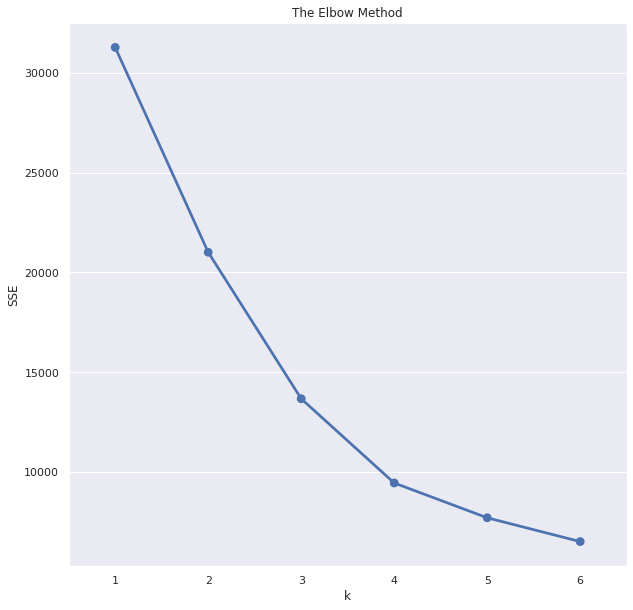

In [59]:
from sklearn.cluster import KMeans

#Tentukan jumlah cluster dengan elbow method
sse= {}
for k in range(1,7):
  kmeans= KMeans(n_clusters=k)
  kmeans.fit(RFM1_Normal)
  sse[k] = kmeans.inertia_

fig = plt.figure(figsize=(10, 10))
plt.title('The Elbow Method')
plt.xlabel('k');plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show


Dari Metode Elbow, bisa dilihat jumlah Cluster yang optimal sekitar 3 atau 4.

In [60]:
# Lakukan clustering dengan k-means
kmeans = KMeans(n_clusters=4)
kmeans.fit(RFM1_Normal)
cluster_labels = kmeans.labels_

rfm_table2= rfm_table.assign(Cluster=cluster_labels)

mean_rfm_table2 = rfm_table2.groupby('Cluster')['Recency','Frequency','Monetary'].mean()

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-60-01abf5894905>:8: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  mean_rfm_table2 = rfm_table2.groupby('Cluster')['Recency','Frequency','Monetary'].mean()


In [61]:
mean_rfm_table2

,Recency,Frequency,Monetary
Cluster,,,
0,160.068587,1.000000,306.332258
1,158.637168,1.000000,59.837069
2,230.750000,2.020833,344.334167
3,426.728498,1.000000,134.282667


Dari hasil diatas, dapat dilihat hampir semua Cluster memiliki Nilai Mean yang sama pada Frequency, Artinya kebanyakan dari cutsomer baru satu kali pembelanjaan dan hanya sedikit customer yang melakukan pembelanjaan berulang. Pada kasus ini, kita akan mencoba Cluster satu kali lagi namun hanya menggunakan Recency dan Monetary sebagai variabel.

In [62]:
df_RM = df3.copy()

last= df_RM['order_purchase_timestamp'].max()
hari_plus1 = last + dt.timedelta(days=1)

#calculate RFM metrics
rm_table = df_RM.groupby('customer_unique_id').agg({
    'order_purchase_timestamp' : lambda x : (dhari_plus1- x.max()).days,
    'payment_value' : 'sum'})

#Mengganti nama agar gambar diidentifikasi
rm_table.reset_index(inplace=True)
rm_table.rename(columns= {'order_purchase_timestamp': 'Recency',
                        'payment_value': 'Monetary'},inplace= True)

In [63]:
#Mengambil nilai RFM saja
RM_only = rm_table[['Recency', 'Monetary']]

#Duplikasi data RFM
RM1 = RM_only.copy()

<ipython-input-64-6de834db7d19>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(RM1['Recency'])
<ipython-input-64-6de834db7d19>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distplot(RM1['Monetary'])


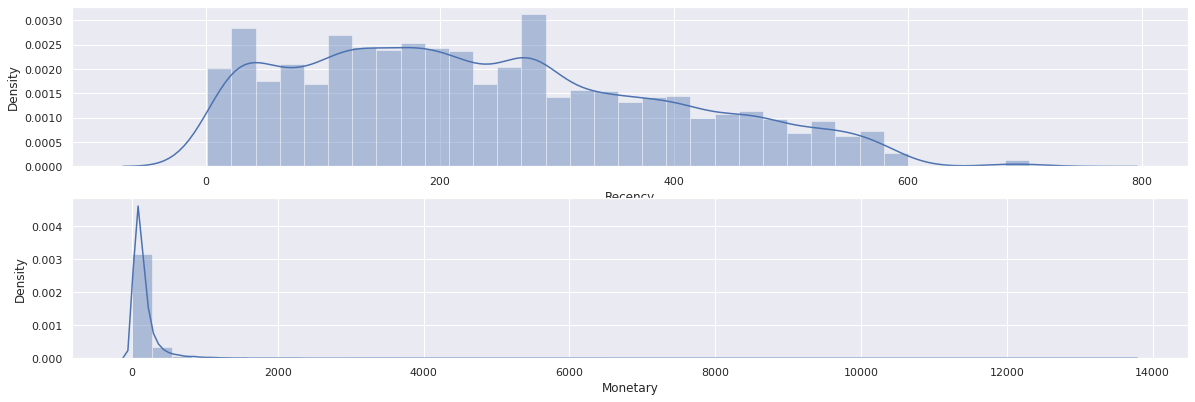

In [64]:
# Visualisasi Distribusi RFM
fig = plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1); sns.distplot(RM1['Recency'])
plt.subplot(3, 1, 2); sns.distplot(RM1['Monetary'])
plt.show()

Dari chart diatas, dapat dilihat bahwa visualisasi Monetary condong ke kiri, selanjutnya kita akan membuat Monetary tidak condong dengan cara Log Transformasi

In [65]:
#Log Transformasi untuk Monetary
RM1['Monetary']= np.log(RM1['Monetary'])

<ipython-input-66-a8b6eac61bab>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(RFM1['Recency'])
<ipython-input-66-a8b6eac61bab>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distplot(RFM1['Monetary'])


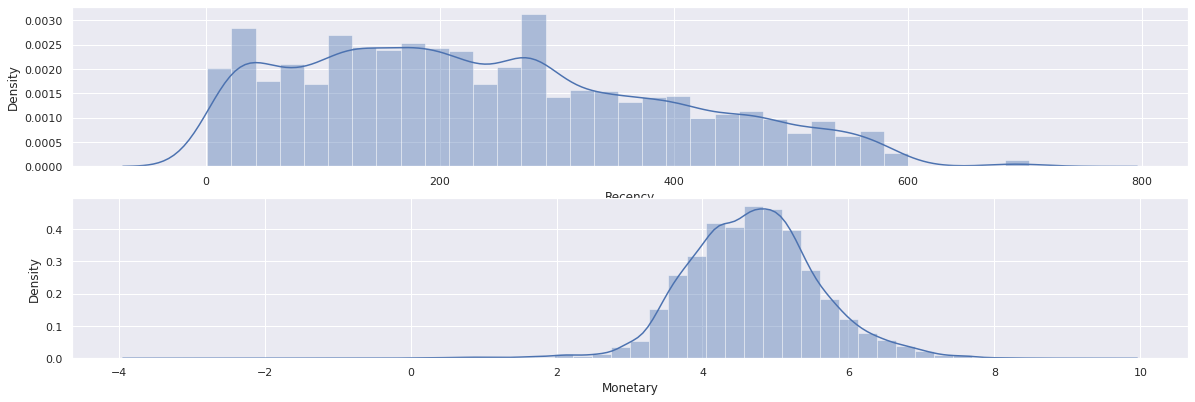

In [66]:
# visualisasi kembali setelah dilakukan transformasi
fig = plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1); sns.distplot(RFM1['Recency'])
plt.subplot(3, 1, 2); sns.distplot(RFM1['Monetary'])
plt.show()

Untuk saat ini Monetary sudah tidak condong. Selanjutnya kita melakukan Normalisasi data RM

In [67]:
#Menggunakan StandardScaler dari sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(RM1)

#normalize the variables
RM1_Normal = scaler.transform(RM1)

# store for clustering
RM1_Normal = pd.DataFrame(data= RM1_Normal, index= RM1.index, columns = RM1.columns)
RM1_Normal

,Recency,Monetary
0,0.897342,0.932476
1,-1.133780,-2.744605
2,-0.905197,-1.785234
3,0.982245,0.090033
4,-1.388487,-0.401105
...,...,...
10420,-0.820295,-1.197536
10421,-0.519872,0.387291
10422,0.949590,0.294183
10423,-1.395018,-0.676290


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: F

<function matplotlib.pyplot.show(close=None, block=None)>

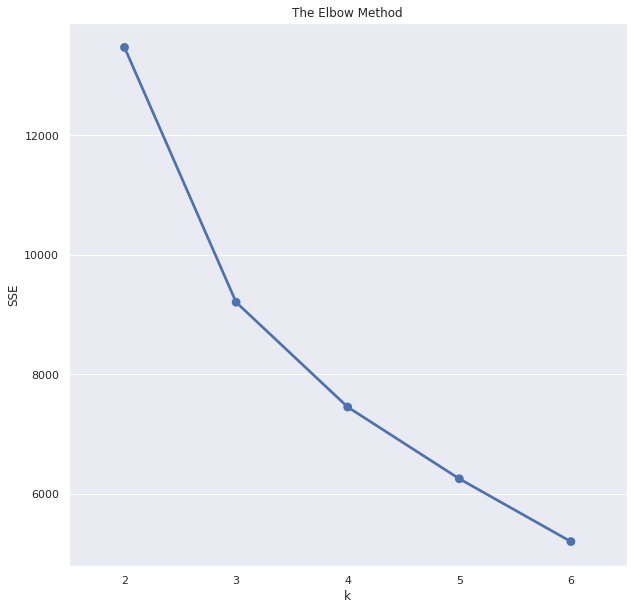

In [68]:
from sklearn.cluster import KMeans

#Tentukan jumlah cluster dengan elbow method
sse_rm= {}
for k in range(2,7):
  kmeans_rm= KMeans(n_clusters=k)
  kmeans_rm.fit(RM1_Normal)
  sse_rm[k] = kmeans_rm.inertia_

fig = plt.figure(figsize=(10, 10))
plt.title('The Elbow Method')
plt.xlabel('k');plt.ylabel('SSE')
sns.pointplot(x=list(sse_rm.keys()), y=list(sse_rm.values()))
plt.show


Dari Metode Elbow, bisa dilihat jumlah Cluster yang optimal sekitar 3 atau 4.

In [69]:
# Lakukan clustering dengan k-means
kmeans_RM = KMeans(n_clusters=3)
kmeans_RM.fit(RM1_Normal)
cluster_labels = kmeans_RM.labels_

rm_table2= rm_table.assign(Cluster=cluster_labels)

mean_rm_table2 = rm_table2.groupby('Cluster')['Recency','Monetary'].mean()

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-69-5c5507303605>:8: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  mean_rm_table2 = rm_table2.groupby('Cluster')['Recency','Monetary'].mean()


In [70]:
mean_rm_table2

,Recency,Monetary
Cluster,,
0,157.495870,60.311602
1,426.498566,133.842819
2,160.656814,308.899945


1.   Cluster 1 merupakan tipe customer yang sedikit tidak aktif dan memiliki nilai value payment yang kecil
2.   Cluster 2 merupakan tipe customer yang sudah lama tidak aktif dan memiliki nilai value payment yang dikategorikan medium
3.   Cluster 3 merupakan tipe customer yang sedikit tidak aktif namun memiliki nilai value payment yang besar



In [76]:
cluster_names = {
    0: 'Slight_Inactive-Low_value',
    1: 'Require Activation',
    2: 'Slight_Inactive-High_value'
}

rm_table2['Cluster_Label'] = rm_table2['Cluster'].map(cluster_names)
rm_table2

,customer_unique_id,Recency,Monetary,Cluster,Cluster_Label
0,000de6019bb59f34c099a907c151d855,377,257.44,1,Require Activation
1,000e309254ab1fc5ba99dd469d36bdb4,66,8.53,0,Slight_Inactive-Low_value
2,000ed48ceeb6f4bf8ad021a10a3c7b43,101,20.75,0,Slight_Inactive-Low_value
3,0011c98589159d6149979563c504cb21,390,117.94,1,Require Activation
4,0015752e079902b12cd00b9b7596276b,27,74.82,0,Slight_Inactive-Low_value
...,...,...,...,...,...
10420,ffbcd1715dfbead64e1b896044d73c76,114,35.77,0,Slight_Inactive-Low_value
10421,ffca77d46c6d7d815549a5e4482dba2f,160,155.34,2,Slight_Inactive-High_value
10422,ffe780a8995715d9560ca10f3351710f,385,142.50,1,Require Activation
10423,ffec490ab531184a483efe2eedd68908,26,57.98,0,Slight_Inactive-Low_value


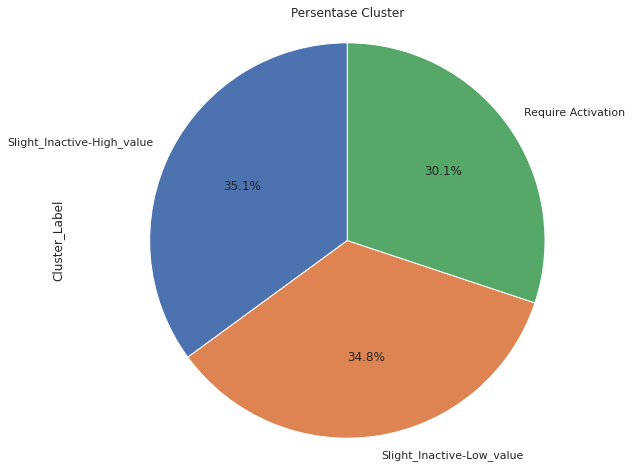

In [81]:
count_cluster = rm_table2['Cluster_Label'].value_counts()


count_cluster.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Persentase Cluster')
plt.show()

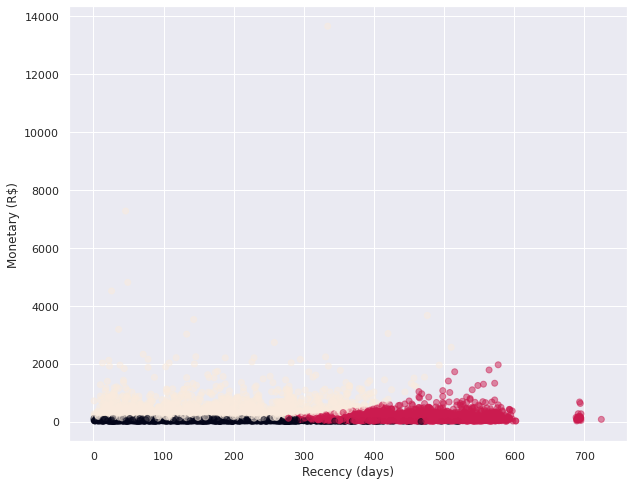

In [72]:
# Buat scatter plot dengan warna yang berbeda untuk masing-masing cluster
plt.scatter(rm_table2['Recency'], rm_table2['Monetary'], c=rm_table2['Cluster'], alpha=0.5)
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (R$)')
plt.show()

In [73]:
pip install squarify

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


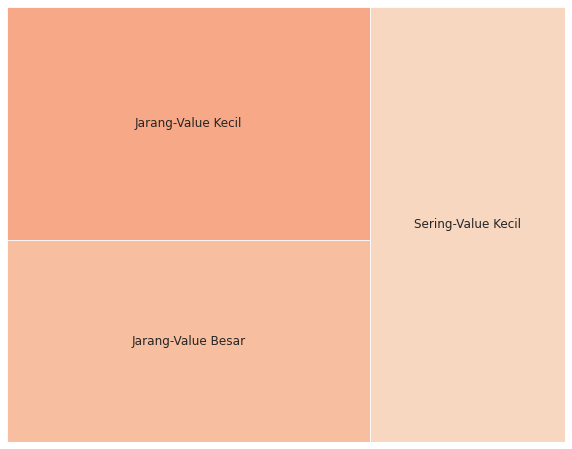

In [74]:
import squarify

# Hitung jumlah data point pada masing-masing cluster
cluster_count = rm_table2.groupby(['Cluster_Label']).size().reset_index(name='Count')

# Buat treemap dengan ukuran blok yang berbeda untuk masing-masing cluster
squarify.plot(sizes=cluster_count['Count'], label=cluster_count['Cluster_Label'], alpha=.8 )

plt.axis('off')
plt.show()

In [83]:
DF_final = pd.merge(df3, rm_table2, on='customer_unique_id')
DF_final

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,...,day_month,month_Year,Year_month,day_name,hour,review_category,Recency,Monetary,Cluster,Cluster_Label
0,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-12 23:36:26,2018-03-21 00:00:00,1.0,72d3bf1d3a790f8874096fcf860e3eff,0bae85eb84b9fb3bd773911e89288d54,...,01-03,03-2018,2018-03,Thursday,14,Positif,182,54.36,0,Slight_Inactive-Low_value
1,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,delivered,2017-12-15 00:06:10,2017-12-15 00:14:55,2018-01-03 15:09:32,2018-01-16 00:00:00,1.0,60184212dae4e6b0da32bf54271a8c4a,b33e7c55446eabf8fe1a42d037ac7d6d,...,15-12,12-2017,2017-12,Friday,0,Positif,258,386.33,2,Slight_Inactive-High_value
2,b52cc4919de82b4d696a4380d10804a3,be8c14c16a4d47194ccdfe10f1fc5b1a,delivered,2018-06-13 13:47:39,2018-06-15 02:37:29,2018-06-18 22:32:44,2018-06-26 00:00:00,1.0,7564c1759c04fc0a38f2aa84f7a370ee,6860153b69cc696d5dcfe1cdaaafcf62,...,13-06,06-2018,2018-06,Wednesday,13,Positif,78,55.02,0,Slight_Inactive-Low_value
3,82bce245b1c9148f8d19a55b9ff70644,388025bec8128ff20ec1a316ed4dcf02,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-05-10 09:17:55,2017-05-12 00:00:00,1.0,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,...,20-04,04-2017,2017-04,Thursday,17,Negatif,496,267.80,1,Require Activation
4,634e8f4c0f6744a626f77f39770ac6aa,05e996469a2bf9559c7122b87e156724,delivered,2017-08-09 18:32:47,2017-08-09 18:45:18,2017-08-16 18:17:54,2017-08-31 00:00:00,1.0,69d980b4120a76616d7b237d731d6156,744dac408745240a2c2528fb1b6028f3,...,09-08,08-2017,2017-08,Wednesday,18,Negatif,385,7.08,0,Slight_Inactive-Low_value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10469,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-06 16:58:25,2017-10-24 00:00:00,1.0,9e10ae46a3021a02f1692448ef9fa1db,8b28d096634035667e8263d57ba3368c,...,02-10,10-2017,2017-10,Monday,8,Positif,332,49.75,1,Require Activation
10470,dfc6eb45a2753ed9e6c6ef4987b44503,a046c690e0564ffde0ce611b5eee2c30,delivered,2018-05-25 17:05:17,2018-05-25 17:15:21,2018-06-04 23:54:32,2018-06-26 00:00:00,1.0,829002c1d5f40820ebbc6ecd4bcdf3ab,1025f0e2d44d7041d6cf58b6550e0bfa,...,25-05,05-2018,2018-05,Friday,17,Positif,96,173.63,2,Slight_Inactive-High_value
10471,6ec4642f9993cc34f826cfb9068e5a2f,f00bb12620b7b232233cace1b229db18,delivered,2017-11-21 20:18:03,2017-11-21 20:28:52,2017-12-02 16:48:46,2017-12-08 00:00:00,1.0,9503faef00966962beacdb4916272305,b2ba3715d723d245138f291a6fe42594,...,21-11,11-2017,2017-11,Tuesday,20,Positif,281,319.25,2,Slight_Inactive-High_value
10472,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-20 20:25:45,2017-11-07 00:00:00,2.0,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,...,04-10,10-2017,2017-10,Wednesday,19,Positif,329,42.42,1,Require Activation


In [84]:
DF_final.to_csv(path + "Olist_Data_Final_V1.csv")

## REKOMENDASI

1. Walau Value yang diterima perusahaan memiliki kecenderungan naik disetiap bulannya, namun jumlah transaksi mengalami penurunan drastis di akhir tahun. Perlu dilakukan pemeliharaan setiap akhir tahun, agar tidak terjadi penurunan yang signifikan pada banyaknya transaksi. Bisa dengan menambah promosi yang menarik diakhir tahun atau menambah ekspedisi pengiriman agar dipastikan tidak ada keterlambatan pengiriman disaat High-Season
2.  São Paulo (SP), Minas Gerais (MG), and Rio de Janeiro (RJ) merupakan top 3 Kota yang memiliki Total Value tertinggi dan Total transaks. Untuk Kota lain masih cenderung kecil, sehingga jika ingin menaikkan pesebaran penjualan bisa dilakukan promosi di kota yang memiliki nilai kecil.
3. Credit card merupakan tipe pembayaran yang paling banyak digunakan, dan yang kedua adalah Boleto. Dimana Boleto merupakan metode pembayaran yang hanya dilakukan di Brazil yang dibuat oleh pemerintah dan Bank negara Brazil. Kedua metode pembayaran tersebut memiliki persentase besar antara 90% - 95 % dari semua transaksi
4. Perbanyak info promosi di aplikasi pada jam sibuk setiap harinya, seperti pada hari senini bisa dilakukan pada jam 11.00 atau 15.00-16.00 karena di jam itu merupakan puncak tertinggi transaksi yang terjadi.
5. bed_bath_table, computers_accessories, furniture_decor adalah 3 produk dengan penjualan tertinggi.
6. Pola "New Customer" cenderung naik turun, namun perlu diperhatikan dan dianalisis lebih lanjut pada bulan November 2017 menuju Desember 2017, karena terdapat penurunan jumlah New Customer bahkan jumlah Customer secara total sehingga perusahaan tidak kembali mengalami penurunan yang drastis dari segi New Customer maupun penjualan. Seperti diadakan promosi besar untuk pelanggan baru di bulan tersebut.
7. Sebesar 76% review positif yang didapatkan perusahaan terkait transaksi yang terjadi. Dan sekitar 15% terdapat review negatif yang diberikan customer. Untuk selanjutnya bisa dilakukan analisis terkait review negatif yang didapat sehingga perusahaan dapat meminimalisir review negatif dari customer.
8. Perlu diperhatikan dalam pemberian promosi terhadap cluster customer yang terbentuk sehingga perusahaan tidak keluar biaya yang besar untuk promosi namun salah target customer

## KESIMPULAN

   E-commerce merupakan sektor bisnis yang sedang naik. Industri yang berkembang pesat ini juga telah mengadaptasi fitur-fitur seperti pembayaran online, pemasaran melalui internet, pengiriman yang bisa dilakukan dari rumah dan langsung sampai didepan rumah customer, pengembalian dan penukaran yang lebih mudah, dll. Karena ini adalah industri luas yang menambah kenyamanan dan kemewahan manusia, ada banyak ruang untuk peningkatan dan pertumbuhan bisnis , yang membawa keuntungan bagi konsumen dan perusahaan itu sendiri.

   Olist E-commerce berdasarkan visualisasi diatas dapat disimpulkan bagus dalam mendatangkan customer baru, karena hampir setiap bulan nya masih terdapat pelanggang baru yang melakukan transaksi, namun perlu diperhatikan bahwa hanya sedikit customer yang melakukan Repeat-Order dari Sptember 2016 hingga Agustus 2018. Sehingga dapat disarankan agar perusahaan mempertimbangkan untuk meningkatkan frekuensi dalam transaksi setiap customer. Untuk langkah yang bisa diambil yaitu memberikan promosi kepada customer dan merekomendasikan produk-produk yang terlaris dan tren atau produk yang sudah pernah dibeli atau produk pendukung terhadap produk yang sudah dibeli kepada customer yang berada di daerah yang memiliki tingkat tranksaksi dan value terbesar seperti Sao Paulo, Rio de Janeiro, Minas Gerais dengan memperhatikan segmentasi terhadap customer supaya target pasar bisa lebih tepat dan bisa menghemat waktu dan biaya pemasaran dan menghasilkan yang lebih baik.